# Measuring emission line fluxes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import corner
import lmfit
from lmfit import minimize, Parameters
from astropy.io import fits

import uncertainties.umath as uum
from uncertainties import ufloat
from uncertainties import unumpy as upy

import os
import sys
magePath = '/home/benjamin/Documents/analogs/'
os.sys.path.append(magePath)

from magE.directMethod import directT, run_all
from magE.functions import mergeSpec, gaussian, to_vel, FWHM, dV, save_catalog 
from magE.plotutils import * 
from magE.constutils import *

PATH = '/home/benjamin/Documents/analogs/specs/final_spec/'
os.chdir(PATH)
os.getcwd()

'/home/benjamin/Documents/analogs/specs/final_spec'

In [2]:
# read the data
import pandas as pd
galname = 'J1444'
j1444 = pd.read_csv(galname + '.csv')

wave = j1444['wave'].to_numpy()
flux = j1444['flux'].to_numpy() * 1e17
err = j1444['noise'].to_numpy() * 1e17
igal = np.argmax(np.array(galnames) == galname)

class SpecPiece(object):
    
    def __init__(self, name, wavelength, flux, noise):
        self.name = name
        self.wavelength = wavelength
        self.flux = flux
        self.noise = noise

# Main lines

# [NII]6548 + Ha + [NII]6584
select = (wave > 6790) * (wave < 6855)
ha_nii = SpecPiece('ha+nii', wave[select], flux[select], err[select])

# Hb + [OIII]4959 + [OIII]5007
select = (wave > 5190) * (wave < 5220)
oiii_hei = SpecPiece('oiii+hei', wave[select], flux[select], err[select])


# Low ionization lines

# [OII]7319 + [OII]7330
select = (wave > 7585) * (wave < 7654)
oii_7320 = SpecPiece('oii7330', wave[select], flux[select], err[select])

# HeI7065
select = (wave > 7300) * (wave < 7380)
hei_7065 = SpecPiece('hei7065', wave[select], flux[select], err[select])

# HeI6678
select = (wave > 6900) * (wave < 6970)
hei_6678 = SpecPiece('hei6678', wave[select], flux[select], err[select])

# [SII]6716 + [SII]6731
select = (wave > 6960) * (wave < 7015)
sii = SpecPiece('sii', wave[select], flux[select], err[select])

# HeI5875
select = (wave > 6060) * (wave < 6150)
hei_5875 = SpecPiece('hei5875', wave[select], flux[select], err[select])

# [NII]5755
select = (wave > 5930) * (wave < 6030)
nii_5755 = SpecPiece('nii5755', wave[select], flux[select], err[select])

# Hb
select = (wave > 5040) * (wave < 5063)
hbeta = SpecPiece('hb', wave[select], flux[select], err[select])

# HeI4471
select = (wave > 4620) * (wave < 4670)
hei_4471 = SpecPiece('hei4471', wave[select], flux[select], err[select])

# Hg
select = (wave > 4490) * (wave < 4530)
hgamma = SpecPiece('hg', wave[select], flux[select], err[select])

# Hd
select = (wave > 4245) * (wave < 4280)
hdelta = SpecPiece('hd', wave[select], flux[select], err[select])

# [SII]4068 + [SII]4076
select = (wave > 4210) * (wave < 4260)
sii2 = SpecPiece('sii2', wave[select], flux[select], err[select])

# [OII]3726 + [OII]3729
select = (wave > 3860) * (wave < 3890)
oii_3727 = SpecPiece('oii3727', wave[select], flux[select], err[select])


# High ionization lines

# [SIII]9532
select = (wave > 9850) * (wave < 9950)
siii_9532 = SpecPiece('siiia', wave[select], flux[select], err[select])

# [SIII]9069
select = (wave > 9400) * (wave < 9450)
siii_9069 = SpecPiece('siiib', wave[select], flux[select], err[select])

# [Ar III]7135
select = (wave > 7370) * (wave < 7450)
ariii_7135 = SpecPiece('ariii_7135', wave[select], flux[select], err[select])

# [OI]6300 + [SIII]6312
select = (wave > 6520) * (wave < 6585)
oi_siii = SpecPiece('oi+siiic', wave[select], flux[select], err[select])

# [OIII]4959
select = (wave > 5135) * (wave < 5170)
oiii_4959 = SpecPiece('oiiib', wave[select], flux[select], err[select])

# [Ar IV]4740
select = (wave > 4900) * (wave < 4950)
ariv_4740 = SpecPiece('ariv_4740', wave[select], flux[select], err[select])

# HeII4686
select = (wave > 4850) * (wave < 4890)
heii_4686 = SpecPiece('heii4686', wave[select], flux[select], err[select])

# [OIII]4363
select = (wave > 4520) * (wave < 4546)
oiii_4363 = SpecPiece('oiiic', wave[select], flux[select], err[select])

# [NeIII]3868
select = (wave > 4000) * (wave < 4035)
neiii_3868 = SpecPiece('neiiia', wave[select], flux[select], err[select])

Text(0.5, 0, 'Obs wavelength ($\\AA$)')

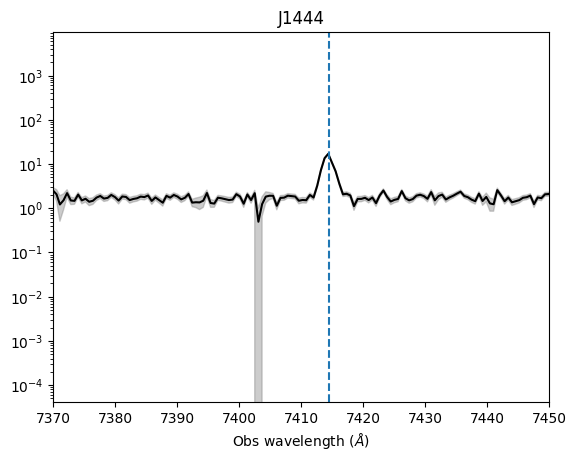

In [3]:
plt.plot(wave, flux, color='black')
plt.fill_between(wave, flux-err, flux+err, color='gray', alpha=0.4)
plt.xlim(7370, 7450)
#plt.ylim(1e-17, 1e-16)
plt.axvline((1 + z_BN[igal])*wave_cat['[ArIII]7135'], ls='--')
plt.yscale('log')
plt.title('J1444')
plt.xlabel('Obs wavelength ($\AA$)')
#plt.savefig('/home/benjamin/Documents/analogs/HeIIJ1444.pdf', bbox_inches='tight')

---

# Two component model fit for [OIII] 4959

In [4]:
m = arc_slope19a
n = arc_intercept19a

sigma_arc_4959 = (m * wave_cat['[OIII]4959']*(1 + z_BN[igal])) + n

# [OIII]4959

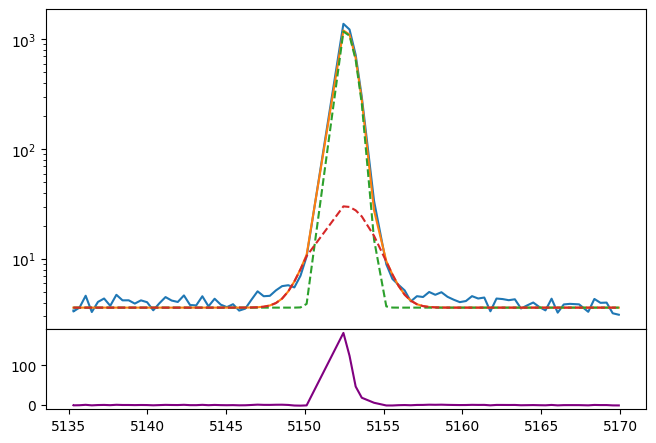

In [5]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oiii_4959.wavelength, oiii_4959.flux)
bkg = 3.6

oiiib_nar = gaussian(oiii_4959.wavelength, 1800, wave_cat['[OIII]4959'], z=z_BN[igal], sigma=0.6)
oiiib_brd = gaussian(oiii_4959.wavelength, 100, wave_cat['[OIII]4959'], z=z_BN[igal], sigma=1.5)

ax.plot(oiii_4959.wavelength, bkg + oiiib_nar + oiiib_brd)
ax.plot(oiii_4959.wavelength, bkg + oiiib_nar, ls='--')
ax.plot(oiii_4959.wavelength, bkg + oiiib_brd, ls='--')
ax1.plot(oiii_4959.wavelength, oiii_4959.flux - bkg - oiiib_nar - oiiib_brd, color='purple')
ax.set_yscale('log')

In [6]:
params_oiii_4959 = Parameters()
params_oiii_4959.add('z_nar', value=z_BN[igal])
params_oiii_4959.add('z_brd', value=z_BN[igal])
params_oiii_4959.add('sigma_nar', value=0.6, min=0.)
params_oiii_4959.add('sigma_brd', value=1.5, min=0.)
params_oiii_4959.add('Oiiib_nar', value=1800, min=0.)
params_oiii_4959.add('Oiiib_brd', value=100, min=0.)
params_oiii_4959.add('bkg', value=3.6, min=0.)


def residual_oiii_4959(params_oiii_4959, x, data, uncertainty):
    
    z_nar = params_oiii_4959['z_nar']
    z_brd = params_oiii_4959['z_brd']
    sigma_nar = params_oiii_4959['sigma_nar']
    sigma_brd = params_oiii_4959['sigma_brd']
    oiiib_nar = params_oiii_4959['Oiiib_nar']
    oiiib_brd = params_oiii_4959['Oiiib_brd']
    bkg = params_oiii_4959['bkg']
    
    x = oiii_4959.wavelength
    model = gaussian(x, oiiib_nar, wave_cat['[OIII]4959'], z_nar, sigma_nar) \
          + gaussian(x, oiiib_brd, wave_cat['[OIII]4959'], z_brd, sigma_brd)
    
    return (model + bkg - oiii_4959.flux) / oiii_4959.noise

In [7]:
np.random.seed(1444)
out_oiii_4959 = minimize(residual_oiii_4959, params_oiii_4959, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:17<00:00, 145.45it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 7 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 68.22659216  52.97010128  58.38379319 156.98494854  52.72482407
 126.33003411 121.7893395 ]


In [8]:
out_oiii_4959.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03904139,1.4825e-06,(0.00%),0.03905,-inf,inf,True
z_brd,0.03905957,5.8284e-06,(0.01%),0.03905,-inf,inf,True
sigma_nar,0.60463304,0.00668829,(1.11%),0.6,0.00000000,inf,True
sigma_brd,1.23105084,0.06101444,(4.96%),1.5,0.00000000,inf,True
Oiiib_nar,2041.27431,37.7350566,(1.85%),1800,0.00000000,inf,True
Oiiib_brd,148.685771,24.8244732,(16.70%),100,0.00000000,inf,True
bkg,4.07685241,0.05114876,(1.25%),3.6,0.00000000,inf,True


In [9]:
np.random.seed(1444)
out2_oiii_4959 = minimize(residual_oiii_4959, out_oiii_4959.params, args=(1, 1, 1),
                      method='leastsq')

In [10]:
out2_oiii_4959.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03904157,1.7428e-06,(0.00%),0.03904138576335933,-inf,inf,True
z_brd,0.03905971,7.1916e-06,(0.02%),0.03905956642267363,-inf,inf,True
sigma_nar,0.60377699,0.00717239,(1.19%),0.6046330449971782,0.00000000,inf,True
sigma_brd,1.22575457,0.05727633,(4.67%),1.2310508383507883,0.00000000,inf,True
Oiiib_nar,2036.45104,38.3388970,(1.88%),2041.274314820313,0.00000000,inf,True
Oiiib_brd,151.941217,24.6624807,(16.23%),148.68577144153286,0.00000000,inf,True
bkg,4.07838247,0.06201007,(1.52%),4.076852406285079,0.00000000,inf,True


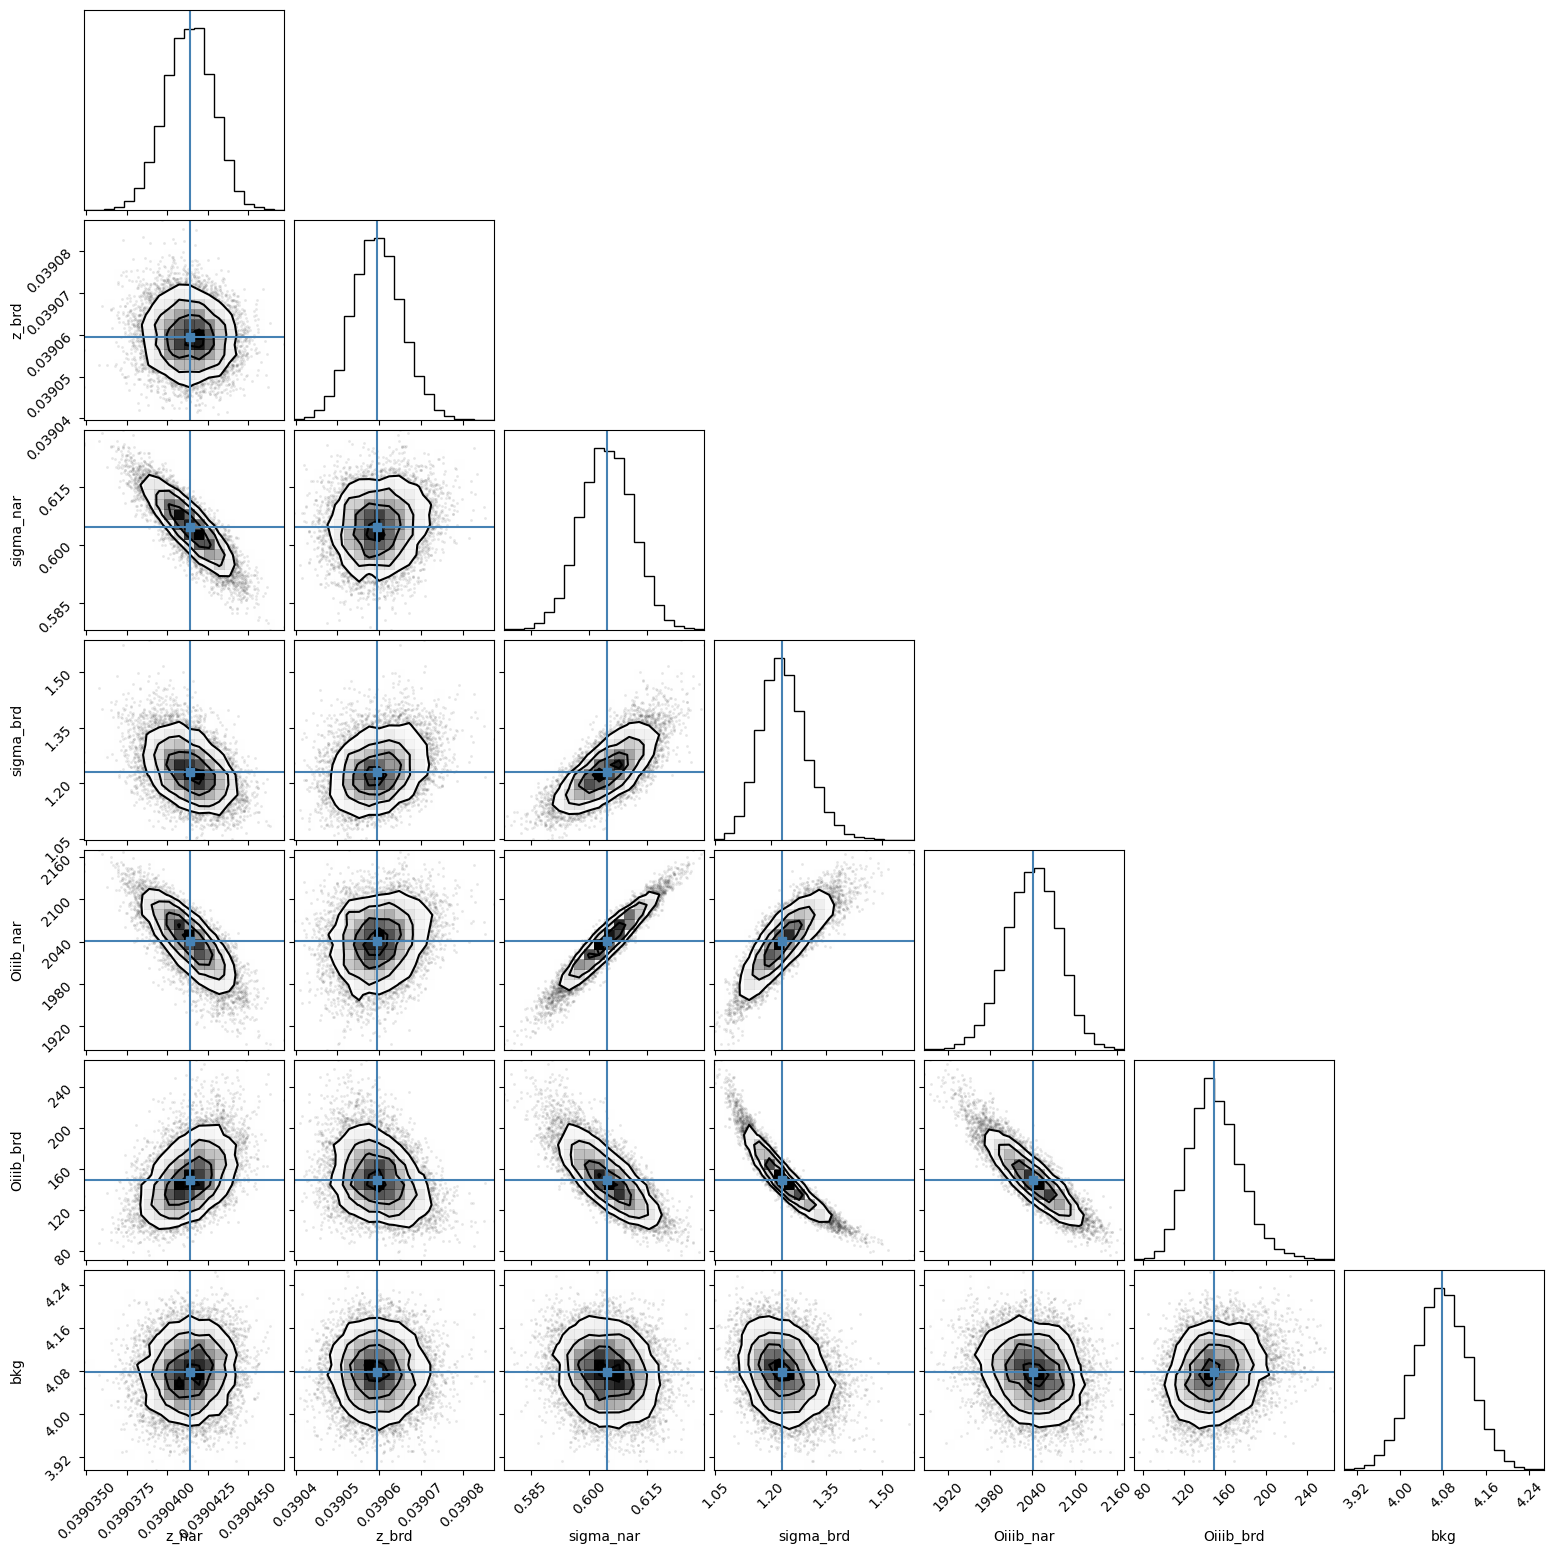

In [11]:
corner.corner(out_oiii_4959.flatchain, labels=out_oiii_4959.var_names,
             truths=list(out_oiii_4959.params.valuesdict().values()));
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

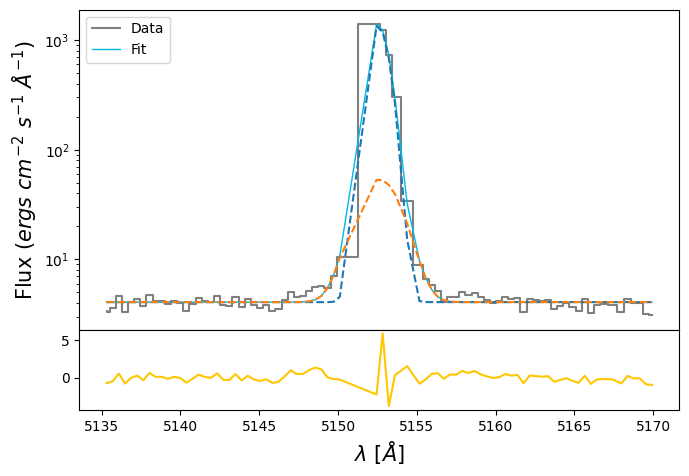

In [12]:
oiiib_nar_flux = out2_oiii_4959.params['Oiiib_nar'].value
oiiib_nar_std = out2_oiii_4959.params['Oiiib_nar'].stderr

oiiib_brd_flux = out2_oiii_4959.params['Oiiib_brd'].value
oiiib_brd_std = out2_oiii_4959.params['Oiiib_brd'].stderr

bkg_oiii_4959 = out2_oiii_4959.params['bkg'].value
bkg_oiii_4959_std = out2_oiii_4959.params['bkg'].stderr

z_nar_oiii_4959 = out2_oiii_4959.params['z_nar'].value
z_nar_oiii_4959_std = out2_oiii_4959.params['z_nar'].stderr

z_brd_oiii_4959 = out2_oiii_4959.params['z_brd'].value
z_brd_oiii_4959_std = out2_oiii_4959.params['z_brd'].stderr

sigma_nar_oiii_4959 = out2_oiii_4959.params['sigma_nar'].value
sigma_nar_oiii_4959_std = out2_oiii_4959.params['sigma_nar'].stderr

sigma_brd_oiii_4959 = out2_oiii_4959.params['sigma_brd'].value
sigma_brd_oiii_4959_std = out2_oiii_4959.params['sigma_brd'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oiii_4959.wavelength, oiii_4959.flux,
            color='gray', label='Data', where='mid')

oiiib_nar = gaussian(oiii_4959.wavelength, oiiib_nar_flux, wave_cat['[OIII]4959'], z_nar_oiii_4959, sigma_nar_oiii_4959)
oiiib_brd = gaussian(oiii_4959.wavelength, oiiib_brd_flux, wave_cat['[OIII]4959'], z_brd_oiii_4959, sigma_brd_oiii_4959)
oiiib = oiiib_nar + oiiib_brd

ax.plot(oiii_4959.wavelength, bkg_oiii_4959 + oiiib,
        lw=1, color=c[0], label='Fit')
ax.plot(oiii_4959.wavelength, bkg_oiii_4959 + oiiib_nar, ls='--')
ax.plot(oiii_4959.wavelength, bkg_oiii_4959 + oiiib_brd, ls='--')
ax1.plot(oiii_4959.wavelength, oiii_4959.flux - bkg_oiii_4959 - oiiib,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.legend(loc='upper left')
ax.set_yscale('log')

In [13]:
# Correcting sigma by instrumental broadening

# Intrinsic from the galaxy
sigma_nar_intrinsic = upy.sqrt((ufloat(sigma_nar_oiii_4959, sigma_nar_oiii_4959_std)**2) - (sigma_arc_4959**2))
sigma_brd_intrinsic = upy.sqrt((ufloat(sigma_brd_oiii_4959, sigma_brd_oiii_4959_std)**2) - (sigma_arc_4959**2)) 

In [14]:
# EW
EW_OIII_4959_nar = ufloat(oiiib_nar_flux, oiiib_nar_std) / ufloat(bkg_oiii_4959, bkg_oiii_4959_std)
EW_OIII_4959_brd = ufloat(oiiib_brd_flux, oiiib_brd_std) / ufloat(bkg_oiii_4959, bkg_oiii_4959_std)
EW_OIII_4959 = (ufloat(oiiib_nar_flux, oiiib_nar_std) + ufloat(oiiib_brd_flux, oiiib_brd_std)) / ufloat(bkg_oiii_4959, bkg_oiii_4959_std)

# FWHM
FWHM_4959_nar = FWHM(sigma_nar_intrinsic, wave_cat['[OIII]4959']*(1 + ufloat(z_nar_oiii_4959, z_nar_oiii_4959_std)))
FWHM_4959_brd = FWHM(sigma_brd_intrinsic, wave_cat['[OIII]4959']*(1 + ufloat(z_brd_oiii_4959, z_brd_oiii_4959_std)))

# velocity shift
dV_4959 = dV(ufloat(z_brd_oiii_4959, z_brd_oiii_4959_std),
             ufloat(z_nar_oiii_4959, z_nar_oiii_4959_std))

# Ratio to fix velocity shifts between components
z_ratio = z_brd_oiii_4959 / z_nar_oiii_4959

# Ratio to distribute the flux between components in no detection
brd_to_nar = oiiib_brd_flux / oiiib_nar_flux

# Dispersion for the whole spectra
dLam = (np.max(wave) - np.min(wave)) / len(wave)

In [15]:
print('Redshift of the narrow component: {:.4f}'.format(ufloat(z_nar_oiii_4959, z_nar_oiii_4959_std)))

Redshift of the narrow component: 0.0390+/-0.0000


In [16]:
# Velocities
vel = {'galname': galname,
       'z_nar': z_nar_oiii_4959,
       'dV': dV_4959.nominal_value,
       'dV_err': dV_4959.std_dev,
       'FWHM_nar': FWHM_4959_nar.nominal_value,
       'FWHM_nar_err': FWHM_4959_nar.std_dev,
       'FWHM_brd': FWHM_4959_brd.nominal_value,
       'FWHM_brd_err': FWHM_4959_brd.std_dev
}
vel_catalog_pd = pd.DataFrame(data=vel, index=[0])
vel_catalog_pd

,galname,z_nar,dV,dV_err,FWHM_nar,FWHM_nar_err,FWHM_brd,FWHM_brd_err
0,J1444,0.039042,5.232863,2.135036,43.97156,1.847501,152.575792,8.631649


In [17]:
save_catalog(galname, vel_catalog_pd, magePath + '/results/vel_catalog_lstsq.csv')

Existent catalog (.csv) file.
Existent data for J1444, overwriting...
Done.


----

# HeII 4686

In [18]:
sigma_arc_4685 = (m * wave_cat['HeII4685']*(1 + z_BN[igal])) + n

sigma_nar_4685 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_4685**2))
sigma_brd_4685 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_4685**2))

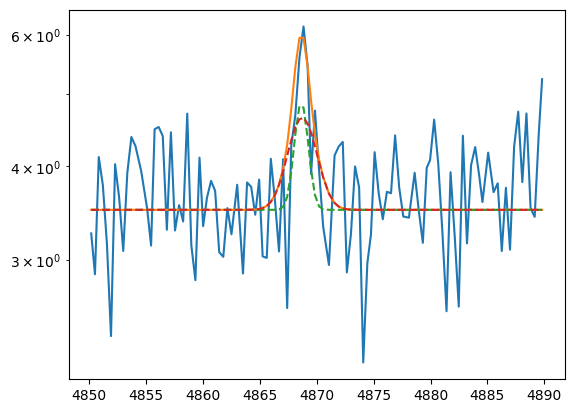

In [19]:
plt.plot(heii_4686.wavelength, heii_4686.flux)
bkg = 3.5

heii4685_nar = gaussian(heii_4686.wavelength, 2.0, wave_cat['HeII4685'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_4685))
heii4685_brd = gaussian(heii_4686.wavelength, 3.5, wave_cat['HeII4685'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_4685))

heii4685 = heii4685_nar + heii4685_brd

plt.plot(heii_4686.wavelength, heii4685 + bkg)
plt.plot(heii_4686.wavelength, heii4685_nar + bkg, ls='--')
plt.plot(heii_4686.wavelength, heii4685_brd + bkg, ls='--')
plt.yscale('log')

In [20]:
params_4685 = Parameters()
params_4685.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_4685.add('z_ratio', value=z_ratio, vary=False)
params_4685.add('sigma_heii4685_nar', value=upy.nominal_values(sigma_nar_4685), vary=False)
params_4685.add('sigma_heii4685_brd', value=upy.nominal_values(sigma_brd_4685), vary=False)
params_4685.add('Heii4685_nar', value=2.0, min=0.)
params_4685.add('Heii4685_brd', value=0., vary=False)
params_4685.add('bkg', value=3.5, min=0.)

def residual_heii4685(params_4685, x, data, uncertainty):
    
    z_nar = params_4685['z_nar']
    z_brd = params_4685['z_nar'] * params_4685['z_ratio']
    sigma_heii4685_nar = params_4685['sigma_heii4685_nar']
    sigma_heii4685_brd = params_4685['sigma_heii4685_brd']
    heii4685_nar_flux = params_4685['Heii4685_nar']
    heii4685_brd_flux = params_4685['Heii4685_brd']
    bkg = params_4685['bkg']
    
    x = heii_4686.wavelength
    model = gaussian(x, heii4685_nar_flux, wave_cat['HeII4685'], z_nar, sigma_heii4685_nar) + \
            gaussian(x, heii4685_brd_flux, wave_cat['HeII4685'], z_brd, sigma_heii4685_brd)
    return (model + bkg - heii_4686.flux) / heii_4686.noise

In [21]:
np.random.seed(1444)
out_heii4685 = minimize(residual_heii4685, params_4685, args=(1, 1, 1),
                   method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:18<00:00, 138.88it/s]


In [22]:
out_heii4685.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03907423,2.1473e-05,(0.05%),0.039041570755652975,-inf,inf,True
z_ratio,1.00046454,,,1.0004645413076385,-inf,inf,False
sigma_heii4685_nar,0.58197263,,,0.5819726315201612,-inf,inf,False
sigma_heii4685_brd,1.21516244,,,1.2151624356399224,-inf,inf,False
Heii4685_nar,3.23785567,0.43941028,(13.57%),2.0,0.00000000,inf,True
Heii4685_brd,0.00000000,,,0.0,-inf,inf,False
bkg,3.63119832,0.04712315,(1.30%),3.5,0.00000000,inf,True


In [23]:
np.random.seed(1444)
out2_heii4685 = minimize(residual_heii4685, out_heii4685.params, args=(1, 1, 1),
                   method='leastsq')

In [24]:
out2_heii4685.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03907370,2.6884e-05,(0.07%),0.039074233732534526,-inf,inf,True
z_ratio,1.00046454,0.00000000,(0.00%),1.0004645413076385,-inf,inf,False
sigma_heii4685_nar,0.58197263,0.00000000,(0.00%),0.5819726315201612,-inf,inf,False
sigma_heii4685_brd,1.21516244,0.00000000,(0.00%),1.2151624356399224,-inf,inf,False
Heii4685_nar,3.27357496,0.52942954,(16.17%),3.23785566990093,0.00000000,inf,True
Heii4685_brd,0.00000000,0.00000000,,0.0,-inf,inf,False
bkg,3.63015654,0.05545718,(1.53%),3.6311983210834358,0.00000000,inf,True


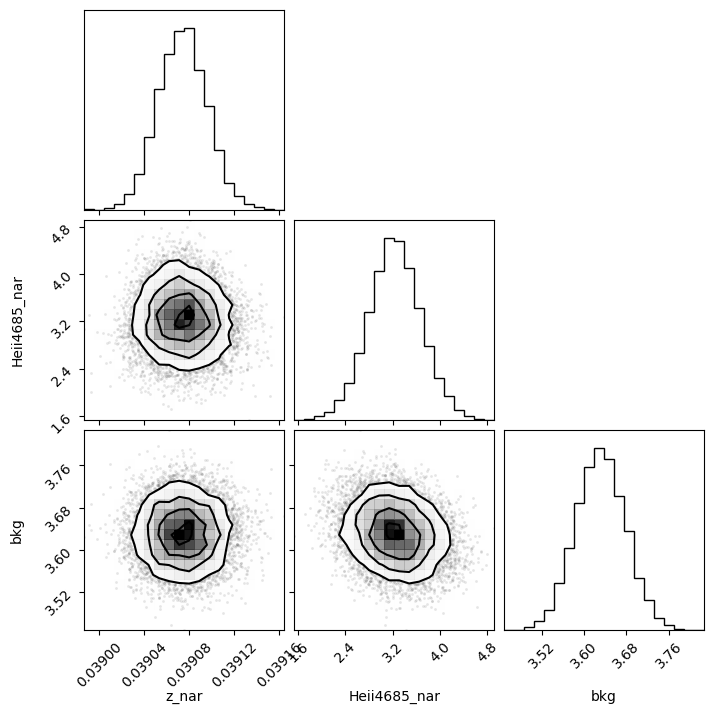

In [25]:
corner.corner(out_heii4685.flatchain, labels=out_heii4685.var_names);

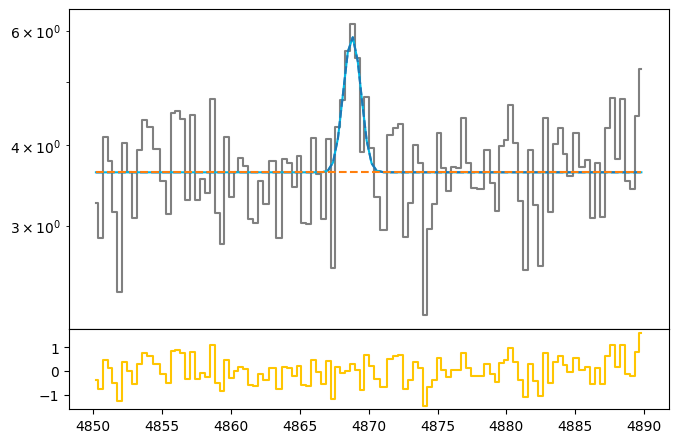

In [26]:
heiia_nar_flux = out2_heii4685.params['Heii4685_nar'].value
heiia_nar_std = out2_heii4685.params['Heii4685_nar'].stderr

heiia_brd_flux = out2_heii4685.params['Heii4685_brd'].value
heiia_brd_std = out2_heii4685.params['Heii4685_brd'].stderr

z_heiia = out2_heii4685.params['z_nar'].value
z_heiia_std = out2_heii4685.params['z_nar'].stderr

bkg_heiia = out2_heii4685.params['bkg'].value
bkg_heiia_std = out2_heii4685.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(heii_4686.wavelength, heii_4686.flux, color='gray', label='Data', where='mid')

heiia_nar = gaussian(heii_4686.wavelength, heiia_nar_flux, wave_cat['HeII4685'], z_heiia, upy.nominal_values(sigma_nar_4685))
heiia_brd = gaussian(heii_4686.wavelength, heiia_brd_flux, wave_cat['HeII4685'], z_heiia * z_ratio, upy.nominal_values(sigma_brd_4685))

heiia = heiia_nar + heiia_brd

ax.plot(heii_4686.wavelength, bkg_heiia + heiia, color=c[0])
ax.plot(heii_4686.wavelength, bkg_heiia + heiia_nar, ls='--')
ax.plot(heii_4686.wavelength, bkg_heiia + heiia_brd, ls='--')
ax.set_yscale('log')
ax1.step(heii_4686.wavelength, heii_4686.flux - bkg_heiia - heiia, color=c[3], where='mid')

In [27]:
# EW
EW_HeII_4686_nar = ufloat(heiia_nar_flux, heiia_nar_std) / ufloat(bkg_heiia, bkg_heiia_std)
EW_HeII_4686_brd = ufloat(heiia_brd_flux, heiia_brd_std) / ufloat(bkg_heiia, bkg_heiia_std)
EW_HeII_4686 = (ufloat(heiia_nar_flux, heiia_nar_std) + ufloat(heiia_brd_flux, heiia_brd_std)) / ufloat(bkg_heiia, bkg_heiia_std)

# HeI 7065

In [28]:
sigma_arc_7065 = (m * wave_cat['HeI7065']*(1 + z_BN[igal])) + n

sigma_nar_7065 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_7065**2))
sigma_brd_7065 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_7065**2))

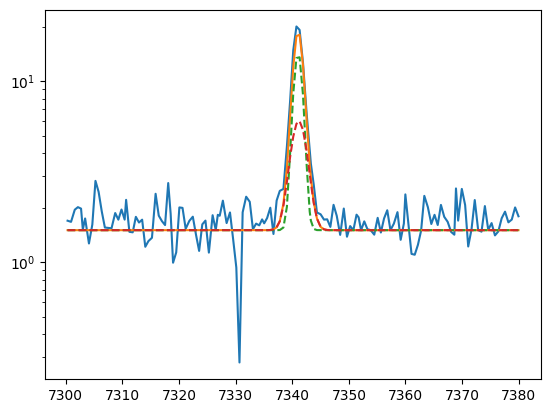

In [29]:
plt.plot(hei_7065.wavelength, hei_7065.flux)
bkg = 1.5

hei7065_nar = gaussian(hei_7065.wavelength, 2.5e1, wave_cat['HeI7065'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_7065))
hei7065_brd = gaussian(hei_7065.wavelength, 1.5e1, wave_cat['HeI7065'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_7065))

hei7065 = hei7065_nar + hei7065_brd

plt.plot(hei_7065.wavelength, hei7065 + bkg)
plt.plot(hei_7065.wavelength, hei7065_nar + bkg, ls='--')
plt.plot(hei_7065.wavelength, hei7065_brd + bkg, ls='--')
plt.yscale('log')

In [30]:
params_7065 = Parameters()
params_7065.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_7065.add('z_ratio', value=z_ratio, vary=False)
params_7065.add('sigma_hei7065_nar', value=upy.nominal_values(sigma_nar_7065), vary=False)
params_7065.add('sigma_hei7065_brd', value=upy.nominal_values(sigma_brd_7065), vary=False)
params_7065.add('Hei7065_nar', value=2.5e1, min=0.)
params_7065.add('Hei7065_brd', value=1.5e1, min=0.)
params_7065.add('bkg', value=1.5, min=0.)

def residual_hei7065(params_7065, x, data, uncertainty):
    
    z_nar = params_7065['z_nar']
    z_brd = params_7065['z_nar'] * params_7065['z_ratio']
    sigma_hei7065_nar = params_7065['sigma_hei7065_nar']
    sigma_hei7065_brd = params_7065['sigma_hei7065_brd']
    hei7065_nar_flux = params_7065['Hei7065_nar']
    hei7065_brd_flux = params_7065['Hei7065_brd']
    bkg = params_7065['bkg']
    
    x = hei_7065.wavelength
    model = gaussian(x, hei7065_nar_flux, wave_cat['HeI7065'], z_nar, sigma_hei7065_nar) + \
            gaussian(x, hei7065_brd_flux, wave_cat['HeI7065'], z_brd, sigma_hei7065_brd)
    return (model + bkg - hei_7065.flux) / hei_7065.noise

In [31]:
np.random.seed(1444)
out_hei7065 = minimize(residual_hei7065, params_7065, args=(1, 1, 1),
                   method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:18<00:00, 131.82it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 1 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [40.09283213 39.19615379 45.86089336 54.14763347]


In [32]:
out_hei7065.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03902901,2.7894e-06,(0.01%),0.039041570755652975,-inf,inf,True
z_ratio,1.00046454,,,1.0004645413076385,-inf,inf,False
sigma_hei7065_nar,0.78041866,,,0.7804186630983828,-inf,inf,False
sigma_hei7065_brd,1.32173405,,,1.321734046948975,-inf,inf,False
Hei7065_nar,25.1782615,1.54877509,(6.15%),25.0,0.00000000,inf,True
Hei7065_brd,20.1977122,2.10118744,(10.40%),15.0,0.00000000,inf,True
bkg,1.67985704,0.02307811,(1.37%),1.5,0.00000000,inf,True


In [33]:
np.random.seed(1444)
out2_hei7065 = minimize(residual_hei7065, out_hei7065.params, args=(1, 1, 1),
                   method='leastsq')

In [34]:
out2_hei7065.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03902894,3.0308e-06,(0.01%),0.039029012298988565,-inf,inf,True
z_ratio,1.00046454,0.00000000,(0.00%),1.0004645413076385,-inf,inf,False
sigma_hei7065_nar,0.78041866,0.00000000,(0.00%),0.7804186630983828,-inf,inf,False
sigma_hei7065_brd,1.32173405,0.00000000,(0.00%),1.321734046948975,-inf,inf,False
Hei7065_nar,25.1632709,1.65227208,(6.57%),25.178261539087465,0.00000000,inf,True
Hei7065_brd,20.2048364,2.22486289,(11.01%),20.19771216024555,0.00000000,inf,True
bkg,1.67909447,0.02461368,(1.47%),1.6798570370725665,0.00000000,inf,True


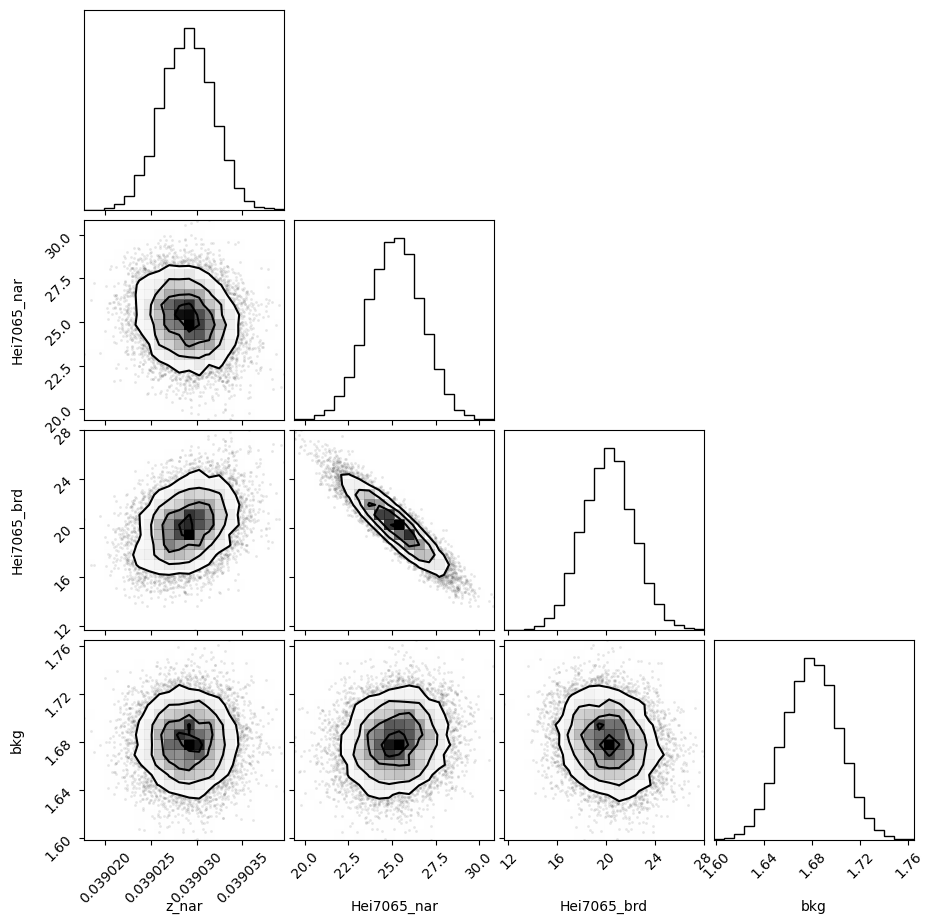

In [35]:
corner.corner(out_hei7065.flatchain, labels=out_hei7065.var_names);

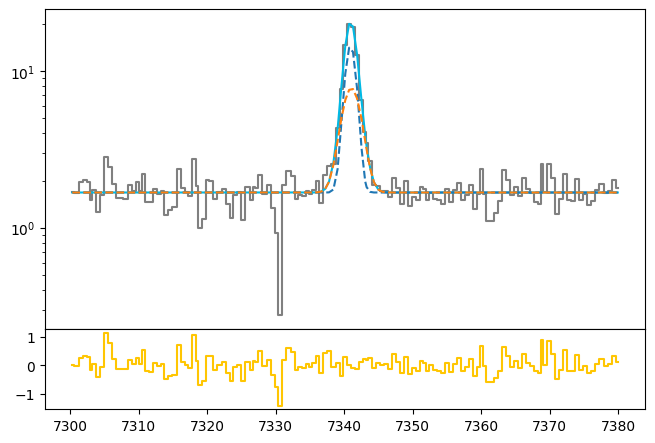

In [36]:
heia_nar_flux = out2_hei7065.params['Hei7065_nar'].value
heia_nar_std = out2_hei7065.params['Hei7065_nar'].stderr

heia_brd_flux = out2_hei7065.params['Hei7065_brd'].value
heia_brd_std = out2_hei7065.params['Hei7065_brd'].stderr

z_heia = out2_hei7065.params['z_nar'].value
z_heia_std = out2_hei7065.params['z_nar'].stderr

bkg_heia = out2_hei7065.params['bkg'].value
bkg_heia_std = out2_hei7065.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(hei_7065.wavelength, hei_7065.flux, color='gray', label='Data', where='mid')

heia_nar = gaussian(hei_7065.wavelength, heia_nar_flux, wave_cat['HeI7065'], z_heia, upy.nominal_values(sigma_nar_7065))
heia_brd = gaussian(hei_7065.wavelength, heia_brd_flux, wave_cat['HeI7065'], z_heia * z_ratio, upy.nominal_values(sigma_brd_7065))

heia = heia_nar + heia_brd

ax.plot(hei_7065.wavelength, bkg_heia + heia, color=c[0])
ax.plot(hei_7065.wavelength, bkg_heia + heia_nar, ls='--')
ax.plot(hei_7065.wavelength, bkg_heia + heia_brd, ls='--')
ax.set_yscale('log')
ax1.step(hei_7065.wavelength, hei_7065.flux - bkg_heia - heia, color=c[3], where='mid')

In [37]:
# EW
EW_HeI_7065_nar = ufloat(heia_nar_flux, heia_nar_std) / ufloat(bkg_heia, bkg_heia_std)
EW_HeI_7065_brd = ufloat(heia_brd_flux, heia_brd_std) / ufloat(bkg_heia, bkg_heia_std)
EW_HeI_7065 = (ufloat(heia_nar_flux, heia_nar_std) + ufloat(heia_brd_flux, heia_brd_std)) / ufloat(bkg_heia, bkg_heia_std)

# HeI 6678

In [38]:
sigma_arc_6678 = (m * wave_cat['HeI6678']*(1 + z_BN[igal])) + n

sigma_nar_6678 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_6678**2))
sigma_brd_6678 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_6678**2))

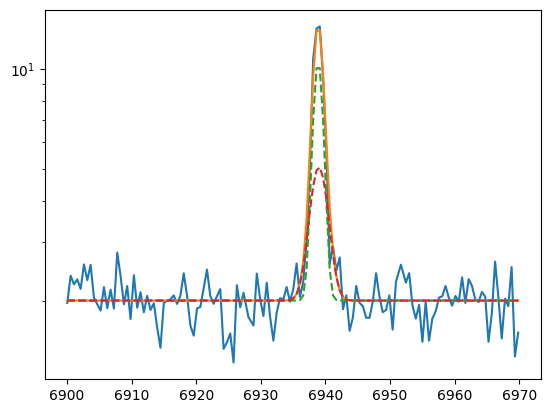

In [39]:
plt.plot(hei_6678.wavelength, hei_6678.flux)
bkg = 2

hei6678_nar = gaussian(hei_6678.wavelength, 1.6e1, wave_cat['HeI6678'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_6678))
hei6678_brd = gaussian(hei_6678.wavelength, 1e1, wave_cat['HeI6678'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_6678))

hei6678 = hei6678_nar + hei6678_brd

plt.plot(hei_6678.wavelength, hei6678 + bkg)
plt.plot(hei_6678.wavelength, hei6678_nar + bkg, ls='--')
plt.plot(hei_6678.wavelength, hei6678_brd + bkg, ls='--')
plt.yscale('log')

In [40]:
params_6678 = Parameters()
params_6678.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_6678.add('z_ratio', value=z_ratio, vary=False)
params_6678.add('sigma_hei6678_nar', value=upy.nominal_values(sigma_nar_6678), vary=False)
params_6678.add('sigma_hei6678_brd', value=upy.nominal_values(sigma_brd_6678), vary=False)
params_6678.add('Hei6678_nar', value=1.6e1, min=0.)
params_6678.add('Hei6678_brd', value=1.0e1, min=0.)
params_6678.add('bkg', value=2.0, min=0.)

def residual_hei6678(params_6678, x, data, uncertainty):
    
    z_nar = params_6678['z_nar']
    z_brd = params_6678['z_nar'] * params_6678['z_ratio']
    sigma_hei6678_nar = params_6678['sigma_hei6678_nar']
    sigma_hei6678_brd = params_6678['sigma_hei6678_brd']
    hei6678_nar_flux = params_6678['Hei6678_nar']
    hei6678_brd_flux = params_6678['Hei6678_brd']
    bkg = params_6678['bkg']
    
    x = hei_6678.wavelength
    model = gaussian(x, hei6678_nar_flux, wave_cat['HeI6678'], z_nar, sigma_hei6678_nar) + \
            gaussian(x, hei6678_brd_flux, wave_cat['HeI6678'], z_brd, sigma_hei6678_brd)
    return (model + bkg - hei_6678.flux) / hei_6678.noise

In [41]:
np.random.seed(1444)
out_hei6678 = minimize(residual_hei6678, params_6678, args=(1, 1, 1),
                   method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:19<00:00, 129.26it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [38.11540077 55.74893287 57.02070174 40.85739826]


In [42]:
out_hei6678.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03903700,2.6743e-06,(0.01%),0.039041570755652975,-inf,inf,True
z_ratio,1.00046454,,,1.0004645413076385,-inf,inf,False
sigma_hei6678_nar,0.74707820,,,0.747078199558702,-inf,inf,False
sigma_hei6678_brd,1.30232616,,,1.3023261639880077,-inf,inf,False
Hei6678_nar,20.3031770,0.98926086,(4.87%),16.0,0.00000000,inf,True
Hei6678_brd,4.62156302,1.22845638,(26.58%),10.0,0.00000000,inf,True
bkg,2.00571265,0.02089926,(1.04%),2.0,0.00000000,inf,True


In [43]:
np.random.seed(1444)
out2_hei6678 = minimize(residual_hei6678, out_hei6678.params, args=(1, 1, 1),
                   method='leastsq')

In [44]:
out2_hei6678.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03903703,3.1972e-06,(0.01%),0.03903700470250209,-inf,inf,True
z_ratio,1.00046454,0.00000000,(0.00%),1.0004645413076385,-inf,inf,False
sigma_hei6678_nar,0.74707820,0.00000000,(0.00%),0.747078199558702,-inf,inf,False
sigma_hei6678_brd,1.30232616,0.00000000,(0.00%),1.3023261639880077,-inf,inf,False
Hei6678_nar,20.3170805,1.18864010,(5.85%),20.303176980174584,0.00000000,inf,True
Hei6678_brd,4.60216836,1.49500678,(32.48%),4.621563022225797,0.00000000,inf,True
bkg,2.00558927,0.02519053,(1.26%),2.005712648433888,0.00000000,inf,True


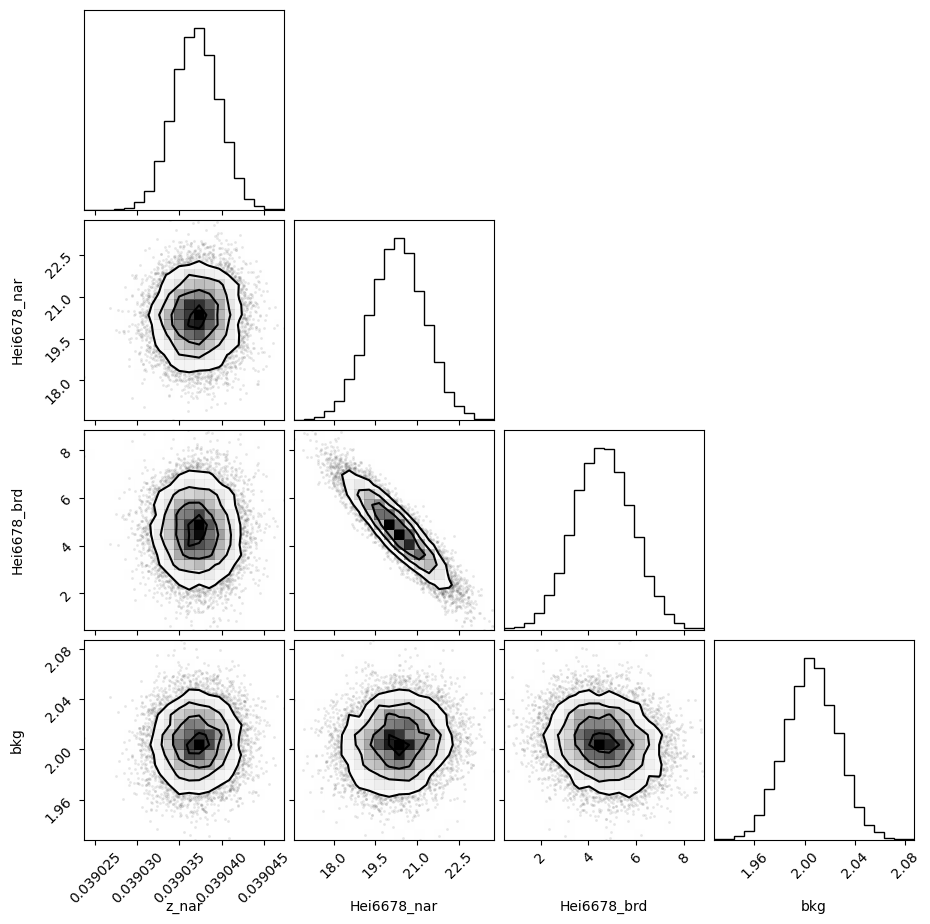

In [45]:
corner.corner(out_hei6678.flatchain, labels=out_hei6678.var_names);

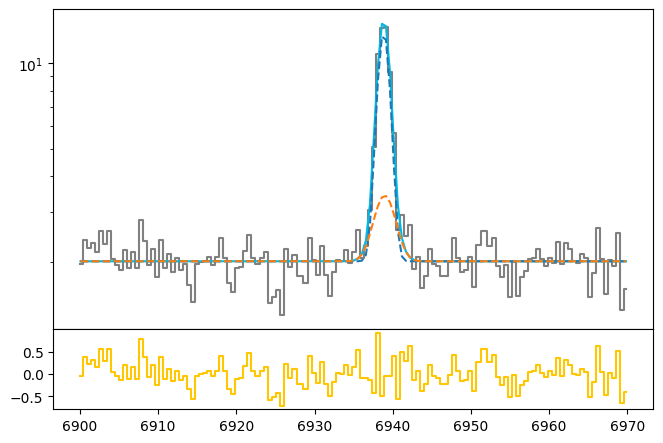

In [46]:
heib_nar_flux = out2_hei6678.params['Hei6678_nar'].value
heib_nar_std = out2_hei6678.params['Hei6678_nar'].stderr

heib_brd_flux = out2_hei6678.params['Hei6678_brd'].value
heib_brd_std = out2_hei6678.params['Hei6678_brd'].stderr

z_heib = out2_hei6678.params['z_nar'].value
z_heib_std = out2_hei6678.params['z_nar'].stderr

bkg_heib = out2_hei6678.params['bkg'].value
bkg_heib_std = out2_hei6678.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(hei_6678.wavelength, hei_6678.flux, color='gray', label='Data', where='mid')

heib_nar = gaussian(hei_6678.wavelength, heib_nar_flux, wave_cat['HeI6678'], z_heib, upy.nominal_values(sigma_nar_6678))
heib_brd = gaussian(hei_6678.wavelength, heib_brd_flux, wave_cat['HeI6678'], z_heib * z_ratio, upy.nominal_values(sigma_brd_6678))

heib = heib_nar + heib_brd

ax.plot(hei_6678.wavelength, bkg_heib + heib, color=c[0])
ax.plot(hei_6678.wavelength, bkg_heib + heib_nar, ls='--')
ax.plot(hei_6678.wavelength, bkg_heib + heib_brd, ls='--')
ax.set_yscale('log')
ax1.step(hei_6678.wavelength, hei_6678.flux - bkg_heib - heib, color=c[3], where='mid')

In [47]:
# EW
EW_HeI_6678_nar = ufloat(heib_nar_flux, heib_nar_std) / ufloat(bkg_heib, bkg_heib_std)
EW_HeI_6678_brd = ufloat(heib_brd_flux, heib_brd_std) / ufloat(bkg_heib, bkg_heib_std)
EW_HeI_6678 = (ufloat(heib_nar_flux, heib_nar_std) + ufloat(heib_brd_flux, heib_brd_std)) / ufloat(bkg_heib, bkg_heib_std)

# HeI 5875

In [48]:
sigma_arc_5875 = (m * wave_cat['HeI5875']*(1 + z_BN[igal])) + n

sigma_nar_5875 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_5875**2))
sigma_brd_5875 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_5875**2))

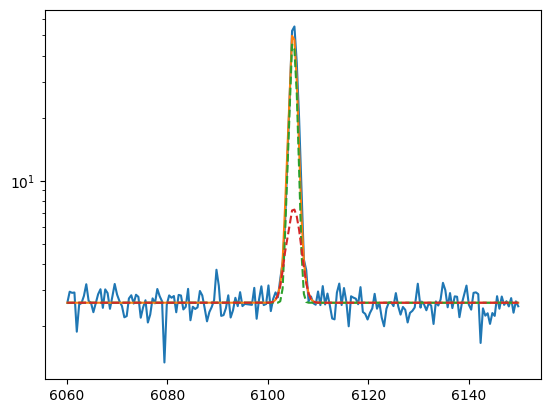

In [49]:
plt.plot(hei_5875.wavelength, hei_5875.flux)
bkg = 2.6

hei5875_nar = gaussian(hei_5875.wavelength, 7.5e1, wave_cat['HeI5875'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_5875))
hei5875_brd = gaussian(hei_5875.wavelength, 1.5e1, wave_cat['HeI5875'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_5875))

hei5875 = hei5875_nar + hei5875_brd

plt.plot(hei_5875.wavelength, hei5875 + bkg)
plt.plot(hei_5875.wavelength, hei5875_nar + bkg, ls='--')
plt.plot(hei_5875.wavelength, hei5875_brd + bkg, ls='--')
plt.yscale('log')

In [50]:
params_5875 = Parameters()
params_5875.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_5875.add('z_ratio', value=z_ratio, vary=False)
params_5875.add('sigma_hei5875_nar', value=upy.nominal_values(sigma_nar_5875), vary=False)
params_5875.add('sigma_hei5875_brd', value=upy.nominal_values(sigma_brd_5875), vary=False)
params_5875.add('Hei5875_nar', value=7.5e1, min=0.)
params_5875.add('Hei5875_brd', value=1.5e1, min=0.)
params_5875.add('bkg', value=2.6, min=0.)

def residual_hei5875(params_5875, x, data, uncertainty):
    
    z_nar = params_5875['z_nar']
    z_brd = params_5875['z_nar'] * params_5875['z_ratio']
    sigma_hei5875_nar = params_5875['sigma_hei5875_nar']
    sigma_hei5875_brd = params_5875['sigma_hei5875_brd']
    hei5875_nar_flux = params_5875['Hei5875_nar']
    hei5875_brd_flux = params_5875['Hei5875_brd']
    bkg = params_5875['bkg']
    
    x = hei_5875.wavelength
    model = gaussian(x, hei5875_nar_flux, wave_cat['HeI5875'], z_nar, sigma_hei5875_nar) + \
            gaussian(x, hei5875_brd_flux, wave_cat['HeI5875'], z_brd, sigma_hei5875_brd)
    return (model + bkg - hei_5875.flux) / hei_5875.noise

In [51]:
np.random.seed(1444)
out_hei5875 = minimize(residual_hei5875, params_5875, args=(1, 1, 1),
                   method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:19<00:00, 126.90it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 1 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [31.27408493 63.3670739  37.61216461 38.25597379]


In [52]:
out_hei5875.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03906117,1.8278e-06,(0.00%),0.039041570755652975,-inf,inf,True
z_ratio,1.00046454,,,1.0004645413076385,-inf,inf,False
sigma_hei5875_nar,0.67906752,,,0.6790675231068879,-inf,inf,False
sigma_hei5875_brd,1.26453956,,,1.264539561299041,-inf,inf,False
Hei5875_nar,83.0077326,1.29746236,(1.56%),75.0,0.00000000,inf,True
Hei5875_brd,16.9235799,1.54997326,(9.16%),15.0,0.00000000,inf,True
bkg,2.58319679,0.02033306,(0.79%),2.6,0.00000000,inf,True


In [53]:
np.random.seed(1444)
out2_hei5875 = minimize(residual_hei5875, out_hei5875.params, args=(1, 1, 1),
                   method='leastsq')

In [54]:
out2_hei5875.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03906114,2.1273e-06,(0.01%),0.039061174664503144,-inf,inf,True
z_ratio,1.00046454,0.00000000,(0.00%),1.0004645413076385,-inf,inf,False
sigma_hei5875_nar,0.67906752,0.00000000,(0.00%),0.6790675231068879,-inf,inf,False
sigma_hei5875_brd,1.26453956,0.00000000,(0.00%),1.264539561299041,-inf,inf,False
Hei5875_nar,82.9471901,1.54729283,(1.87%),83.0077325645783,0.00000000,inf,True
Hei5875_brd,17.0030195,1.84339420,(10.84%),16.92357989236799,0.00000000,inf,True
bkg,2.58370106,0.02438169,(0.94%),2.5831967918320444,0.00000000,inf,True


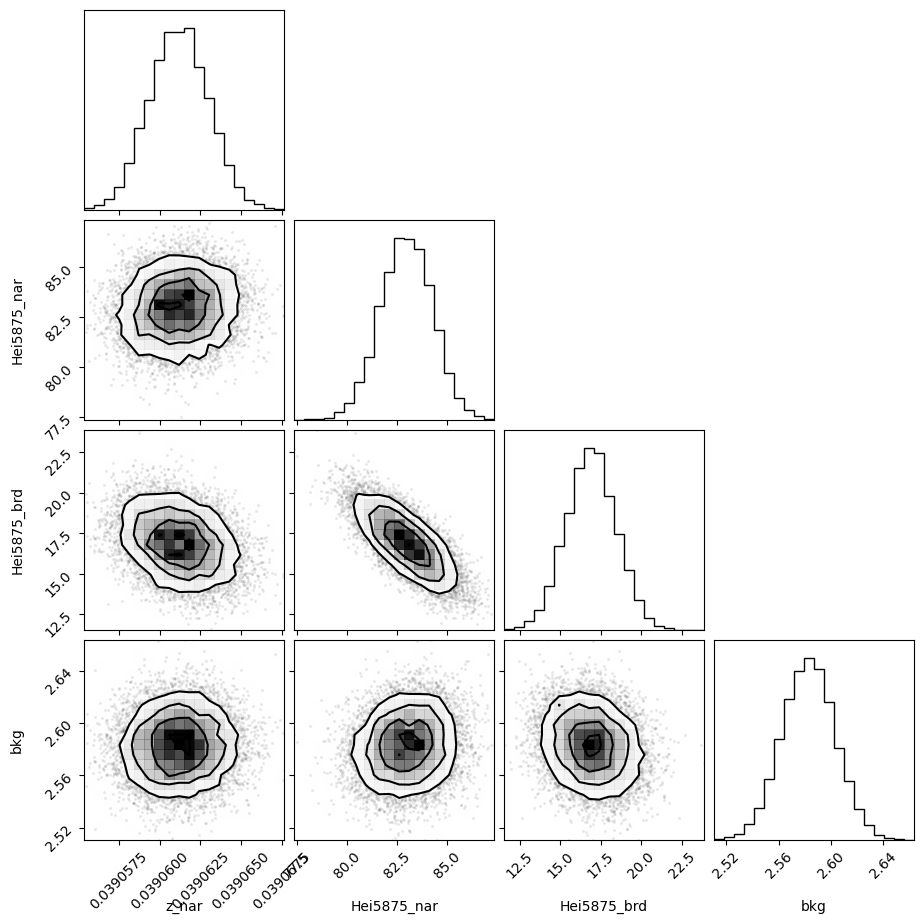

In [55]:
corner.corner(out_hei5875.flatchain, labels=out_hei5875.var_names);

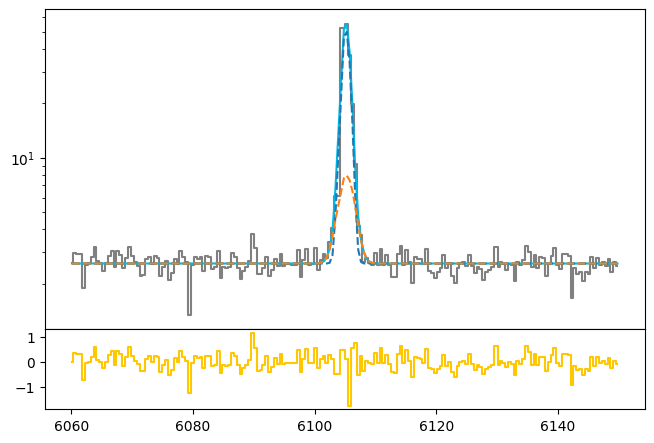

In [56]:
heic_nar_flux = out2_hei5875.params['Hei5875_nar'].value
heic_nar_std = out2_hei5875.params['Hei5875_nar'].stderr

heic_brd_flux = out2_hei5875.params['Hei5875_brd'].value
heic_brd_std = out2_hei5875.params['Hei5875_brd'].stderr

z_heic = out2_hei5875.params['z_nar'].value
z_heic_std = out2_hei5875.params['z_nar'].stderr

bkg_heic = out2_hei5875.params['bkg'].value
bkg_heic_std = out2_hei5875.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(hei_5875.wavelength, hei_5875.flux, color='gray', label='Data', where='mid')

heic_nar = gaussian(hei_5875.wavelength, heic_nar_flux, wave_cat['HeI5875'], z_heic, upy.nominal_values(sigma_nar_5875))
heic_brd = gaussian(hei_5875.wavelength, heic_brd_flux, wave_cat['HeI5875'], z_heic * z_ratio, upy.nominal_values(sigma_brd_5875))

heic = heic_nar + heic_brd

ax.plot(hei_5875.wavelength, bkg_heic + heic, color=c[0])
ax.plot(hei_5875.wavelength, bkg_heic + heic_nar, ls='--')
ax.plot(hei_5875.wavelength, bkg_heic + heic_brd, ls='--')
ax.set_yscale('log')
ax1.step(hei_5875.wavelength, hei_5875.flux - bkg_heic - heic, color=c[3], where='mid')

In [57]:
# EW
EW_HeI_5875_nar = ufloat(heic_nar_flux, heic_nar_std) / ufloat(bkg_heic, bkg_heic_std)
EW_HeI_5875_brd = ufloat(heic_brd_flux, heic_brd_std) / ufloat(bkg_heic, bkg_heic_std)
EW_HeI_5875 = (ufloat(heic_nar_flux, heic_nar_std) + ufloat(heic_brd_flux, heic_brd_std)) / ufloat(bkg_heic, bkg_heic_std)

# HeI 4471

In [58]:
sigma_arc_4471 = (m * wave_cat['HeI4471']*(1 + z_BN[igal])) + n

sigma_nar_4471 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_4471**2))
sigma_brd_4471 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_4471**2))

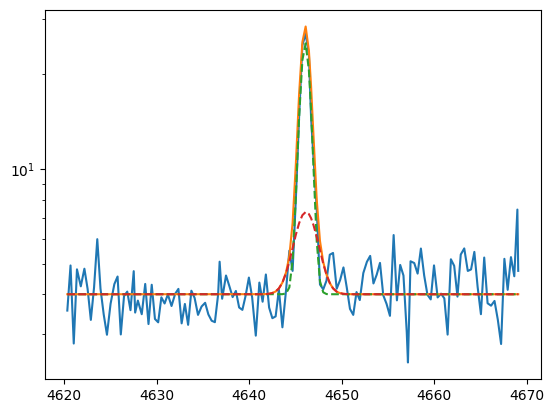

In [59]:
plt.plot(hei_4471.wavelength, hei_4471.flux)
bkg = 4

hei4471_nar = gaussian(hei_4471.wavelength, 3e1, wave_cat['HeI4471'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_4471))
hei4471_brd = gaussian(hei_4471.wavelength, 1e1, wave_cat['HeI4471'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_4471))

hei4471 = hei4471_nar + hei4471_brd

plt.plot(hei_4471.wavelength, hei4471 + bkg)
plt.plot(hei_4471.wavelength, hei4471_nar + bkg, ls='--')
plt.plot(hei_4471.wavelength, hei4471_brd + bkg, ls='--')
plt.yscale('log')

In [60]:
params_4471 = Parameters()
params_4471.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_4471.add('z_ratio', value=z_ratio, vary=False)
params_4471.add('sigma_hei4471_nar', value=upy.nominal_values(sigma_nar_4471), vary=False)
params_4471.add('sigma_hei4471_brd', value=upy.nominal_values(sigma_brd_4471), vary=False)
params_4471.add('Hei4471_nar', value=3e1, min=0.)
params_4471.add('Hei4471_brd', value=0., vary=False)
params_4471.add('bkg', value=4, min=0.)

def residual_hei4471(params_4471, x, data, uncertainty):
    
    z_nar = params_4471['z_nar']
    z_brd = params_4471['z_nar'] * params_4471['z_ratio']
    sigma_hei4471_nar = params_4471['sigma_hei4471_nar']
    sigma_hei4471_brd = params_4471['sigma_hei4471_brd']
    hei4471_nar_flux = params_4471['Hei4471_nar']
    hei4471_brd_flux = params_4471['Hei4471_brd']
    bkg = params_4471['bkg']
    
    x = hei_4471.wavelength
    model = gaussian(x, hei4471_nar_flux, wave_cat['HeI4471'], z_nar, sigma_hei4471_nar) + \
            gaussian(x, hei4471_brd_flux, wave_cat['HeI4471'], z_brd, sigma_hei4471_brd)
    return (model + bkg - hei_4471.flux) / hei_4471.noise

In [61]:
np.random.seed(1444)
out_hei4471 = minimize(residual_hei4471, params_4471, args=(1, 1, 1),
                   method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:19<00:00, 128.77it/s]


In [62]:
out_hei4471.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03904592,3.7962e-06,(0.01%),0.039041570755652975,-inf,inf,True
z_ratio,1.00046454,,,1.0004645413076385,-inf,inf,False
sigma_hei4471_nar,0.56511918,,,0.5651191754503893,-inf,inf,False
sigma_hei4471_brd,1.20718155,,,1.2071815454245378,-inf,inf,False
Hei4471_nar,32.7909545,0.76846081,(2.34%),30.0,0.00000000,inf,True
Hei4471_brd,0.00000000,,,0.0,-inf,inf,False
bkg,4.11350793,0.05726030,(1.39%),4,0.00000000,inf,True


In [63]:
np.random.seed(1444)
out2_hei4471 = minimize(residual_hei4471, out_hei4471.params, args=(1, 1, 1),
                   method='leastsq')

In [64]:
out2_hei4471.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03904598,4.1553e-06,(0.01%),0.03904592282569289,-inf,inf,True
z_ratio,1.00046454,0.00000000,(0.00%),1.0004645413076385,-inf,inf,False
sigma_hei4471_nar,0.56511918,0.00000000,(0.00%),0.5651191754503893,-inf,inf,False
sigma_hei4471_brd,1.20718155,0.00000000,(0.00%),1.2071815454245378,-inf,inf,False
Hei4471_nar,32.8005932,0.84659055,(2.58%),32.79095447523412,0.00000000,inf,True
Hei4471_brd,0.00000000,0.00000000,,0.0,-inf,inf,False
bkg,4.11342573,0.06191175,(1.51%),4.1135079302634185,0.00000000,inf,True


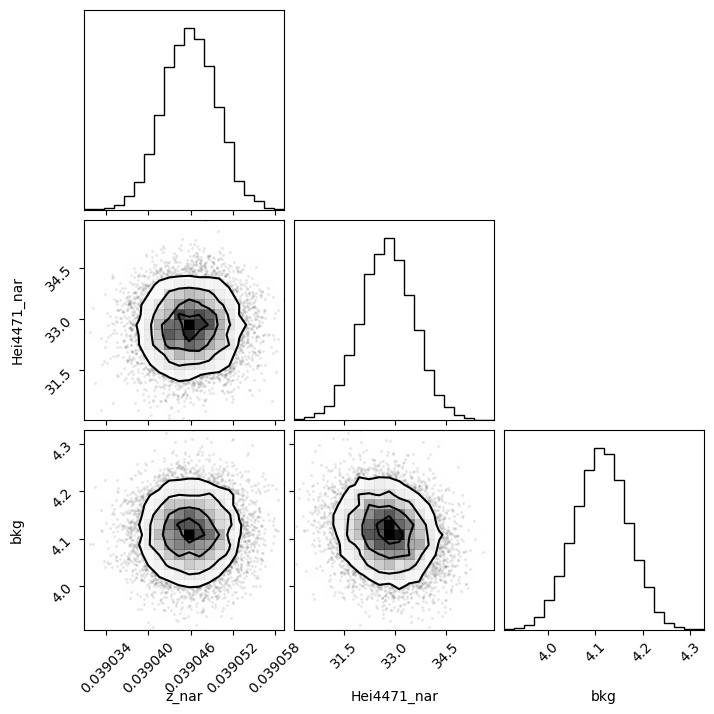

In [65]:
corner.corner(out_hei4471.flatchain, labels=out_hei4471.var_names);

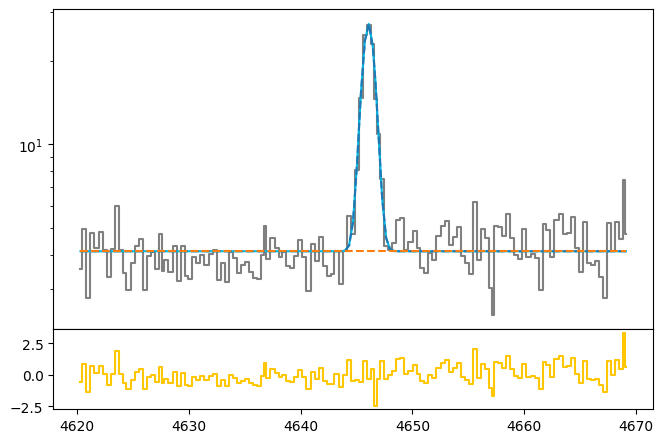

In [66]:
heid_nar_flux = out2_hei4471.params['Hei4471_nar'].value
heid_nar_std = out2_hei4471.params['Hei4471_nar'].stderr

heid_brd_flux = out2_hei4471.params['Hei4471_brd'].value
heid_brd_std = out2_hei4471.params['Hei4471_brd'].stderr

z_heid = out2_hei4471.params['z_nar'].value
z_heid_std = out2_hei4471.params['z_nar'].stderr

bkg_heid = out2_hei4471.params['bkg'].value
bkg_heid_std = out2_hei4471.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(hei_4471.wavelength, hei_4471.flux, color='gray', label='Data', where='mid')

heid_nar = gaussian(hei_4471.wavelength, heid_nar_flux, wave_cat['HeI4471'], z_heid, upy.nominal_values(sigma_nar_4471))
heid_brd = gaussian(hei_4471.wavelength, heid_brd_flux, wave_cat['HeI4471'], z_heid * z_ratio, upy.nominal_values(sigma_brd_4471))

heid = heid_nar + heid_brd

ax.plot(hei_4471.wavelength, bkg_heid + heid, color=c[0])
ax.plot(hei_4471.wavelength, bkg_heid + heid_nar, ls='--')
ax.plot(hei_4471.wavelength, bkg_heid + heid_brd, ls='--')
ax.set_yscale('log')
ax1.step(hei_4471.wavelength, hei_4471.flux - bkg_heid - heid, color=c[3], where='mid')

In [67]:
# EW
EW_HeI_4471_nar = ufloat(heid_nar_flux, heid_nar_std) / ufloat(bkg_heid, bkg_heid_std)
EW_HeI_4471_brd = ufloat(heid_brd_flux, heid_brd_std) / ufloat(bkg_heid, bkg_heid_std)
EW_HeI_4471 = (ufloat(heid_nar_flux, heid_nar_std) + ufloat(heid_brd_flux, heid_brd_std)) / ufloat(bkg_heid, bkg_heid_std)

# [NII]6548 + H$\alpha$ + [NII]6584

In [68]:
sigma_arc_ha = (m * wave_cat['Ha']*(1 + z_BN[igal])) + n

sigma_nar_ha = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_ha**2))
sigma_brd_ha = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_ha**2))

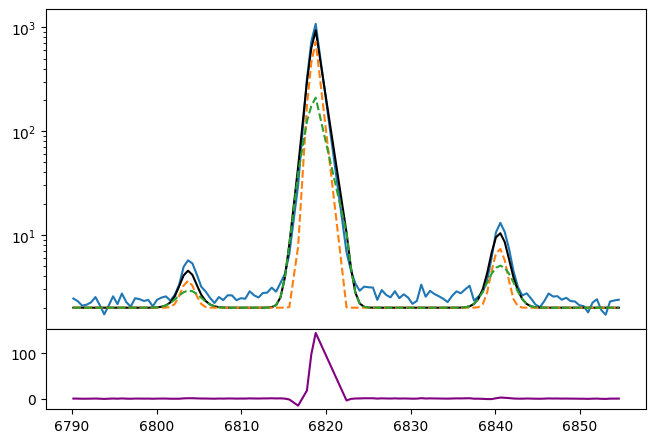

In [69]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(ha_nii.wavelength, ha_nii.flux)
bkg = 2

ha_nar = gaussian(ha_nii.wavelength, 1.4e3, wave_cat['Ha'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_ha))
ha_brd = gaussian(ha_nii.wavelength, 0.7e3, wave_cat['Ha'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_ha))

niib_nar = gaussian(ha_nii.wavelength, 0.3e1, wave_cat['[NII]6548'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_ha))
niib_brd = gaussian(ha_nii.wavelength, 0.3e1, wave_cat['[NII]6548'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_ha))

niia_nar = gaussian(ha_nii.wavelength, 1e1, wave_cat['[NII]6584'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_ha))
niia_brd = gaussian(ha_nii.wavelength, 1e1, wave_cat['[NII]6584'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_ha))

ha = ha_nar + ha_brd
niib = niib_nar + niib_brd
niia = niia_nar + niia_brd

ax.plot(ha_nii.wavelength, bkg + niib + ha + niia, color='black')
ax.plot(ha_nii.wavelength, bkg + niib_nar + ha_nar + niia_nar, ls='--')
ax.plot(ha_nii.wavelength, bkg + niib_brd + ha_brd + niia_brd, ls='--')
ax1.plot(ha_nii.wavelength, ha_nii.flux - bkg - niib - ha - niia, color='purple')
ax.set_yscale('log')

In [70]:
params_ha_nii = Parameters()
params_ha_nii.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_ha_nii.add('z_ratio', value=z_ratio, vary=False)
params_ha_nii.add('sigma_nar', value=upy.nominal_values(sigma_nar_ha), vary=False)
params_ha_nii.add('sigma_brd', value=upy.nominal_values(sigma_brd_ha), vary=False)
params_ha_nii.add('Ha_nar', value=1.4e3, min=0.)
params_ha_nii.add('Ha_brd', value=0.7e3, min=0.)
params_ha_nii.add('Niia_nar', value=1e1, min=0.)
params_ha_nii.add('Niia_brd', value=1e1, min=0.)
params_ha_nii.add('Niib_to_niia', value=1/3, min=0., max=1.)
params_ha_nii.add('bkg', value=2, vary=True)


def residual_ha_nii(params_ha_nii, x, data, uncertainty):
    
    z_nar = params_ha_nii['z_nar']
    z_brd = params_ha_nii['z_nar'] * params_ha_nii['z_ratio']
    sigma_nar = params_ha_nii['sigma_nar']
    sigma_brd = params_ha_nii['sigma_brd']
    ha_nar = params_ha_nii['Ha_nar']
    ha_brd = params_ha_nii['Ha_brd']
    niia_nar = params_ha_nii['Niia_nar']
    niia_brd = params_ha_nii['Niia_brd']
    niib_nar = params_ha_nii['Niia_nar']*params_ha_nii['Niib_to_niia']
    niib_brd = params_ha_nii['Niia_brd']*params_ha_nii['Niib_to_niia']
    bkg = params_ha_nii['bkg']
    
    x = ha_nii.wavelength
    
    model_ha = gaussian(x, ha_nar, wave_cat['Ha'], z_nar, sigma_nar) \
             + gaussian(x, ha_brd, wave_cat['Ha'], z_brd, sigma_brd)
    
    model_niia = gaussian(x, niia_nar, wave_cat['[NII]6584'], z_nar, sigma_nar) \
               + gaussian(x, niia_brd, wave_cat['[NII]6584'], z_brd, sigma_brd)
    
    model_niib = gaussian(x, niib_nar, wave_cat['[NII]6548'], z_nar, sigma_nar) \
               + gaussian(x, niib_brd, wave_cat['[NII]6548'], z_brd, sigma_brd)
    model = model_niib + model_ha + model_niia
    
    return (model + bkg - ha_nii.flux) / ha_nii.noise

In [71]:
np.random.seed(1444)
out_ha_nii = minimize(residual_ha_nii, params_ha_nii, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|███████████████████████████████████████| 2500/2500 [00:32<00:00, 76.07it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 7 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 66.78075567 123.45566794 126.86390753 168.28173242 150.35176474
 120.15613453  97.26908269]


In [72]:
out_ha_nii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03903913,8.1366e-07,(0.00%),0.039041570755652975,-inf,inf,True
z_ratio,1.00046454,,,1.0004645413076385,-inf,inf,False
sigma_nar,0.73720338,,,0.7372033768714249,-inf,inf,False
sigma_brd,1.29668671,,,1.2966867085084508,-inf,inf,False
Ha_nar,1875.92612,12.4823479,(0.67%),1400.0,0.00000000,inf,True
Ha_brd,392.859019,13.1271162,(3.34%),700.0,0.00000000,inf,True
Niia_nar,15.5202234,0.86295482,(5.56%),10.0,0.00000000,inf,True
Niia_brd,5.74061779,1.09172776,(19.02%),10.0,0.00000000,inf,True
Niib_to_niia,0.31716790,0.01650469,(5.20%),0.3333333333333333,0.00000000,1.00000000,True
bkg,2.45049685,0.02389697,(0.98%),2,-inf,inf,True


In [73]:
np.random.seed(1444)
out2_ha_nii = minimize(residual_ha_nii, out_ha_nii.params, args=(1, 1, 1),
                      method='leastsq')

In [74]:
out2_ha_nii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03903911,1.3391e-06,(0.00%),0.03903912545757585,-inf,inf,True
z_ratio,1.00046454,0.00000000,(0.00%),1.0004645413076385,-inf,inf,False
sigma_nar,0.73720338,0.00000000,(0.00%),0.7372033768714249,-inf,inf,False
sigma_brd,1.29668671,0.00000000,(0.00%),1.2966867085084508,-inf,inf,False
Ha_nar,1875.92958,20.8831059,(1.11%),1875.9261232230226,0.00000000,inf,True
Ha_brd,392.349788,21.5717798,(5.50%),392.8590189389979,0.00000000,inf,True
Niia_nar,15.5421630,1.39603162,(8.98%),15.520223424665154,0.00000000,inf,True
Niia_brd,5.70967947,1.76689570,(30.95%),5.74061779348256,0.00000000,inf,True
Niib_to_niia,0.31761016,0.02765685,(8.71%),0.31716790039903997,0.00000000,1.00000000,True
bkg,2.45011984,0.04084206,(1.67%),2.4504968499460853,-inf,inf,True


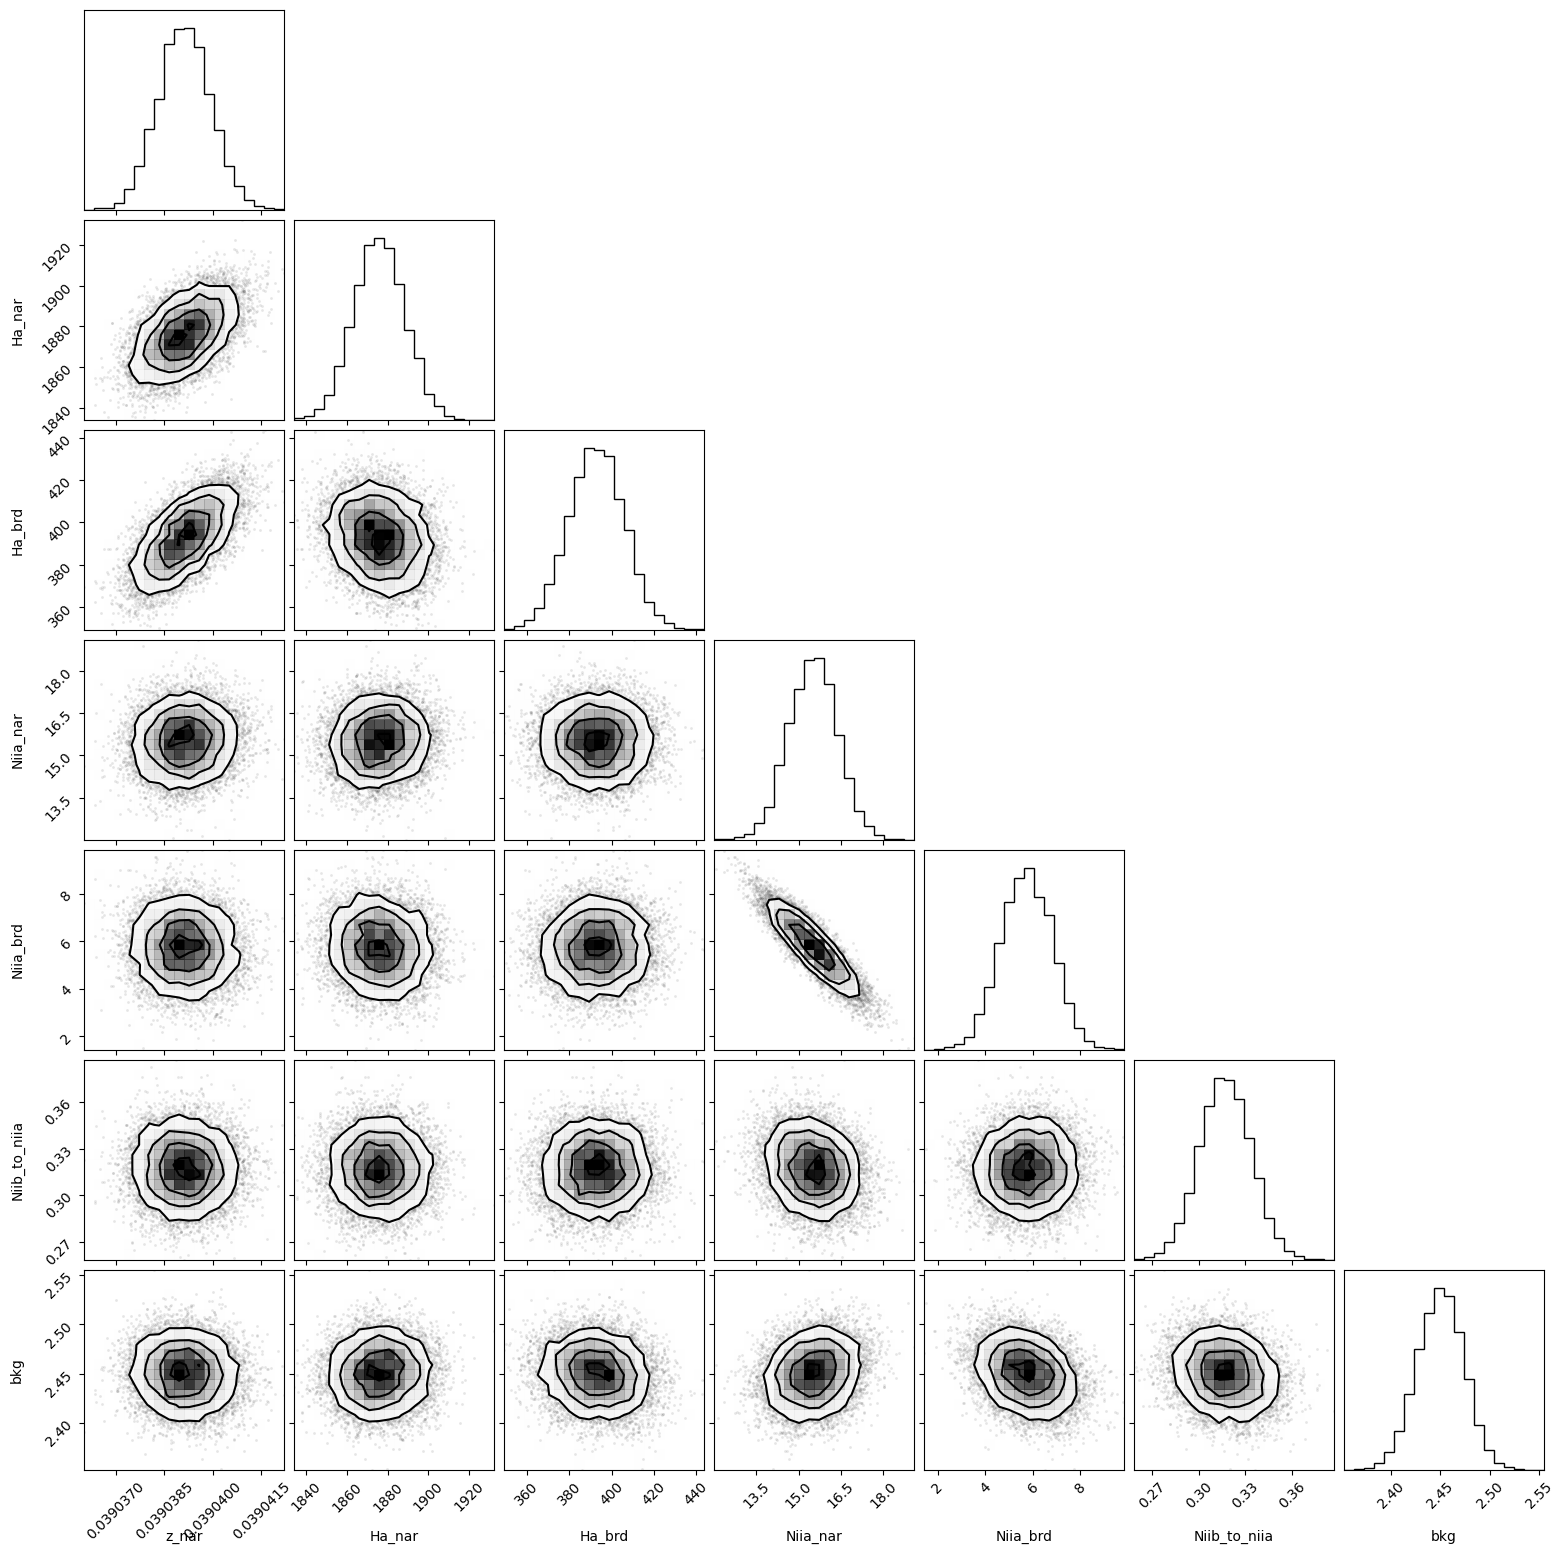

In [75]:
corner.corner(out_ha_nii.flatchain, labels=out_ha_nii.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

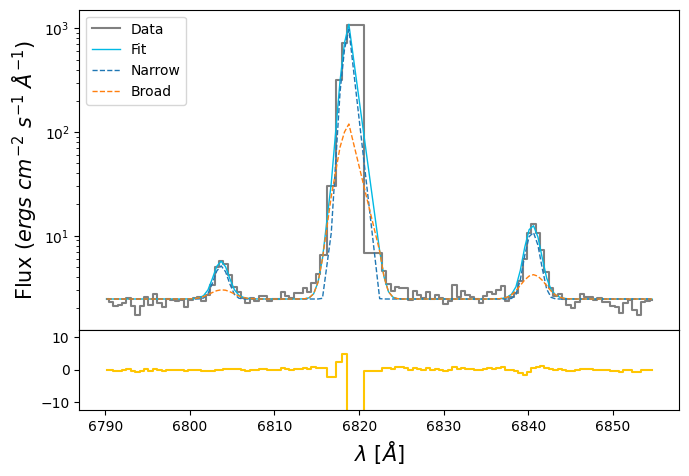

In [76]:
ha_nar_flux = out2_ha_nii.params['Ha_nar'].value
ha_nar_std = out2_ha_nii.params['Ha_nar'].stderr

ha_brd_flux = out2_ha_nii.params['Ha_brd'].value
ha_brd_std = out2_ha_nii.params['Ha_brd'].stderr

niia_nar_flux = out2_ha_nii.params['Niia_nar'].value
niia_nar_std = out2_ha_nii.params['Niia_nar'].stderr

niia_brd_flux = out2_ha_nii.params['Niia_brd'].value
niia_brd_std = out2_ha_nii.params['Niia_brd'].stderr

niib_nar_flux = niia_nar_flux * out_ha_nii.params['Niib_to_niia'].value
niib_nar_std = niia_nar_flux * out_ha_nii.params['Niib_to_niia'].stderr

niib_brd_flux = niia_brd_flux * out_ha_nii.params['Niib_to_niia'].value
niib_brd_std = niia_brd_flux * out_ha_nii.params['Niib_to_niia'].stderr

z_ha_nii = out_ha_nii.params['z_nar'].value
z_ha_nii_std = out_ha_nii.params['z_nar'].stderr

bkg_ha_nii = out_ha_nii.params['bkg'].value
bkg_ha_nii_std = out_ha_nii.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(ha_nii.wavelength, ha_nii.flux,
            color='gray', label='Data', where='mid')

ha_nar = gaussian(ha_nii.wavelength, ha_nar_flux, wave_cat['Ha'], z_ha_nii, upy.nominal_values(sigma_nar_ha))
ha_brd = gaussian(ha_nii.wavelength, ha_brd_flux, wave_cat['Ha'], z_ha_nii * z_ratio, upy.nominal_values(sigma_brd_ha))

niia_nar = gaussian(ha_nii.wavelength, niia_nar_flux, wave_cat['[NII]6584'], z_ha_nii, upy.nominal_values(sigma_nar_ha))
niia_brd = gaussian(ha_nii.wavelength, niia_brd_flux, wave_cat['[NII]6584'], z_ha_nii * z_ratio, upy.nominal_values(sigma_brd_ha))

niib_nar = gaussian(ha_nii.wavelength, niib_nar_flux, wave_cat['[NII]6548'], z_ha_nii, upy.nominal_values(sigma_nar_ha))
niib_brd = gaussian(ha_nii.wavelength, niib_brd_flux, wave_cat['[NII]6548'], z_ha_nii * z_ratio, upy.nominal_values(sigma_brd_ha))

niia = niia_nar + niia_brd
ha = ha_nar + ha_brd
niib = niib_nar + niib_brd

ax.plot(ha_nii.wavelength, bkg_ha_nii + niia + ha + niib,
        lw=1, color=c[0], label='Fit')

ax.plot(ha_nii.wavelength, bkg_ha_nii + niia_nar + ha_nar + niib_nar,
        ls='--', lw=1, label='Narrow')
ax.plot(ha_nii.wavelength, bkg_ha_nii + niia_brd + ha_brd + niib_brd,
        ls='--', lw=1, label='Broad')

ax1.step(ha_nii.wavelength, ha_nii.flux - bkg_ha_nii - niia - ha - niib,
         color=c[3], where='mid')
ax1.set_ylim(-5*bkg_ha_nii, 5*bkg_ha_nii)
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [77]:
# EW
EW_Ha_nar = ufloat(ha_nar_flux, ha_nar_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_Ha_brd = ufloat(ha_brd_flux, ha_brd_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_Ha = (ufloat(ha_nar_flux, ha_nar_std) + ufloat(ha_brd_flux, ha_brd_std)) / ufloat(bkg_ha_nii, bkg_ha_nii_std)

EW_NII_6584_nar = ufloat(niia_nar_flux, niia_nar_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_NII_6584_brd = ufloat(niia_brd_flux, niia_brd_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_NII_6584 = (ufloat(niia_nar_flux, niia_nar_std) + ufloat(niia_brd_flux, niia_brd_std)) / ufloat(bkg_ha_nii, bkg_ha_nii_std)

EW_NII_6548_nar = ufloat(niib_nar_flux, niib_nar_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_NII_6548_brd = ufloat(niib_brd_flux, niib_brd_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_NII_6548 = (ufloat(niib_nar_flux, niib_nar_std) + ufloat(niib_brd_flux, niib_brd_std)) / ufloat(bkg_ha_nii, bkg_ha_nii_std)

# [OII]7319 + [OII]7330

In [78]:
sigma_arc_7330 = (m * wave_cat['[OII]7330']*(1 + z_BN[igal])) + n

sigma_nar_7330 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_7330**2))
sigma_brd_7330 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_7330**2))

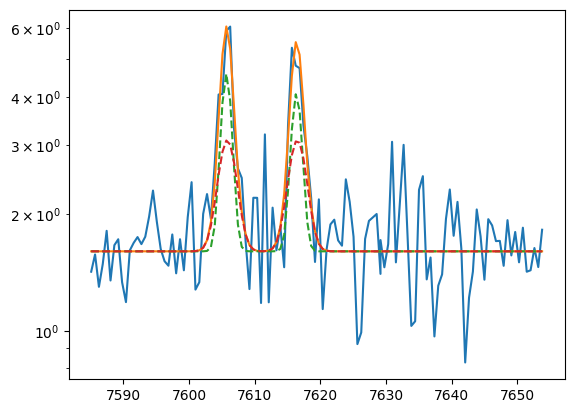

In [79]:
# Search for good initial guess

plt.plot(oii_7320.wavelength, oii_7320.flux)

oiia_nar = gaussian(oii_7320.wavelength, 5, wave_cat['[OII]7330'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_7330))
oiia_brd = gaussian(oii_7320.wavelength, 5, wave_cat['[OII]7330'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_7330))

oiib_nar = gaussian(oii_7320.wavelength, 6, wave_cat['[OII]7319'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_7330))
oiib_brd = gaussian(oii_7320.wavelength, 5, wave_cat['[OII]7319'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_7330))

oiia = oiia_nar + oiia_brd
oiib = oiib_nar + oiib_brd
bkg = 1.6

plt.plot(oii_7320.wavelength, bkg + oiib + oiia)
plt.plot(oii_7320.wavelength, bkg + oiib_nar + oiia_nar, ls='--')
plt.plot(oii_7320.wavelength, bkg + oiib_brd + oiia_brd, ls='--')

plt.yscale('log')

In [80]:
params_oii_7320 = Parameters()

params_oii_7320.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oii_7320.add('z_ratio', value=z_ratio, vary=False)
params_oii_7320.add('sigma_nar', value=upy.nominal_values(sigma_nar_7330), vary=False)
params_oii_7320.add('sigma_brd', value=upy.nominal_values(sigma_brd_7330), vary=False)
params_oii_7320.add('Oiia_nar', value=5.0, min=0.)
params_oii_7320.add('Oiia_brd', value=5.0, min=0.)
params_oii_7320.add('Oiib_nar', value=0., vary=False)
params_oii_7320.add('Oiib_brd', value=5.0, min=0.)
params_oii_7320.add('bkg', value=1.6, min=0.)

def residual_oii_7320(params_oii_7320, x, data, uncertainty):
    
    z_nar = params_oii_7320['z_nar']
    z_brd = params_oii_7320['z_nar'] * params_oii_7320['z_ratio']
    sigma_nar = params_oii_7320['sigma_nar']
    sigma_brd = params_oii_7320['sigma_brd']
    oiia_nar_flux = params_oii_7320['Oiia_nar']
    oiia_brd_flux = params_oii_7320['Oiia_brd']
    oiib_nar_flux = params_oii_7320['Oiib_nar']
    oiib_brd_flux = params_oii_7320['Oiib_brd']
    bkg = params_oii_7320['bkg']
    
    x = oii_7320.wavelength
    model_oiia = gaussian(x, oiia_nar_flux, wave_cat['[OII]7330'], z_nar, sigma_nar) + \
                 gaussian(x, oiia_brd_flux, wave_cat['[OII]7330'], z_brd, sigma_brd)
    model_oiib = gaussian(x, oiib_nar_flux, wave_cat['[OII]7319'], z_nar, sigma_nar) + \
                 gaussian(x, oiib_brd_flux, wave_cat['[OII]7319'], z_brd, sigma_brd)
    model = model_oiia + model_oiib
    return (model + bkg - oii_7320.flux) / oii_7320.noise

In [81]:
np.random.seed(1444)
out_oii_7320 = minimize(residual_oii_7320, params_oii_7320, args=(1, 1, 1),
                         method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:23<00:00, 105.41it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 1 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [47.95952302 44.54491643 46.79669078 70.98255008 43.17747167]


In [82]:
out_oii_7320.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03902551,1.1552e-05,(0.03%),0.039041570755652975,-inf,inf,True
z_ratio,1.00046454,,,1.0004645413076385,-inf,inf,False
sigma_nar,0.80341779,,,0.803417791794311,-inf,inf,False
sigma_brd,1.33544290,,,1.3354429038051363,-inf,inf,False
Oiia_nar,4.31077351,1.34500521,(31.20%),5.0,0.00000000,inf,True
Oiia_brd,4.98279757,1.70794067,(34.28%),5.0,0.00000000,inf,True
Oiib_nar,0.00000000,,,0.0,-inf,inf,False
Oiib_brd,11.5772555,1.25274131,(10.82%),5.0,0.00000000,inf,True
bkg,1.66463106,0.02917537,(1.75%),1.6,0.00000000,inf,True


In [83]:
np.random.seed(1444)
out2_oii_7320 = minimize(residual_oii_7320, out_oii_7320.params, args=(1, 1, 1),
                         method='leastsq')

In [84]:
out2_oii_7320.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03902579,1.3795e-05,(0.04%),0.039025509696866356,-inf,inf,True
z_ratio,1.00046454,0.00000000,(0.00%),1.0004645413076385,-inf,inf,False
sigma_nar,0.80341779,0.00000000,(0.00%),0.803417791794311,-inf,inf,False
sigma_brd,1.33544290,0.00000000,(0.00%),1.3354429038051363,-inf,inf,False
Oiia_nar,4.35068483,1.62458888,(37.34%),4.3107735149689645,0.00000000,inf,True
Oiia_brd,4.92207345,2.07124155,(42.08%),4.982797567496553,0.00000000,inf,True
Oiib_nar,0.00000000,0.00000000,,0.0,-inf,inf,False
Oiib_brd,11.5379833,1.46786927,(12.72%),11.577255524877753,0.00000000,inf,True
bkg,1.66431536,0.03403996,(2.05%),1.6646310591345546,0.00000000,inf,True


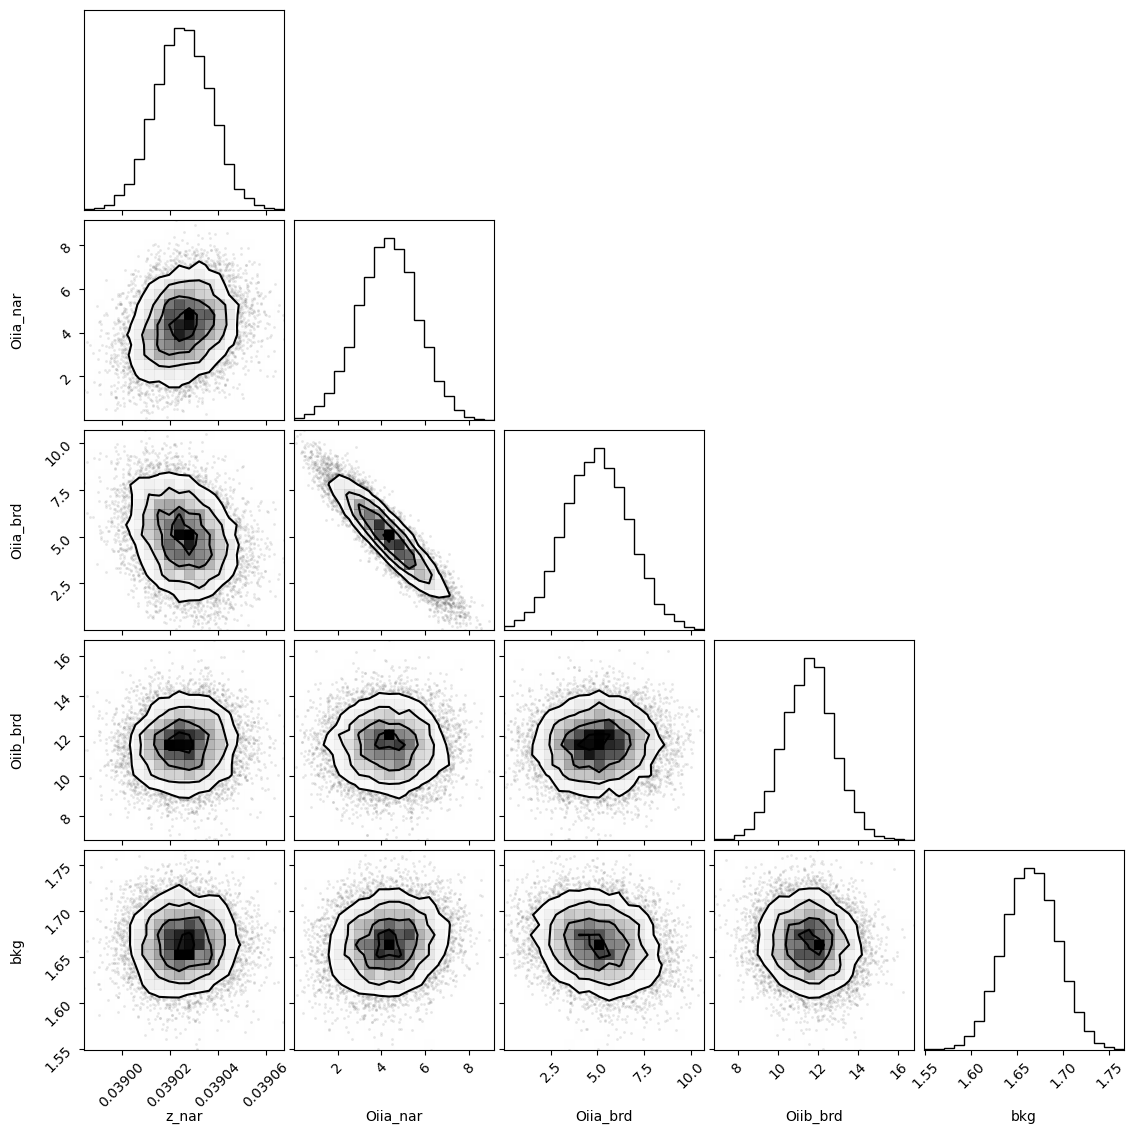

In [85]:
corner.corner(out_oii_7320.flatchain, labels=out_oii_7320.var_names);

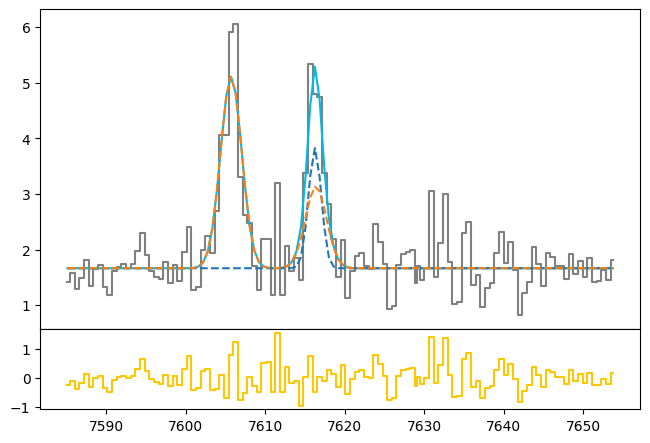

In [86]:
oiia_nar_flux = out2_oii_7320.params['Oiia_nar'].value
oiia_nar_std = out2_oii_7320.params['Oiia_nar'].stderr

oiia_brd_flux = out2_oii_7320.params['Oiia_brd'].value
oiia_brd_std = out2_oii_7320.params['Oiia_brd'].stderr

oiib_nar_flux = out2_oii_7320.params['Oiib_nar'].value
oiib_nar_std = out2_oii_7320.params['Oiib_nar'].stderr

oiib_brd_flux = out2_oii_7320.params['Oiib_brd'].value
oiib_brd_std = out2_oii_7320.params['Oiib_brd'].stderr

z_oii_7320 = out2_oii_7320.params['z_nar'].value
z_oii_7320_std = out2_oii_7320.params['z_nar'].stderr

bkg_oii_7320 = out2_oii_7320.params['bkg'].value
bkg_oii_7320_std = out2_oii_7320.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oii_7320.wavelength, oii_7320.flux, color='gray', label='Data', where='mid')

oiia_nar = gaussian(oii_7320.wavelength, oiia_nar_flux, wave_cat['[OII]7330'], z_oii_7320, upy.nominal_values(sigma_nar_7330))
oiib_nar = gaussian(oii_7320.wavelength, oiib_nar_flux, wave_cat['[OII]7319'], z_oii_7320, upy.nominal_values(sigma_nar_7330))

oiia_brd = gaussian(oii_7320.wavelength, oiia_brd_flux, wave_cat['[OII]7330'], z_oii_7320 * z_ratio, upy.nominal_values(sigma_brd_7330))
oiib_brd = gaussian(oii_7320.wavelength, oiib_brd_flux, wave_cat['[OII]7319'], z_oii_7320 * z_ratio, upy.nominal_values(sigma_brd_7330))

oiia = oiia_nar + oiia_brd
oiib = oiib_nar + oiib_brd

ax.plot(oii_7320.wavelength, bkg_oii_7320 + oiia + oiib, color=c[0])
ax.plot(oii_7320.wavelength, bkg_oii_7320 + oiia_nar + oiib_nar, ls='--')
ax.plot(oii_7320.wavelength, bkg_oii_7320 + oiia_brd + oiib_brd, ls='--')
#plt.yscale('log')
ax1.step(oii_7320.wavelength, oii_7320.flux - bkg_oii_7320 - oiia - oiib, color=c[3], where='mid')

In [87]:
# EW
EW_OII_7330_nar = ufloat(oiia_nar_flux, oiia_nar_std) / ufloat(bkg_oii_7320, bkg_oii_7320_std)
EW_OII_7330_brd = ufloat(oiia_brd_flux, oiia_brd_std) / ufloat(bkg_oii_7320, bkg_oii_7320_std)
EW_OII_7330 = (ufloat(oiia_nar_flux, oiia_nar_std) + ufloat(oiia_brd_flux, oiia_brd_std)) / ufloat(bkg_oii_7320, bkg_oii_7320_std)

EW_OII_7319_nar = ufloat(oiib_nar_flux, oiib_nar_std) / ufloat(bkg_oii_7320, bkg_oii_7320_std)
EW_OII_7319_brd = ufloat(oiib_brd_flux, oiib_brd_std) / ufloat(bkg_oii_7320, bkg_oii_7320_std)
EW_OII_7319 = (ufloat(oiib_nar_flux, oiib_nar_std) + ufloat(oiib_brd_flux, oiib_brd_std)) / ufloat(bkg_oii_7320, bkg_oii_7320_std)

# [SII]6716 + [SII]6730

In [88]:
sigma_arc_6730 = (m * wave_cat['[SII]6730']*(1 + z_BN[igal])) + n

sigma_nar_6730 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_6730**2))
sigma_brd_6730 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_6730**2))

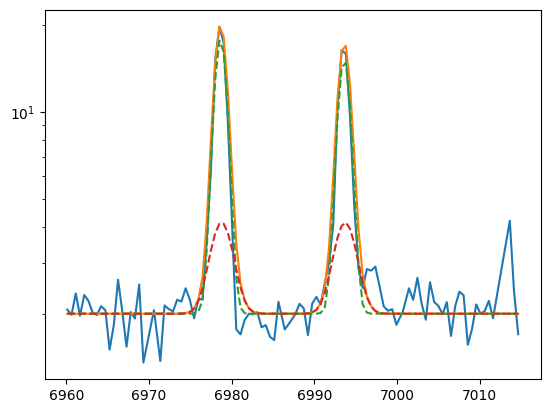

In [89]:
plt.plot(sii.wavelength, sii.flux)
bkg = 2

siia_nar = gaussian(sii.wavelength, 2.5e1, wave_cat['[SII]6730'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_6730))
siia_brd = gaussian(sii.wavelength, 7.0, wave_cat['[SII]6730'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_6730))

siib_nar = gaussian(sii.wavelength, 3.0e1, wave_cat['[SII]6716'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_6730))
siib_brd = gaussian(sii.wavelength, 7.0, wave_cat['[SII]6716'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_6730))

siia = siia_nar + siia_brd
siib = siib_nar + siib_brd

plt.plot(sii.wavelength, siia + siib + bkg)
plt.plot(sii.wavelength, siia_nar + siib_nar + bkg, ls='--')
plt.plot(sii.wavelength, siia_brd + siib_brd + bkg, ls='--')
plt.yscale('log')

In [90]:
params_sii = Parameters()
params_sii.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_sii.add('z_ratio', value=z_ratio, vary=False)
params_sii.add('sigma_nar', value=upy.nominal_values(sigma_nar_6730), vary=False)
params_sii.add('sigma_brd', value=upy.nominal_values(sigma_brd_6730), vary=False)
params_sii.add('Siia_nar', value=2.5e1, min=0.)
params_sii.add('Siia_brd', value=0., vary=False)
params_sii.add('Siib_nar', value=3.0e1, min=0.)
params_sii.add('Siib_brd', value=0., vary=False)
params_sii.add('bkg', value=2.0, min=0.)


def residual_sii(params_sii, x, data, uncertainty):
    
    z_nar = params_sii['z_nar']
    z_brd = params_sii['z_nar'] * params_sii['z_ratio']
    sigma_nar = params_sii['sigma_nar']
    sigma_brd = params_sii['sigma_brd']
    siia_nar_flux = params_sii['Siia_nar']
    siia_brd_flux = params_sii['Siia_brd']
    siib_nar_flux = params_sii['Siib_nar']
    siib_brd_flux = params_sii['Siib_brd']
    bkg = params_sii['bkg']
    
    x = sii.wavelength
    model_siia = gaussian(x, siia_nar_flux, wave_cat['[SII]6730'], z_nar, sigma_nar) + \
                 gaussian(x, siia_brd_flux, wave_cat['[SII]6730'], z_brd, sigma_brd)
    model_siib = gaussian(x, siib_nar_flux, wave_cat['[SII]6716'], z_nar, sigma_nar) + \
                 gaussian(x, siib_brd_flux, wave_cat['[SII]6716'], z_brd, sigma_brd)
    model = model_siia + model_siib
    return (model + bkg - sii.flux) / sii.noise

In [91]:
np.random.seed(1444)
out_sii = minimize(residual_sii, params_sii, args=(1, 1, 1),
                    method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:24<00:00, 102.56it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 1 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [39.55572999 42.18683861 51.93831299 37.91285489]


In [92]:
out_sii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03903517,1.4659e-06,(0.00%),0.039041570755652975,-inf,inf,True
z_ratio,1.00046454,,,1.0004645413076385,-inf,inf,False
sigma_nar,0.75159613,,,0.7515961326989526,-inf,inf,False
sigma_brd,1.30492312,,,1.3049231195131266,-inf,inf,False
Siia_nar,26.1186449,0.43350830,(1.66%),25.0,0.00000000,inf,True
Siia_brd,0.00000000,,,0.0,-inf,inf,False
Siib_nar,32.4409089,0.48386887,(1.49%),30.0,0.00000000,inf,True
Siib_brd,0.00000000,,,0.0,-inf,inf,False
bkg,2.04277611,0.02420472,(1.18%),2.0,0.00000000,inf,True


In [93]:
np.random.seed(1444)
out2_sii = minimize(residual_sii, out_sii.params, args=(1, 1, 1),
                    method='leastsq')

In [94]:
out2_sii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03903513,2.5237e-06,(0.01%),0.03903517420786805,-inf,inf,True
z_ratio,1.00046454,0.00000000,(0.00%),1.0004645413076385,-inf,inf,False
sigma_nar,0.75159613,0.00000000,(0.00%),0.7515961326989526,-inf,inf,False
sigma_brd,1.30492312,0.00000000,(0.00%),1.3049231195131266,-inf,inf,False
Siia_nar,26.1132041,0.71494818,(2.74%),26.118644859768473,0.00000000,inf,True
Siia_brd,0.00000000,0.00000000,,0.0,-inf,inf,False
Siib_nar,32.4291292,0.80416849,(2.48%),32.440908881894714,0.00000000,inf,True
Siib_brd,0.00000000,0.00000000,,0.0,-inf,inf,False
bkg,2.04244704,0.03975071,(1.95%),2.042776110360631,0.00000000,inf,True


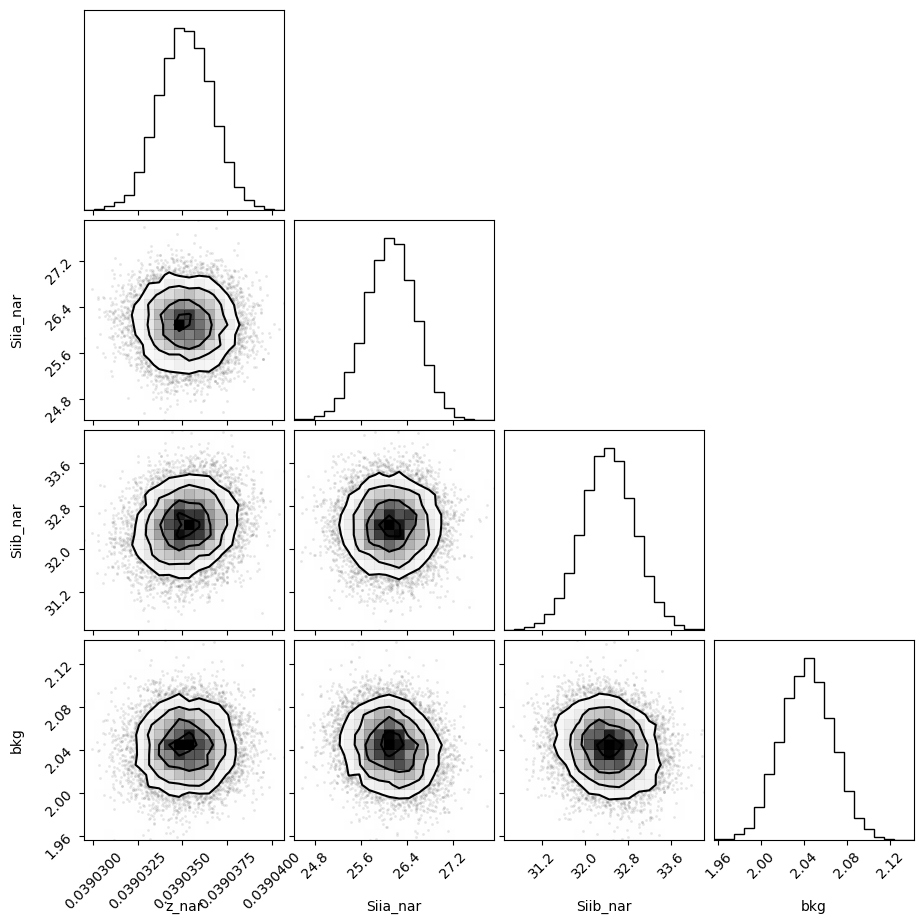

In [95]:
corner.corner(out_sii.flatchain, labels=out_sii.var_names);

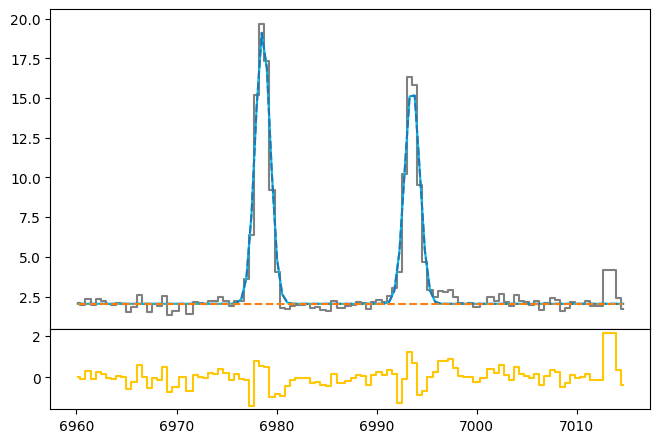

In [96]:
siia_nar_flux = out2_sii.params['Siia_nar'].value
siia_nar_std = out2_sii.params['Siia_nar'].stderr

siia_brd_flux = out2_sii.params['Siia_brd'].value
siia_brd_std = out2_sii.params['Siia_brd'].stderr

siib_nar_flux = out2_sii.params['Siib_nar'].value
siib_nar_std = out2_sii.params['Siib_nar'].stderr

siib_brd_flux = out2_sii.params['Siib_brd'].value
siib_brd_std = out2_sii.params['Siib_brd'].stderr

z_sii = out2_sii.params['z_nar'].value
z_sii_std = out2_sii.params['z_nar'].stderr

bkg_sii = out2_sii.params['bkg'].value
bkg_sii_std = out2_sii.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(sii.wavelength, sii.flux, color='gray', label='Data', where='mid')

siia_nar = gaussian(sii.wavelength, siia_nar_flux, wave_cat['[SII]6730'], z_sii, upy.nominal_values(sigma_nar_6730))
siib_nar = gaussian(sii.wavelength, siib_nar_flux, wave_cat['[SII]6716'], z_sii, upy.nominal_values(sigma_nar_6730))

siia_brd = gaussian(sii.wavelength, siia_brd_flux, wave_cat['[SII]6730'], z_sii * z_ratio, upy.nominal_values(sigma_brd_6730))
siib_brd = gaussian(sii.wavelength, siib_brd_flux, wave_cat['[SII]6716'], z_sii * z_ratio, upy.nominal_values(sigma_brd_6730))

siia = siia_nar + siia_brd
siib = siib_nar + siib_brd

ax.plot(sii.wavelength, bkg_sii + siia + siib, color=c[0])
ax.plot(sii.wavelength, bkg_sii + siia_nar + siib_nar, ls='--')
ax.plot(sii.wavelength, bkg_sii + siia_brd + siib_brd, ls='--')
#plt.yscale('log')
ax1.step(sii.wavelength, sii.flux - bkg_sii - siia - siib, color=c[3], where='mid')

In [97]:
# EW
EW_SII_6730_nar = ufloat(siia_nar_flux, siia_nar_std) / ufloat(bkg_sii, bkg_sii_std)
EW_SII_6730_brd = ufloat(siia_brd_flux, siia_brd_std) / ufloat(bkg_sii, bkg_sii_std)
EW_SII_6730 = (ufloat(siia_nar_flux, siia_nar_std) + ufloat(siia_brd_flux, siia_brd_std)) / ufloat(bkg_sii, bkg_sii_std)

EW_SII_6716_nar = ufloat(siib_nar_flux, siib_nar_std) / ufloat(bkg_sii, bkg_sii_std)
EW_SII_6716_brd = ufloat(siib_brd_flux, siib_brd_std) / ufloat(bkg_sii, bkg_sii_std)
EW_SII_6716 = (ufloat(siib_nar_flux, siib_nar_std) + ufloat(siib_brd_flux, siib_brd_std)) / ufloat(bkg_sii, bkg_sii_std)

# H$\beta$

In [98]:
sigma_arc_hb = (m * wave_cat['Hb']*(1 + z_BN[igal])) + n

sigma_nar_hb = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_hb**2))
sigma_brd_hb = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_hb**2))

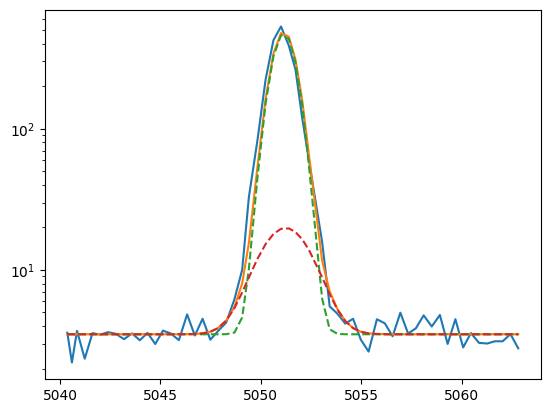

In [99]:
plt.plot(hbeta.wavelength, hbeta.flux)
bkg = 3.5

hb_nar = gaussian(hbeta.wavelength, 0.7e3, wave_cat['Hb'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_hb))
hb_brd = gaussian(hbeta.wavelength, 0.5e2, wave_cat['Hb'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_hb))

hb = hb_nar + hb_brd

plt.plot(hbeta.wavelength, hb + bkg)
plt.plot(hbeta.wavelength, hb_nar + bkg, ls='--')
plt.plot(hbeta.wavelength, hb_brd + bkg, ls='--')
plt.yscale('log')

In [100]:
params_hb = Parameters()
params_hb.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_hb.add('z_ratio', value=z_ratio, vary=False)
params_hb.add('sigma_nar', value=upy.nominal_values(sigma_nar_hb), vary=False)
params_hb.add('sigma_brd', value=upy.nominal_values(sigma_brd_hb), vary=False)
params_hb.add('Hb_nar', value=0.7e3, min=0.)
params_hb.add('Hb_brd', value=0.5e2, min=0.)
params_hb.add('bkg', value=3.5, min=0.)

def residual_hb(params_hb, x, data, uncertainty):
    
    z_nar = params_hb['z_nar']
    z_brd = params_hb['z_nar'] * params_hb['z_ratio']
    sigma_nar = params_hb['sigma_nar']
    sigma_brd = params_hb['sigma_brd']
    hb_nar_flux = params_hb['Hb_nar']
    hb_brd_flux = params_hb['Hb_brd']
    bkg = params_hb['bkg']
    
    x = hbeta.wavelength
    model = gaussian(x, hb_nar_flux, wave_cat['Hb'], z_nar, sigma_nar) + \
            gaussian(x, hb_brd_flux, wave_cat['Hb'], z_brd, sigma_brd)
    return (model + bkg - hbeta.flux) / hbeta.noise

In [101]:
np.random.seed(1444)
out_hb = minimize(residual_hb, params_hb, args=(1, 1, 1),
                   method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:17<00:00, 139.74it/s]

The chain is shorter than 50 times the integrated autocorrelation time for 1 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [17.11453569 61.36082081 40.7733141  38.44793776]


In [102]:
out_hb.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03901635,7.6627e-07,(0.00%),0.039041570755652975,-inf,inf,True
z_ratio,1.00046454,,,1.0004645413076385,-inf,inf,False
sigma_nar,0.59595256,,,0.5959525649718914,-inf,inf,False
sigma_brd,1.22191942,,,1.2219194166754304,-inf,inf,False
Hb_nar,748.225002,4.46673298,(0.60%),700.0,0.00000000,inf,True
Hb_brd,50.9735312,4.56622125,(8.96%),50.0,0.00000000,inf,True
bkg,3.52813598,0.07652147,(2.17%),3.5,0.00000000,inf,True


In [103]:
np.random.seed(1444)
out2_hb = minimize(residual_hb, out_hb.params, args=(1, 1, 1),
                   method='leastsq')

In [104]:
out2_hb.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03901635,1.2361e-06,(0.00%),0.03901635321105563,-inf,inf,True
z_ratio,1.00046454,0.00000000,(0.00%),1.0004645413076385,-inf,inf,False
sigma_nar,0.59595256,0.00000000,(0.00%),0.5959525649718914,-inf,inf,False
sigma_brd,1.22191942,0.00000000,(0.00%),1.2219194166754304,-inf,inf,False
Hb_nar,748.226868,7.04587561,(0.94%),748.2250017738563,0.00000000,inf,True
Hb_brd,51.1736631,7.53752313,(14.73%),50.97353124129377,0.00000000,inf,True
bkg,3.52763893,0.12134494,(3.44%),3.5281359763567224,0.00000000,inf,True


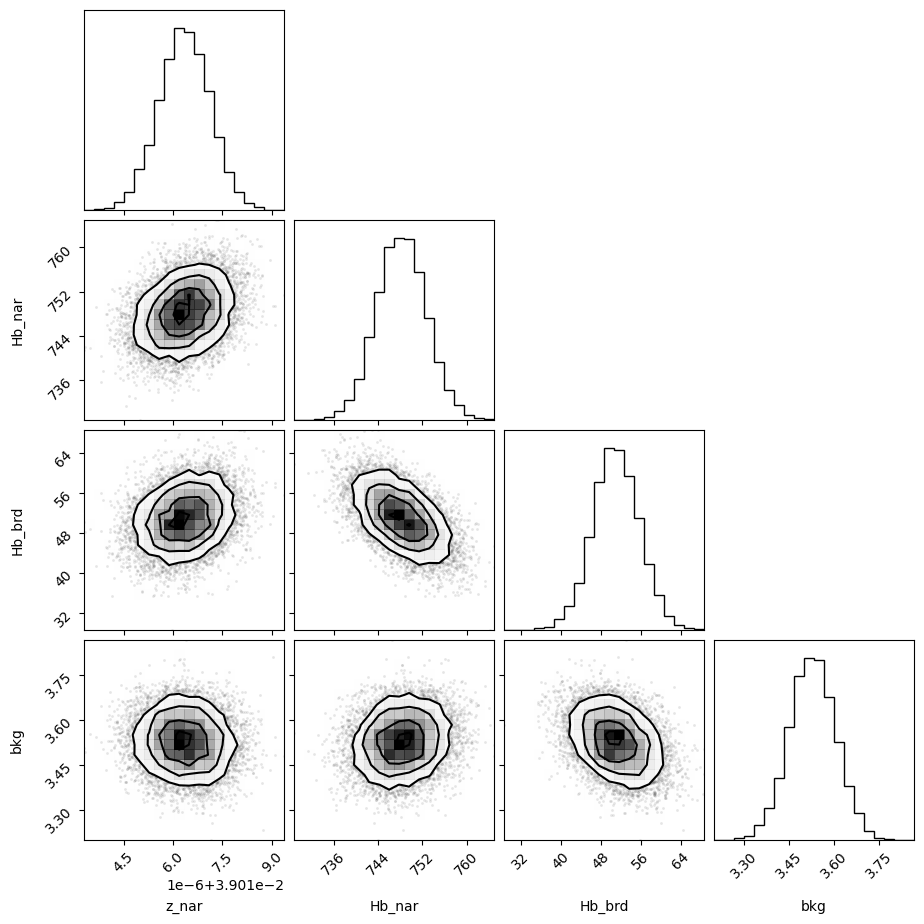

In [105]:
corner.corner(out_hb.flatchain, labels=out_hb.var_names);

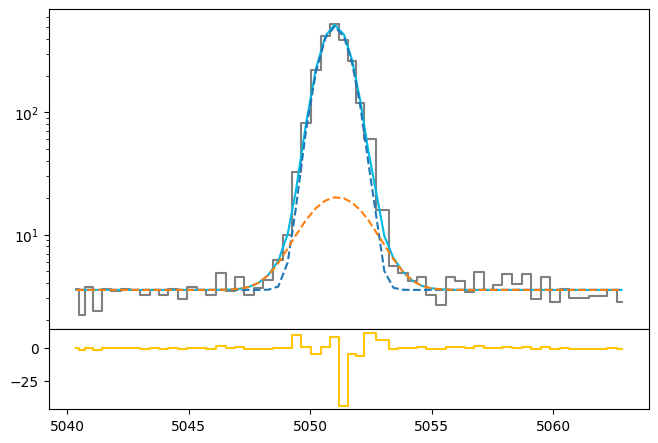

In [106]:
hb_nar_flux = out2_hb.params['Hb_nar'].value
hb_nar_std = out2_hb.params['Hb_nar'].stderr

hb_brd_flux = out2_hb.params['Hb_brd'].value
hb_brd_std = out2_hb.params['Hb_brd'].stderr

z_hb = out2_hb.params['z_nar'].value
z_hb_std = out2_hb.params['z_nar'].stderr

bkg_hb = out2_hb.params['bkg'].value
bkg_hb_std = out2_hb.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(hbeta.wavelength, hbeta.flux, color='gray', label='Data', where='mid')

hb_nar = gaussian(hbeta.wavelength, hb_nar_flux, wave_cat['Hb'], z_hb, upy.nominal_values(sigma_nar_hb))
hb_brd = gaussian(hbeta.wavelength, hb_brd_flux, wave_cat['Hb'], z_hb * z_ratio, upy.nominal_values(sigma_brd_hb))

hb = hb_nar + hb_brd

ax.plot(hbeta.wavelength, bkg_hb + hb, color=c[0])
ax.plot(hbeta.wavelength, bkg_hb + hb_nar, ls='--')
ax.plot(hbeta.wavelength, bkg_hb + hb_brd, ls='--')
ax.set_yscale('log')
ax1.step(hbeta.wavelength, hbeta.flux - bkg_hb - hb, color=c[3], where='mid')

In [107]:
# EW
EW_Hb_nar = ufloat(hb_nar_flux, hb_nar_std) / ufloat(bkg_hb, bkg_hb_std)
EW_Hb_brd = ufloat(hb_brd_flux, hb_brd_std) / ufloat(bkg_hb, bkg_hb_std)
EW_Hb = (ufloat(hb_nar_flux, hb_nar_std) + ufloat(hb_brd_flux, hb_brd_std)) / ufloat(bkg_hb, bkg_hb_std)

# H$\gamma$

In [108]:
sigma_arc_hg = (m * wave_cat['Hg']*(1 + z_BN[igal])) + n

sigma_nar_hg = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_hg**2))
sigma_brd_hg = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_hg**2))

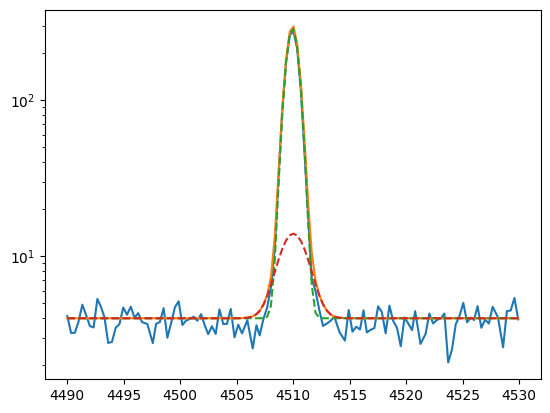

In [109]:
plt.plot(hgamma.wavelength, hgamma.flux)
bkg = 4

hg_nar = gaussian(hgamma.wavelength, 4e2, wave_cat['Hg'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_hg))
hg_brd = gaussian(hgamma.wavelength, 3e1, wave_cat['Hg'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_hg))

hg = hg_nar + hg_brd

plt.plot(hgamma.wavelength, hg + bkg)
plt.plot(hgamma.wavelength, hg_nar + bkg, ls='--')
plt.plot(hgamma.wavelength, hg_brd + bkg, ls='--')
plt.yscale('log')

In [110]:
params_hg = Parameters()
params_hg.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_hg.add('z_ratio', value=z_ratio, vary=False)
params_hg.add('sigma_nar', value=upy.nominal_values(sigma_nar_hg), vary=False)
params_hg.add('sigma_brd', value=upy.nominal_values(sigma_brd_hg), vary=False)
params_hg.add('Hg_nar', value=4.0e2, min=0.)
params_hg.add('Hg_brd', value=3.0e1, min=0.)
params_hg.add('bkg', value=4, min=0.)

def residual_hg(params_hg, x, data, uncertainty):
    
    z_nar = params_hg['z_nar']
    z_brd = params_hg['z_nar'] * params_hg['z_ratio']
    sigma_nar = params_hg['sigma_nar']
    sigma_brd = params_hg['sigma_brd']
    hg_nar_flux = params_hg['Hg_nar']
    hg_brd_flux = params_hg['Hg_brd']
    bkg = params_hg['bkg']
    
    x = hgamma.wavelength
    model = gaussian(x, hg_nar_flux, wave_cat['Hg'], z_nar, sigma_nar) + \
            gaussian(x, hg_brd_flux, wave_cat['Hg'], z_brd, sigma_brd)
    return (model + bkg - hgamma.flux) / hgamma.noise

In [111]:
np.random.seed(1444)
out_hg = minimize(residual_hg, params_hg, args=(1, 1, 1),
                   method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:18<00:00, 138.13it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 1 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [42.93929778 32.79424957 79.4710773  43.58994479]


In [112]:
out_hg.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03903771,7.7346e-07,(0.00%),0.039041570755652975,-inf,inf,True
z_ratio,1.00046454,,,1.0004645413076385,-inf,inf,False
sigma_nar,0.55492791,,,0.5549279084218888,-inf,inf,False
sigma_brd,1.20244442,,,1.2024444206271407,-inf,inf,False
Hg_nar,383.159144,2.67755408,(0.70%),400.0,0.00000000,inf,True
Hg_brd,14.2936418,2.58255972,(18.07%),30.0,0.00000000,inf,True
bkg,3.77687335,0.06592449,(1.75%),4,0.00000000,inf,True


In [113]:
np.random.seed(1444)
out2_hg = minimize(residual_hg, out_hg.params, args=(1, 1, 1),
                   method='leastsq')

In [114]:
out2_hg.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03903769,7.8281e-07,(0.00%),0.039037706612684756,-inf,inf,True
z_ratio,1.00046454,0.00000000,(0.00%),1.0004645413076385,-inf,inf,False
sigma_nar,0.55492791,0.00000000,(0.00%),0.5549279084218888,-inf,inf,False
sigma_brd,1.20244442,0.00000000,(0.00%),1.2024444206271407,-inf,inf,False
Hg_nar,383.110692,2.70809776,(0.71%),383.1591437105525,0.00000000,inf,True
Hg_brd,14.4156423,2.59608090,(18.01%),14.293641785643757,0.00000000,inf,True
bkg,3.77681230,0.06391375,(1.69%),3.7768733450835095,0.00000000,inf,True


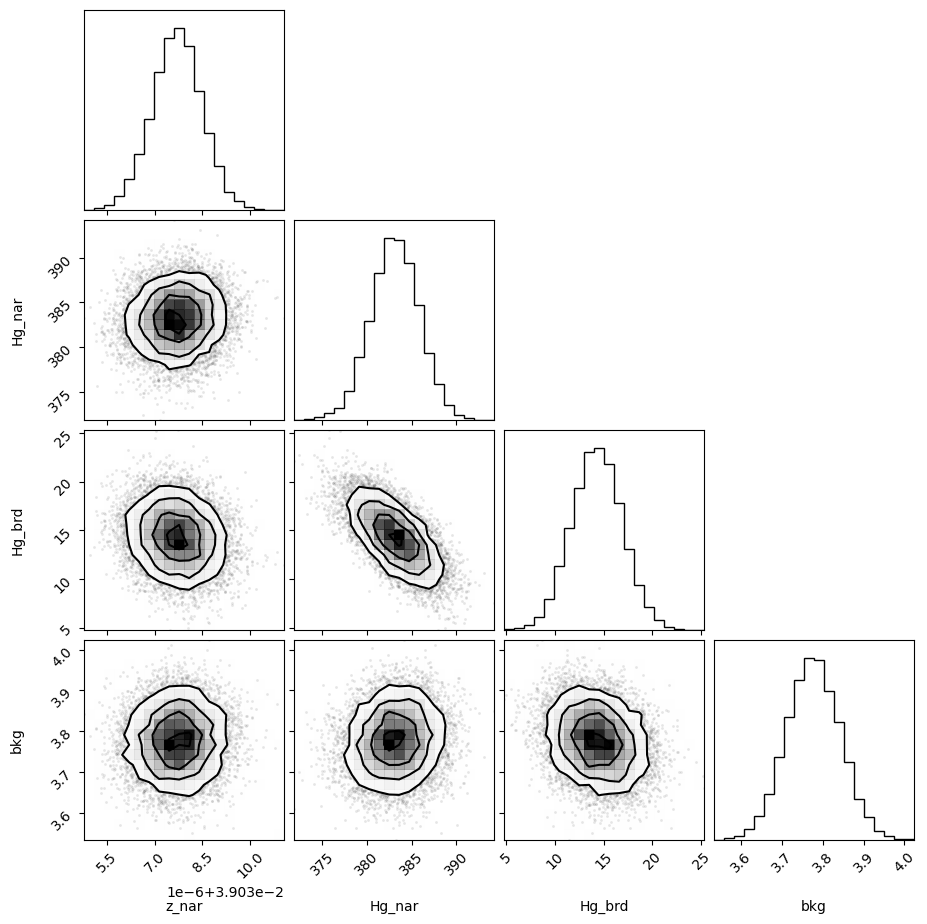

In [115]:
corner.corner(out_hg.flatchain, labels=out_hg.var_names);

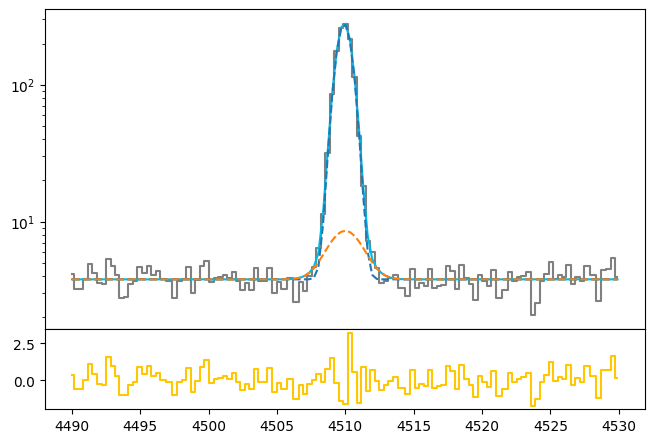

In [116]:
hg_nar_flux = out2_hg.params['Hg_nar'].value
hg_nar_std = out2_hg.params['Hg_nar'].stderr

hg_brd_flux = out2_hg.params['Hg_brd'].value
hg_brd_std = out2_hg.params['Hg_brd'].stderr

z_hg = out2_hg.params['z_nar'].value
z_hg_std = out2_hg.params['z_nar'].stderr

bkg_hg = out2_hg.params['bkg'].value
bkg_hg_std = out2_hg.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(hgamma.wavelength, hgamma.flux, color='gray', label='Data', where='mid')

hg_nar = gaussian(hgamma.wavelength, hg_nar_flux, wave_cat['Hg'],           z_hg, upy.nominal_values(sigma_nar_hg))
hg_brd = gaussian(hgamma.wavelength, hg_brd_flux, wave_cat['Hg'], z_hg * z_ratio, upy.nominal_values(sigma_brd_hg))

hg = hg_nar + hg_brd

ax.plot(hgamma.wavelength, bkg_hg + hg, color=c[0])
ax.plot(hgamma.wavelength, bkg_hg + hg_nar, ls='--')
ax.plot(hgamma.wavelength, bkg_hg + hg_brd, ls='--')
ax.set_yscale('log')
ax1.step(hgamma.wavelength, hgamma.flux - bkg_hg - hg, color=c[3], where='mid')

In [117]:
# EW
EW_Hg_nar = ufloat(hg_nar_flux, hg_nar_std) / ufloat(bkg_hg, bkg_hg_std)
EW_Hg_brd = ufloat(hg_brd_flux, hg_brd_std) / ufloat(bkg_hg, bkg_hg_std)
EW_Hg = (ufloat(hg_nar_flux, hg_nar_std) + ufloat(hg_brd_flux, hg_brd_std)) / ufloat(bkg_hg, bkg_hg_std)

# H$\delta$

In [118]:
sigma_arc_hd = (m * wave_cat['Hd']*(1 + z_BN[igal])) + n

sigma_nar_hd = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_hd**2))
sigma_brd_hd = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_hd**2))

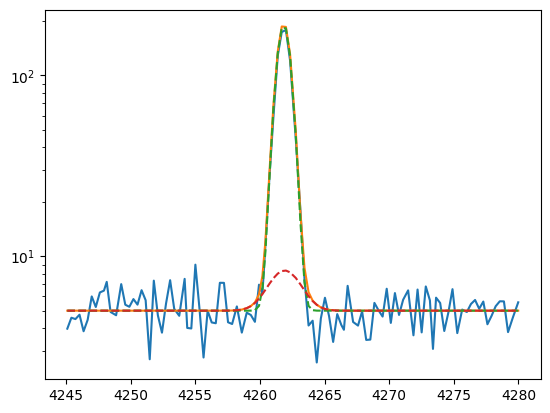

In [119]:
plt.plot(hdelta.wavelength, hdelta.flux)
bkg = 5.0

hd_nar = gaussian(hdelta.wavelength, 2.5e2, wave_cat['Hd'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_hd))
hd_brd = gaussian(hdelta.wavelength, 1e1, wave_cat['Hd'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_hd))

hd = hd_nar + hd_brd

plt.plot(hdelta.wavelength, hd + bkg)
plt.plot(hdelta.wavelength, hd_nar + bkg, ls='--')
plt.plot(hdelta.wavelength, hd_brd + bkg, ls='--')
plt.yscale('log')

In [120]:
params_hd = Parameters()
params_hd.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_hd.add('z_ratio', value=z_ratio, vary=False)
params_hd.add('sigma_nar', value=upy.nominal_values(sigma_nar_hd), vary=False)
params_hd.add('sigma_brd', value=upy.nominal_values(sigma_brd_hd), vary=False)
params_hd.add('Hd_nar', value=2.5e2, min=0.)
params_hd.add('Hd_brd', value=0., vary=False)
params_hd.add('bkg', value=5.0, min=0.)

def residual_hd(params_hd, x, data, uncertainty):
    
    z_nar = params_hd['z_nar']
    z_brd = params_hd['z_nar'] * params_hd['z_ratio']
    sigma_nar = params_hd['sigma_nar']
    sigma_brd = params_hd['sigma_brd']
    hd_nar_flux = params_hd['Hd_nar']
    hd_brd_flux = params_hd['Hd_brd']
    bkg = params_hd['bkg']
    
    x = hdelta.wavelength
    model = gaussian(x, hd_nar_flux, wave_cat['Hd'], z_nar, sigma_nar) + \
            gaussian(x, hd_brd_flux, wave_cat['Hd'], z_brd, sigma_brd)
    return (model + bkg - hdelta.flux) / hdelta.noise

In [121]:
np.random.seed(1444)
out_hd = minimize(residual_hd, params_hd, args=(1, 1, 1),
                   method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:17<00:00, 139.27it/s]


In [122]:
out_hd.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03904279,1.4726e-06,(0.00%),0.039041570755652975,-inf,inf,True
z_ratio,1.00046454,,,1.0004645413076385,-inf,inf,False
sigma_nar,0.53659817,,,0.5365981684001971,-inf,inf,False
sigma_brd,1.19409597,,,1.1940959741504424,-inf,inf,False
Hd_nar,239.190570,2.22370511,(0.93%),250.0,0.00000000,inf,True
Hd_brd,0.00000000,,,0.0,-inf,inf,False
bkg,5.04941787,0.10126456,(2.01%),5.0,0.00000000,inf,True


In [123]:
np.random.seed(1444)
out2_hd = minimize(residual_hd, out_hd.params, args=(1, 1, 1),
                   method='leastsq')

In [124]:
out2_hd.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03904282,1.6852e-06,(0.00%),0.03904279402779094,-inf,inf,True
z_ratio,1.00046454,0.00000000,(0.00%),1.0004645413076385,-inf,inf,False
sigma_nar,0.53659817,0.00000000,(0.00%),0.5365981684001971,-inf,inf,False
sigma_brd,1.19409597,0.00000000,(0.00%),1.1940959741504424,-inf,inf,False
Hd_nar,239.210287,2.58611098,(1.08%),239.1905698409376,0.00000000,inf,True
Hd_brd,0.00000000,0.00000000,,0.0,-inf,inf,False
bkg,5.05019594,0.11603648,(2.30%),5.04941786712317,0.00000000,inf,True


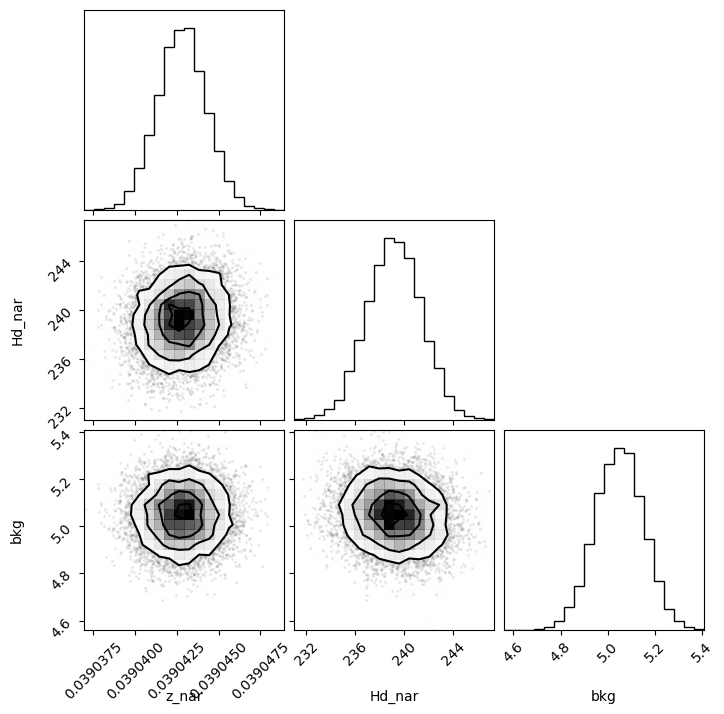

In [125]:
corner.corner(out_hd.flatchain, labels=out_hd.var_names);

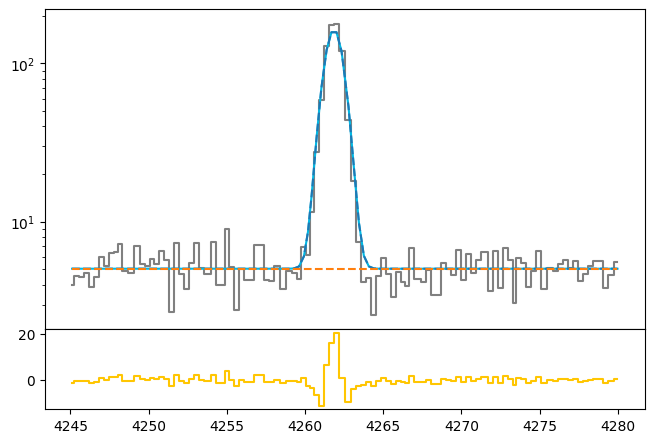

In [126]:
hd_nar_flux = out2_hd.params['Hd_nar'].value
hd_nar_std = out2_hd.params['Hd_nar'].stderr

hd_brd_flux = out2_hd.params['Hd_brd'].value
hd_brd_std = out2_hd.params['Hd_brd'].stderr

z_hd = out2_hd.params['z_nar'].value
z_hd_std = out2_hd.params['z_nar'].stderr

bkg_hd = out2_hd.params['bkg'].value
bkg_hd_std = out2_hd.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(hdelta.wavelength, hdelta.flux, color='gray', label='Data', where='mid')

hd_nar = gaussian(hdelta.wavelength, hd_nar_flux, wave_cat['Hd'], z_hd, sigma_nar_oiii_4959)
hd_brd = gaussian(hdelta.wavelength, hd_brd_flux, wave_cat['Hd'], z_hd * z_ratio, sigma_brd_oiii_4959)

hd = hd_nar + hd_brd

ax.plot(hdelta.wavelength, bkg_hd + hd, color=c[0])
ax.plot(hdelta.wavelength, bkg_hd + hd_nar, ls='--')
ax.plot(hdelta.wavelength, bkg_hd + hd_brd, ls='--')
ax.set_yscale('log')
ax1.step(hdelta.wavelength, hdelta.flux - bkg_hd - hd, color=c[3], where='mid')

In [127]:
# EW
EW_Hd_nar = ufloat(hd_nar_flux, hd_nar_std) / ufloat(bkg_hd, bkg_hd_std)
EW_Hd_brd = ufloat(hd_brd_flux, hd_brd_std) / ufloat(bkg_hd, bkg_hd_std)
EW_Hd = (ufloat(hd_nar_flux, hd_nar_std) + ufloat(hd_brd_flux, hd_brd_std)) / ufloat(bkg_hd, bkg_hd_std)

# [OII]3726 + [OII]3729

In [128]:
sigma_arc_3729 = (m * wave_cat['[OII]3729']*(1 + z_BN[igal])) + n

sigma_nar_3729 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_3729**2))
sigma_brd_3729 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_3729**2))

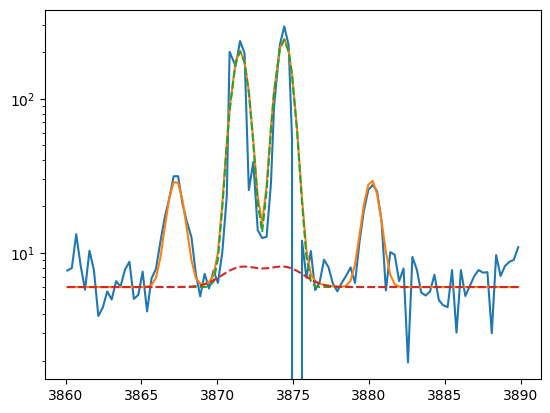

In [129]:
# Search for good initial guess

plt.plot(oii_3727.wavelength, oii_3727.flux)

h13 = gaussian(oii_3727.wavelength, 0.3e2, wave_cat['H13'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_3729))

oiic_nar = gaussian(oii_3727.wavelength, 3.0e2, wave_cat['[OII]3729'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_3729))
oiic_brd = gaussian(oii_3727.wavelength, 0.6e1, wave_cat['[OII]3729'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_3729))

oiid_nar = gaussian(oii_3727.wavelength, 2.5e2, wave_cat['[OII]3726'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_3729))
oiid_brd = gaussian(oii_3727.wavelength, 0.6e1, wave_cat['[OII]3726'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_3729))

h14 = gaussian(oii_3727.wavelength, 0.3e2, wave_cat['H14'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_3729))

oiic = oiic_nar + oiic_brd
oiid = oiid_nar + oiid_brd

bkg = 6

plt.plot(oii_3727.wavelength, bkg + oiid + oiic + h13 + h14)
plt.plot(oii_3727.wavelength, bkg + oiid_nar + oiic_nar, ls='--')
plt.plot(oii_3727.wavelength, bkg + oiid_brd + oiic_brd, ls='--')

plt.yscale('log')

In [130]:
params_oii_3727 = Parameters()

params_oii_3727.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oii_3727.add('z_ratio', value=z_ratio, vary=False)
params_oii_3727.add('sigma_nar', value=upy.nominal_values(sigma_nar_3729), vary=False)
params_oii_3727.add('sigma_brd', value=upy.nominal_values(sigma_brd_3729), vary=False)
params_oii_3727.add('H13', value=0.3e2, min=0.)
params_oii_3727.add('Oiic_nar', value=2.0e2, min=0.)
params_oii_3727.add('Oiic_brd', value=0., vary=False)
params_oii_3727.add('Oiid_nar', value=1.4e2, min=0.)
params_oii_3727.add('Oiid_brd', value=0., vary=False)
params_oii_3727.add('H14', value=0.3e2, min=0.)
params_oii_3727.add('bkg', value=6, min=0.)

def residual_oii_3727(params_oii_3727, x, data, uncertainty):
    
    z_nar = params_oii_3727['z_nar']
    z_brd = params_oii_3727['z_nar'] * params_oii_3727['z_ratio']
    sigma_nar = params_oii_3727['sigma_nar']
    sigma_brd = params_oii_3727['sigma_brd']
    
    h13_flux = params_oii_3727['H13']
    oiic_nar_flux = params_oii_3727['Oiic_nar']
    oiic_brd_flux = params_oii_3727['Oiic_brd']
    oiid_nar_flux = params_oii_3727['Oiid_nar']
    oiid_brd_flux = params_oii_3727['Oiid_brd']
    h14_flux = params_oii_3727['H14']
    bkg = params_oii_3727['bkg']
    
    x = oii_3727.wavelength
    model_h13 = gaussian(x, h13_flux, wave_cat['H13'], z_nar, sigma_nar)
    model_oiic = gaussian(x, oiic_nar_flux, wave_cat['[OII]3729'], z_nar, sigma_nar) + \
                 gaussian(x, oiic_brd_flux, wave_cat['[OII]3729'], z_brd, sigma_brd)
    model_oiid = gaussian(x, oiid_nar_flux, wave_cat['[OII]3726'], z_nar, sigma_nar) + \
                 gaussian(x, oiid_brd_flux, wave_cat['[OII]3726'], z_brd, sigma_brd)
    model_h14 = gaussian(x, h14_flux, wave_cat['H14'], z_nar, sigma_nar)
    model = model_h13 + model_oiic + model_oiid + model_h14
    return (model + bkg - oii_3727.flux) / oii_3727.noise

In [131]:
np.random.seed(1444)
out_oii_3727 = minimize(residual_oii_3727, params_oii_3727, args=(1, 1, 1),
                         method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|███████████████████████████████████████| 2500/2500 [00:30<00:00, 81.82it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 6 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 50.42444323  58.51888353  62.53433833 103.06776651  68.51893992
  52.04266072]


In [132]:
out_oii_3727.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03905598,1.6649e-06,(0.00%),0.039041570755652975,-inf,inf,True
z_ratio,1.00046454,,,1.0004645413076385,-inf,inf,False
sigma_nar,0.50867110,,,0.5086710962059176,-inf,inf,False
sigma_brd,1.18180958,,,1.1818095807985216,-inf,inf,False
H13,28.1639691,1.76483203,(6.27%),30.0,0.00000000,inf,True
Oiic_nar,336.078913,4.27547341,(1.27%),200.0,0.00000000,inf,True
Oiic_brd,0.00000000,,,0.0,-inf,inf,False
Oiid_nar,258.788552,4.15471601,(1.61%),140.0,0.00000000,inf,True
Oiid_brd,0.00000000,,,0.0,-inf,inf,False
H14,33.2693478,1.94227215,(5.84%),30.0,0.00000000,inf,True


In [133]:
np.random.seed(1444)
out2_oii_3727 = minimize(residual_oii_3727, out_oii_3727.params, args=(1, 1, 1),
                         method='leastsq')

In [134]:
out2_oii_3727.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03905591,4.0975e-06,(0.01%),0.03905597857907844,-inf,inf,True
z_ratio,1.00046454,0.00000000,(0.00%),1.0004645413076385,-inf,inf,False
sigma_nar,0.50867110,0.00000000,(0.00%),0.5086710962059176,-inf,inf,False
sigma_brd,1.18180958,0.00000000,(0.00%),1.1818095807985216,-inf,inf,False
H13,28.1825327,3.69531443,(13.11%),28.163969148329393,0.00000000,inf,True
Oiic_nar,336.078489,9.06162315,(2.70%),336.07891327788144,0.00000000,inf,True
Oiic_brd,0.00000000,0.00000000,,0.0,-inf,inf,False
Oiid_nar,258.694848,8.93045340,(3.45%),258.7885520582049,0.00000000,inf,True
Oiid_brd,0.00000000,0.00000000,,0.0,-inf,inf,False
H14,33.2735411,3.97159811,(11.94%),33.26934782405543,0.00000000,inf,True


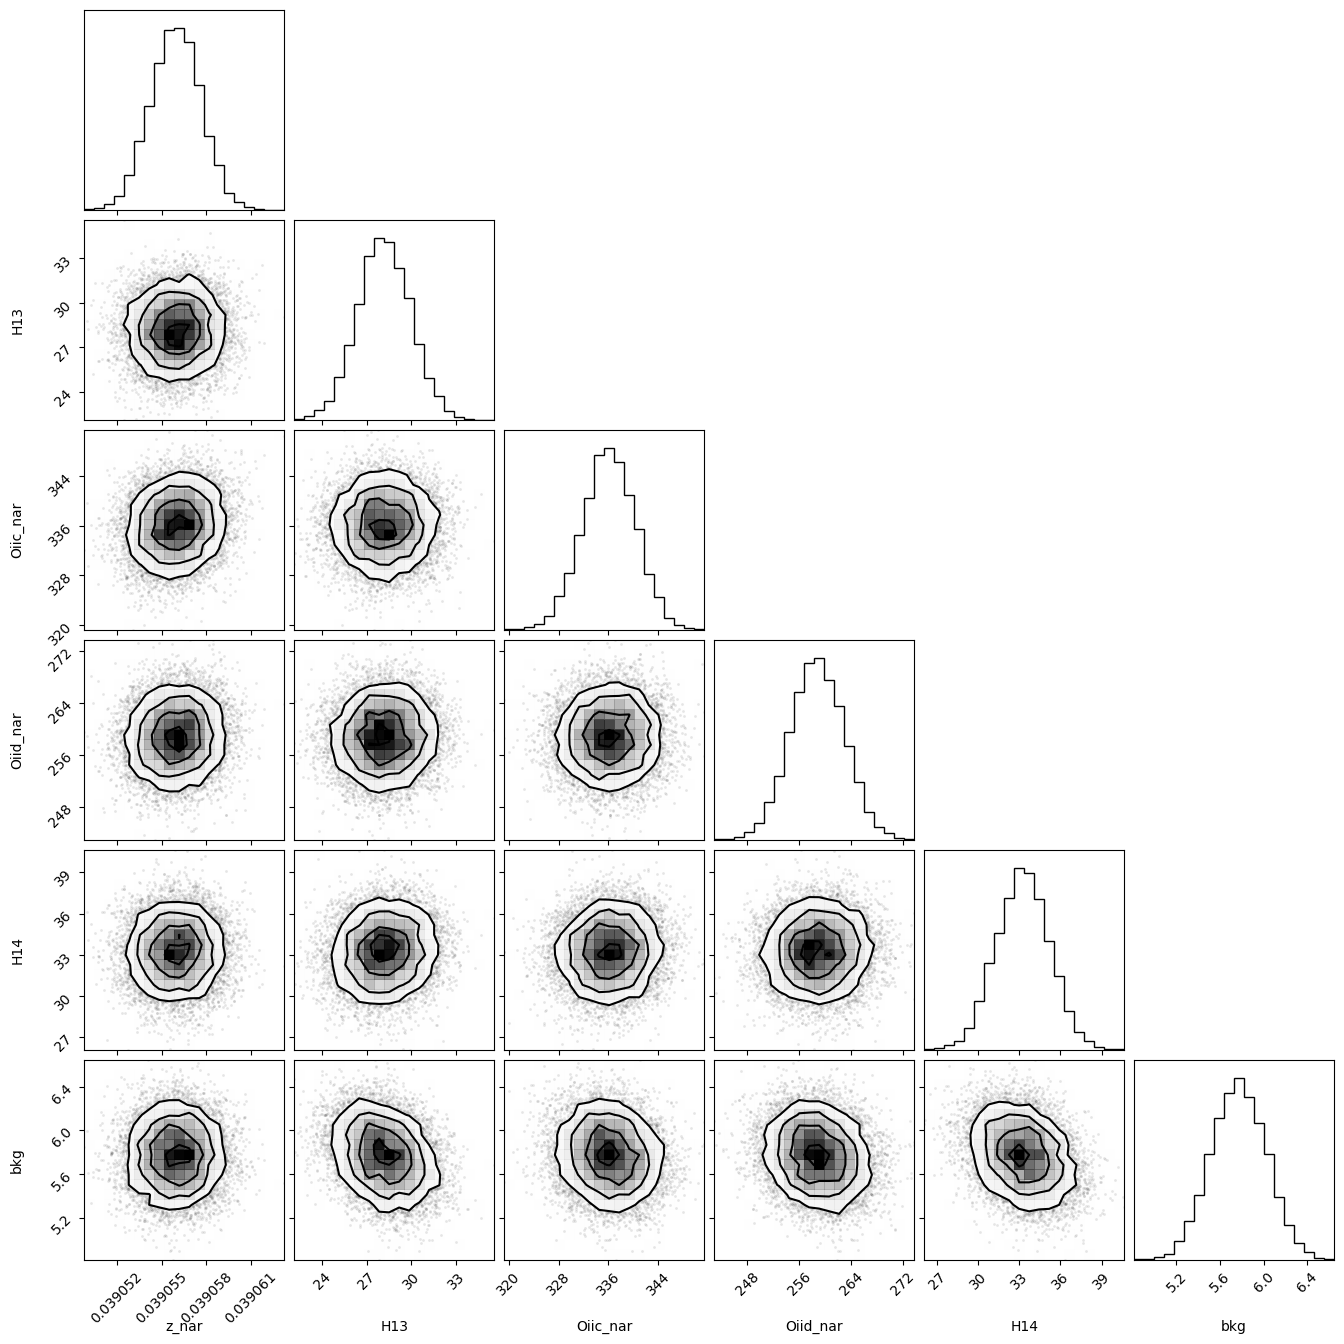

In [135]:
corner.corner(out_oii_3727.flatchain, labels=out_oii_3727.var_names);

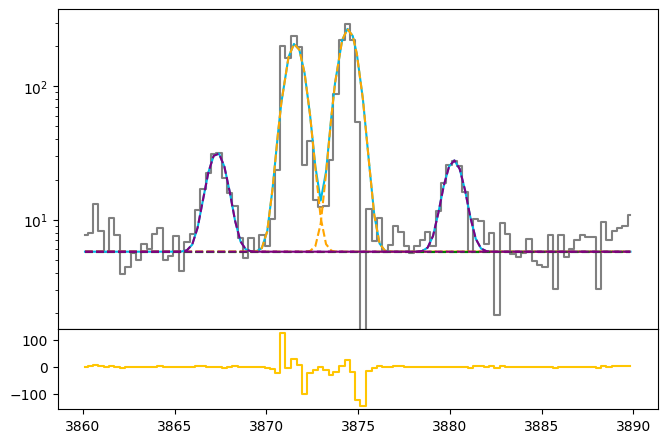

In [136]:
h13_flux = out2_oii_3727.params['H13'].value
h13_std = out2_oii_3727.params['H13'].stderr

oiic_nar_flux = out2_oii_3727.params['Oiic_nar'].value
oiic_nar_std = out2_oii_3727.params['Oiic_nar'].stderr

oiic_brd_flux = out2_oii_3727.params['Oiic_brd'].value
oiic_brd_std = out2_oii_3727.params['Oiic_brd'].stderr

oiid_nar_flux = out2_oii_3727.params['Oiid_nar'].value
oiid_nar_std = out2_oii_3727.params['Oiid_nar'].stderr

oiid_brd_flux = out2_oii_3727.params['Oiid_brd'].value
oiid_brd_std = out2_oii_3727.params['Oiid_brd'].stderr

h14_flux = out2_oii_3727.params['H14'].value
h14_std = out2_oii_3727.params['H14'].stderr

z_oii_3727 = out2_oii_3727.params['z_nar'].value
z_oii_3727_std = out2_oii_3727.params['z_nar'].stderr

bkg_oii_3727 = out2_oii_3727.params['bkg'].value
bkg_oii_3727_std = out2_oii_3727.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oii_3727.wavelength, oii_3727.flux, color='gray', label='Data', where='mid')

h13 = gaussian(oii_3727.wavelength, h13_flux, wave_cat['H13'], z_oii_3727, upy.nominal_values(sigma_nar_3729))

oiic_nar = gaussian(oii_3727.wavelength, oiic_nar_flux, wave_cat['[OII]3729'], z_oii_3727, upy.nominal_values(sigma_nar_3729))
oiic_brd = gaussian(oii_3727.wavelength, oiic_brd_flux, wave_cat['[OII]3729'], z_oii_3727 * z_ratio, upy.nominal_values(sigma_brd_3729))

oiid_nar = gaussian(oii_3727.wavelength, oiid_nar_flux, wave_cat['[OII]3726'], z_oii_3727, upy.nominal_values(sigma_nar_3729))
oiid_brd = gaussian(oii_3727.wavelength, oiid_brd_flux, wave_cat['[OII]3726'], z_oii_3727 * z_ratio, upy.nominal_values(sigma_brd_3729))

h14 = gaussian(oii_3727.wavelength, h14_flux, wave_cat['H14'], z_oii_3727, upy.nominal_values(sigma_nar_3729))

oiic = oiic_nar + oiic_brd
oiid = oiid_nar + oiid_brd

ax.plot(oii_3727.wavelength, bkg_oii_3727 + h13 + oiic + oiid + h14, color=c[0])
ax.plot(oii_3727.wavelength, bkg_oii_3727 + oiic_nar, ls='--', color='orange')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + oiid_nar, ls='--', color='orange')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + oiic_brd, ls='--', color='green')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + oiid_brd, ls='--', color='green')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + h13, ls='--', color='purple')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + h14, ls='--', color='purple')

ax.set_yscale('log')
ax1.step(oii_3727.wavelength, oii_3727.flux - bkg_oii_3727 - oiic - oiid - h13 - h14,
         color=c[3], where='mid')

In [137]:
# EW
EW_OII_3729_nar = ufloat(oiic_nar_flux, oiic_nar_std) / ufloat(bkg_oii_3727, bkg_oii_3727_std)
EW_OII_3729_brd = ufloat(oiic_brd_flux, oiic_brd_std) / ufloat(bkg_oii_3727, bkg_oii_3727_std)
EW_OII_3729 = (ufloat(oiic_nar_flux, oiic_nar_std) + ufloat(oiic_brd_flux, oiic_brd_std)) / ufloat(bkg_oii_3727, bkg_oii_3727_std)

EW_OII_3726_nar = ufloat(oiid_nar_flux, oiid_nar_std) / ufloat(bkg_oii_3727, bkg_oii_3727_std)
EW_OII_3726_brd = ufloat(oiid_brd_flux, oiid_brd_std) / ufloat(bkg_oii_3727, bkg_oii_3727_std)
EW_OII_3726 = (ufloat(oiid_nar_flux, oiid_nar_std) + ufloat(oiid_brd_flux, oiid_brd_std)) / ufloat(bkg_oii_3727, bkg_oii_3727_std)

# [SIII]9532

In [138]:
sigma_arc_9532 = (m * wave_cat['[SIII]9532']*(1 + z_BN[igal])) + n

sigma_nar_9532 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_9532**2))
sigma_brd_9532 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_9532**2))

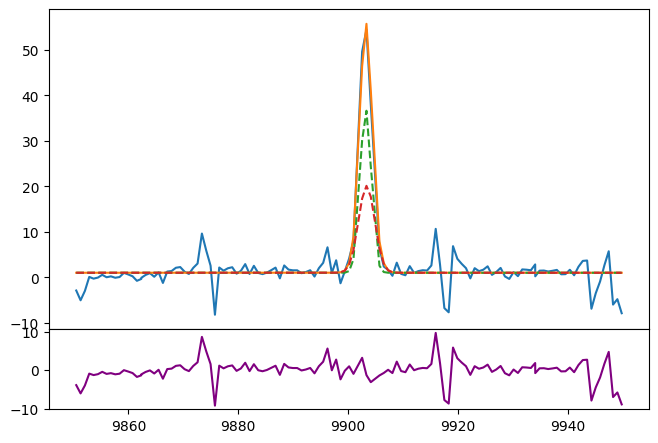

In [139]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(siii_9532.wavelength, siii_9532.flux)
bkg = 1

siiia_nar = gaussian(siii_9532.wavelength, 9e1, wave_cat['[SIII]9532'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_9532))
siiia_brd = gaussian(siii_9532.wavelength, 7e1, wave_cat['[SIII]9532'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_9532))

ax.plot(siii_9532.wavelength, bkg + siiia_nar + siiia_brd)
ax.plot(siii_9532.wavelength, bkg + siiia_nar, ls='--')
ax.plot(siii_9532.wavelength, bkg + siiia_brd, ls='--')
ax1.plot(siii_9532.wavelength, siii_9532.flux - bkg - siiia_nar - siiia_brd, color='purple')
#ax.set_yscale('log')

In [140]:
params_siiia = Parameters()
params_siiia.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_siiia.add('z_ratio', value=z_ratio, vary=False)
params_siiia.add('sigma_nar', value=upy.nominal_values(sigma_nar_9532), vary=False)
params_siiia.add('sigma_brd', value=upy.nominal_values(sigma_brd_9532), vary=False)
params_siiia.add('Siiia_nar', value=9e1, min=0.)
params_siiia.add('Siiia_brd', value=7e1, min=0.)
params_siiia.add('bkg', value=1, min=0.)


def residual_siiia(params_siiia, x, data, uncertainty):
    
    z_nar = params_siiia['z_nar']
    z_brd = params_siiia['z_nar'] * params_siiia['z_ratio']
    sigma_nar = params_siiia['sigma_nar']
    sigma_brd = params_siiia['sigma_brd']
    siiia_nar_flux = params_siiia['Siiia_nar']
    siiia_brd_flux = params_siiia['Siiia_brd']
    bkg = params_siiia['bkg']
    
    x = siii_9532.wavelength
    model = gaussian(x, siiia_nar_flux, wave_cat['[SIII]9532'], z_nar, sigma_nar) + \
            gaussian(x, siiia_brd_flux, wave_cat['[SIII]9532'], z_brd, sigma_brd)
    
    return (model + bkg - siii_9532.flux) / siii_9532.noise

In [141]:
np.random.seed(1444)
out_siiia = minimize(residual_siiia, params_siiia, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:18<00:00, 131.68it/s]


In [142]:
out_siiia.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03903372,3.3906e-06,(0.01%),0.039041570755652975,-inf,inf,True
z_ratio,1.00046454,,,1.0004645413076385,-inf,inf,False
sigma_nar,0.99846844,,,0.99846844063587,-inf,inf,False
sigma_brd,1.46111835,,,1.4611183484227668,-inf,inf,False
Siiia_nar,103.152581,8.22027823,(7.97%),90.0,0.00000000,inf,True
Siiia_brd,51.4224183,10.0528758,(19.55%),70.0,0.00000000,inf,True
bkg,1.05611233,0.07546220,(7.15%),1,0.00000000,inf,True


In [143]:
np.random.seed(1444)
out2_siiia = minimize(residual_siiia, out_siiia.params, args=(1, 1, 1),
                      method='leastsq')

In [144]:
out2_siiia.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03903371,5.5777e-06,(0.01%),0.03903372164149041,-inf,inf,True
z_ratio,1.00046454,0.00000000,(0.00%),1.0004645413076385,-inf,inf,False
sigma_nar,0.99846844,0.00000000,(0.00%),0.99846844063587,-inf,inf,False
sigma_brd,1.46111835,0.00000000,(0.00%),1.4611183484227668,-inf,inf,False
Siiia_nar,103.177165,13.4790809,(13.06%),103.15258128187449,0.00000000,inf,True
Siiia_brd,51.4237119,16.3249073,(31.75%),51.422418333692676,0.00000000,inf,True
bkg,1.05667132,0.12168937,(11.52%),1.0561123338288718,0.00000000,inf,True


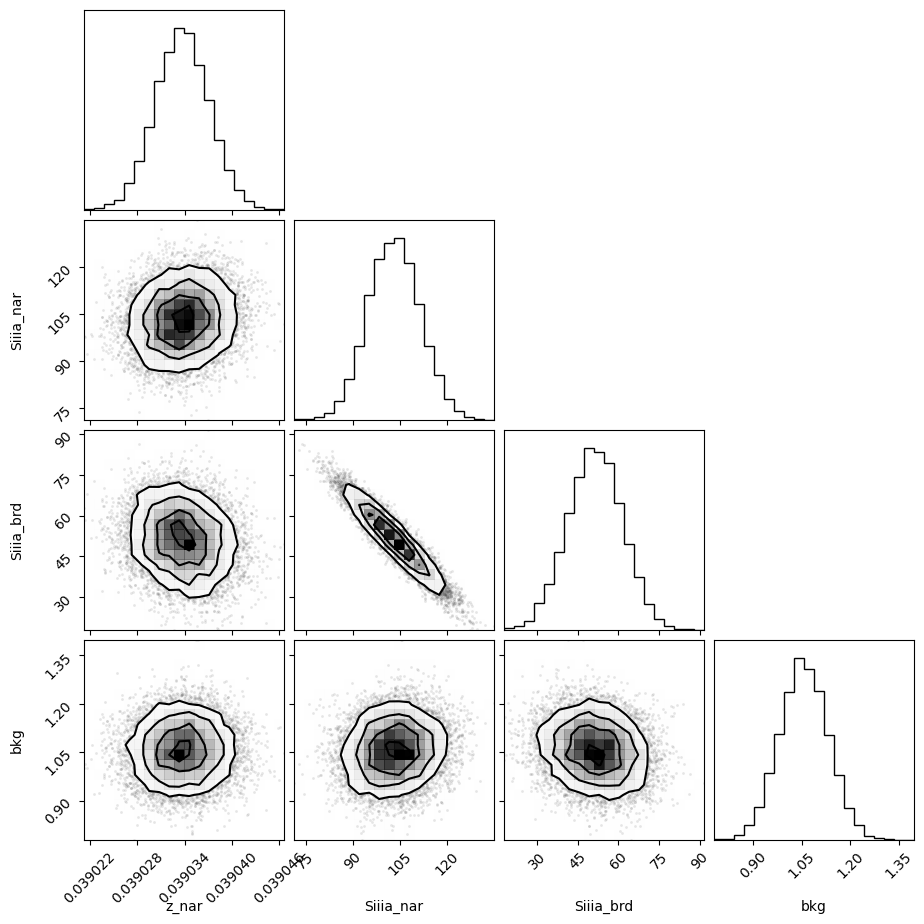

In [145]:
corner.corner(out_siiia.flatchain, labels=out_siiia.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

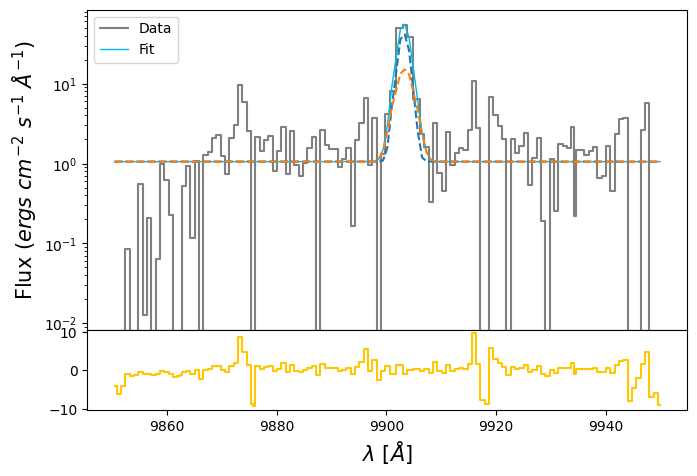

In [146]:
siiia_nar_flux = out2_siiia.params['Siiia_nar'].value
siiia_nar_std = out2_siiia.params['Siiia_nar'].stderr

siiia_brd_flux = out2_siiia.params['Siiia_brd'].value
siiia_brd_std = out2_siiia.params['Siiia_brd'].stderr

z_siiia = out2_siiia.params['z_nar'].value
z_siiia_std = out2_siiia.params['z_nar'].stderr

bkg_siiia = out2_siiia.params['bkg'].value
bkg_siiia_std = out2_siiia.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(siii_9532.wavelength, siii_9532.flux,
            color='gray', label='Data', where='mid')

siiia_nar = gaussian(siii_9532.wavelength, siiia_nar_flux, wave_cat['[SIII]9532'], z_siiia, upy.nominal_values(sigma_nar_9532))
siiia_brd = gaussian(siii_9532.wavelength, siiia_brd_flux, wave_cat['[SIII]9532'], z_siiia * z_ratio, upy.nominal_values(sigma_brd_9532))
siiia = siiia_nar + siiia_brd

ax.plot(siii_9532.wavelength, bkg_siiia + siiia, lw=1, color=c[0], label='Fit')
ax.plot(siii_9532.wavelength, bkg_siiia + siiia_nar, ls='--')
ax.plot(siii_9532.wavelength, bkg_siiia + siiia_brd, ls='--')
ax1.step(siii_9532.wavelength, siii_9532.flux - bkg_siiia - siiia, color=c[3], where='mid')
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [147]:
# EW
EW_SIII_9532_nar = (ufloat(siiia_nar_flux, siiia_nar_std) + ufloat(siiia_brd_flux, siiia_brd_std)) / ufloat(bkg_siiia, bkg_siiia_std)
EW_SIII_9532_brd = (ufloat(siiia_nar_flux, siiia_nar_std) + ufloat(siiia_brd_flux, siiia_brd_std)) / ufloat(bkg_siiia, bkg_siiia_std)
EW_SIII_9532 = (ufloat(siiia_nar_flux, siiia_nar_std) + ufloat(siiia_brd_flux, siiia_brd_std)) / ufloat(bkg_siiia, bkg_siiia_std)

# [SIII]9069

In [148]:
sigma_arc_9069 = (m * wave_cat['[SIII]9069']*(1 + z_BN[igal])) + n

sigma_nar_9069 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_9069**2))
sigma_brd_9069 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_9069**2))

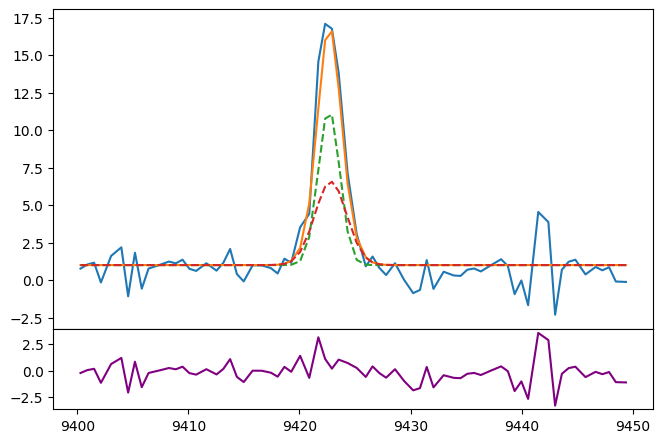

In [149]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(siii_9069.wavelength, siii_9069.flux)
bkg = 1

siiib_nar = gaussian(siii_9069.wavelength, 2.5e1, wave_cat['[SIII]9069'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_9069))
siiib_brd = gaussian(siii_9069.wavelength, 2e1, wave_cat['[SIII]9069'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_9069))

ax.plot(siii_9069.wavelength, bkg + siiib_nar + siiib_brd)
ax.plot(siii_9069.wavelength, bkg + siiib_nar, ls='--')
ax.plot(siii_9069.wavelength, bkg + siiib_brd, ls='--')
ax1.plot(siii_9069.wavelength, siii_9069.flux - bkg - siiib_nar - siiib_brd, color='purple')
#ax.set_yscale('log')

In [150]:
params_siiib = Parameters()
params_siiib.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_siiib.add('z_ratio', value=z_ratio, vary=False)
params_siiib.add('sigma_nar', value=upy.nominal_values(sigma_nar_9532), vary=False)
params_siiib.add('sigma_brd', value=upy.nominal_values(sigma_brd_9532), vary=False)
params_siiib.add('Siiib_nar', value=2.5e1, min=0.)
params_siiib.add('Siiib_brd', value=2.0e1, min=0.)
params_siiib.add('bkg', value=1, min=0.)


def residual_siiib(params_siiib, x, data, uncertainty):
    
    z_nar = params_siiib['z_nar']
    z_brd = params_siiib['z_nar'] * params_siiib['z_ratio']
    sigma_nar = params_siiib['sigma_nar']
    sigma_brd = params_siiib['sigma_brd']
    siiib_nar_flux = params_siiib['Siiib_nar']
    siiib_brd_flux = params_siiib['Siiib_brd']
    bkg = params_siiib['bkg']
    
    x = siii_9069.wavelength
    model = gaussian(x, siiib_nar_flux, wave_cat['[SIII]9069'], z_nar, sigma_nar) + \
            gaussian(x, siiib_brd_flux, wave_cat['[SIII]9069'], z_brd, sigma_brd)
    
    return (model + bkg - siii_9069.flux) / siii_9069.noise

In [151]:
np.random.seed(1444)
out_siiib = minimize(residual_siiib, params_siiib, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:18<00:00, 138.16it/s]


In [152]:
out_siiib.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03903515,8.7651e-06,(0.02%),0.039041570755652975,-inf,inf,True
z_ratio,1.00046454,,,1.0004645413076385,-inf,inf,False
sigma_nar,0.99846844,,,0.99846844063587,-inf,inf,False
sigma_brd,1.46111835,,,1.4611183484227668,-inf,inf,False
Siiib_nar,23.3820022,6.35043754,(27.16%),25.0,0.00000000,inf,True
Siiib_brd,28.1979202,7.29066515,(25.86%),20.0,0.00000000,inf,True
bkg,0.72646621,0.07891959,(10.86%),1,0.00000000,inf,True


In [153]:
np.random.seed(1444)
out2_siiib = minimize(residual_siiib, out_siiib.params, args=(1, 1, 1),
                      method='leastsq')

In [154]:
out2_siiib.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03903510,8.4307e-06,(0.02%),0.03903515248188852,-inf,inf,True
z_ratio,1.00046454,0.00000000,(0.00%),1.0004645413076385,-inf,inf,False
sigma_nar,0.99846844,0.00000000,(0.00%),0.99846844063587,-inf,inf,False
sigma_brd,1.46111835,0.00000000,(0.00%),1.4611183484227668,-inf,inf,False
Siiib_nar,23.6368489,6.07751835,(25.71%),23.382002164921907,0.00000000,inf,True
Siiib_brd,28.1286410,7.05285843,(25.07%),28.197920216202625,0.00000000,inf,True
bkg,0.72627264,0.07737819,(10.65%),0.726466212901953,0.00000000,inf,True


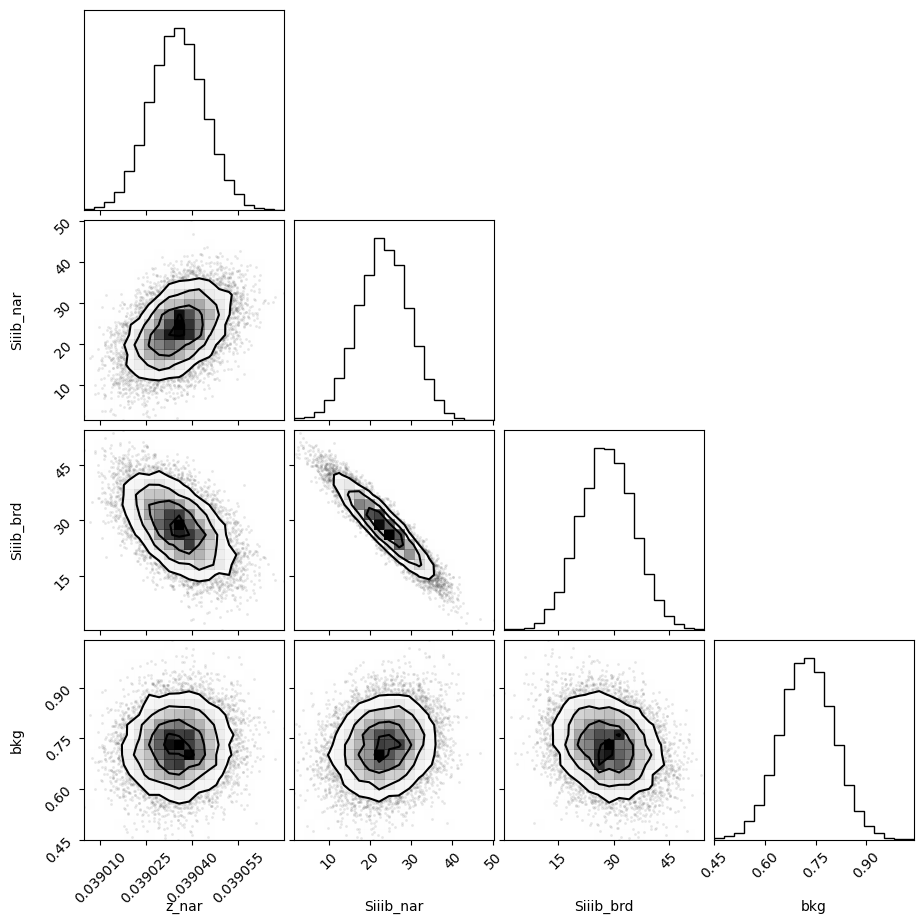

In [155]:
corner.corner(out_siiib.flatchain, labels=out_siiib.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

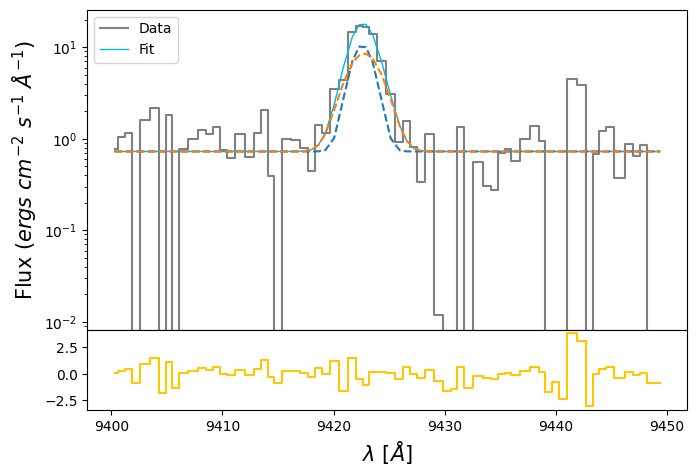

In [156]:
siiib_nar_flux = out2_siiib.params['Siiib_nar'].value
siiib_nar_std = out2_siiib.params['Siiib_nar'].stderr

siiib_brd_flux = out2_siiib.params['Siiib_brd'].value
siiib_brd_std = out2_siiib.params['Siiib_brd'].stderr

z_siiib = out2_siiib.params['z_nar'].value
z_siiib_std = out2_siiib.params['z_nar'].stderr

bkg_siiib = out2_siiib.params['bkg'].value
bkg_siiib_std = out2_siiib.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(siii_9069.wavelength, siii_9069.flux,
            color='gray', label='Data', where='mid')

siiib_nar = gaussian(siii_9069.wavelength, siiib_nar_flux, wave_cat['[SIII]9069'], z_siiib, upy.nominal_values(sigma_nar_9069))
siiib_brd = gaussian(siii_9069.wavelength, siiib_brd_flux, wave_cat['[SIII]9069'], z_siiib * z_ratio, upy.nominal_values(sigma_brd_9069))
siiib = siiib_nar + siiib_brd

ax.plot(siii_9069.wavelength, bkg_siiib + siiib, lw=1, color=c[0], label='Fit')
ax.plot(siii_9069.wavelength, bkg_siiib + siiib_nar, ls='--')
ax.plot(siii_9069.wavelength, bkg_siiib + siiib_brd, ls='--')
ax1.step(siii_9069.wavelength, siii_9069.flux - bkg_siiib - siiib, color=c[3], where='mid')
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [157]:
# EW
EW_SIII_9069_nar = ufloat(siiib_nar_flux, siiib_nar_std) / ufloat(bkg_siiib, bkg_siiib_std)
EW_SIII_9069_brd = ufloat(siiib_brd_flux, siiib_brd_std) / ufloat(bkg_siiib, bkg_siiib_std)
EW_SIII_9069 = (ufloat(siiib_nar_flux, siiib_nar_std) + ufloat(siiib_brd_flux, siiib_brd_std)) / ufloat(bkg_siiib, bkg_siiib_std)

# [OI]6300 + [SIII]6312

In [158]:
sigma_arc_6312 = (m * wave_cat['[SIII]6312']*(1 + z_BN[igal])) + n

sigma_nar_6312 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_6312**2))
sigma_brd_6312 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_6312**2))

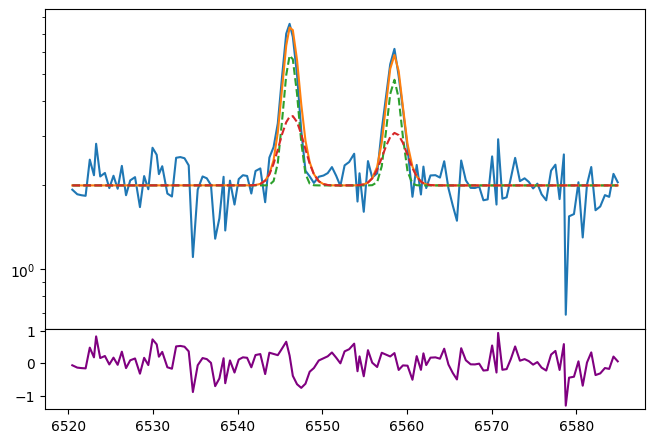

In [159]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oi_siii.wavelength, oi_siii.flux)
bkg = 2.0

oi_nar = gaussian(oi_siii.wavelength, 0.7e1, wave_cat['[OI]6300'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_6312))
oi_brd = gaussian(oi_siii.wavelength, 0.5e1, wave_cat['[OI]6300'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_6312))

siiic_nar = gaussian(oi_siii.wavelength, 0.5e1, wave_cat['[SIII]6312'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_6312))
siiic_brd = gaussian(oi_siii.wavelength, 0.35e1, wave_cat['[SIII]6312'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_6312))

ax.plot(oi_siii.wavelength, bkg + siiic_nar + siiic_brd + oi_nar + oi_brd)
ax.plot(oi_siii.wavelength, bkg + siiic_nar + oi_nar, ls='--')
ax.plot(oi_siii.wavelength, bkg + siiic_brd + oi_brd, ls='--')
ax1.plot(oi_siii.wavelength, oi_siii.flux - bkg - siiic_nar - siiic_brd - oi_nar - oi_brd, color='purple')
ax.set_yscale('log')

In [160]:
params_oi_siii = Parameters()
params_oi_siii.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oi_siii.add('z_ratio', value=z_ratio, vary=False)
params_oi_siii.add('sigma_nar', value=upy.nominal_values(sigma_nar_6312), vary=False)
params_oi_siii.add('sigma_brd', value=upy.nominal_values(sigma_brd_6312), vary=False)
params_oi_siii.add('Oi_nar', value=0.7e1, min=0.)
params_oi_siii.add('Oi_brd', value=0.5e1, min=0.)
params_oi_siii.add('Siiic_nar', value=0.5e1, min=0.)
params_oi_siii.add('Siiic_brd', value=0.35e1, min=0.)
params_oi_siii.add('bkg', value=2.0, min=0.)


def residual_oi_siii(params_oi_siii, x, data, uncertainty):
    
    z_nar = params_oi_siii['z_nar']
    z_brd = params_oi_siii['z_nar'] * params_oi_siii['z_ratio']
    sigma_nar = params_oi_siii['sigma_nar']
    sigma_brd = params_oi_siii['sigma_brd']
    oi_nar = params_oi_siii['Oi_nar']
    oi_brd = params_oi_siii['Oi_brd']
    siiic_nar = params_oi_siii['Siiic_nar']
    siiic_brd = params_oi_siii['Siiic_brd']
    bkg = params_oi_siii['bkg']
    
    x = oi_siii.wavelength
    model_oi = gaussian(x, oi_nar, wave_cat['[OI]6300'], z_nar, sigma_nar) \
             + gaussian(x, oi_brd, wave_cat['[OI]6300'], z_brd, sigma_brd)
    model_siii = gaussian(x, siiic_nar, wave_cat['[SIII]6312'], z_nar, sigma_nar) \
               + gaussian(x, siiic_brd, wave_cat['[SIII]6312'], z_brd, sigma_brd)
    
    return (model_siii + model_oi + bkg - oi_siii.flux) / oi_siii.noise

In [161]:
np.random.seed(1444)
out_oi_siii = minimize(residual_oi_siii, params_oi_siii, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|███████████████████████████████████████| 2500/2500 [00:25<00:00, 97.60it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 6 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [51.77082975 59.76870035 62.58628056 60.59316149 60.06885415 57.48593127]


In [162]:
out_oi_siii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03902027,5.1710e-06,(0.01%),0.039041570755652975,-inf,inf,True
z_ratio,1.00046454,,,1.0004645413076385,-inf,inf,False
sigma_nar,0.71584922,,,0.7158492245069544,-inf,inf,False
sigma_brd,1.28466638,,,1.284666382131585,-inf,inf,False
Oi_nar,8.53957315,0.86044713,(10.08%),7.0,0.00000000,inf,True
Oi_brd,2.58472736,1.07889525,(41.74%),5.0,0.00000000,inf,True
Siiic_nar,5.63664446,0.82156916,(14.58%),5.0,0.00000000,inf,True
Siiic_brd,2.79982118,1.09882050,(39.25%),3.5,0.00000000,inf,True
bkg,2.04555930,0.02529784,(1.24%),2.0,0.00000000,inf,True


In [163]:
np.random.seed(1444)
out2_oi_siii = minimize(residual_oi_siii, out_oi_siii.params, args=(1, 1, 1),
                      method='leastsq')

In [164]:
out2_oi_siii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03902016,5.5277e-06,(0.01%),0.03902026949190568,-inf,inf,True
z_ratio,1.00046454,0.00000000,(0.00%),1.0004645413076385,-inf,inf,False
sigma_nar,0.71584922,0.00000000,(0.00%),0.7158492245069544,-inf,inf,False
sigma_brd,1.28466638,0.00000000,(0.00%),1.284666382131585,-inf,inf,False
Oi_nar,8.59844081,0.98392899,(11.44%),8.539573154173013,0.00000000,inf,True
Oi_brd,2.52253374,1.25420419,(49.72%),2.5847273621420874,0.00000000,inf,True
Siiic_nar,5.62765614,0.91374698,(16.24%),5.636644460375214,0.00000000,inf,True
Siiic_brd,2.81475793,1.20469242,(42.80%),2.799821181025983,0.00000000,inf,True
bkg,2.04540877,0.02848722,(1.39%),2.045559301778768,0.00000000,inf,True


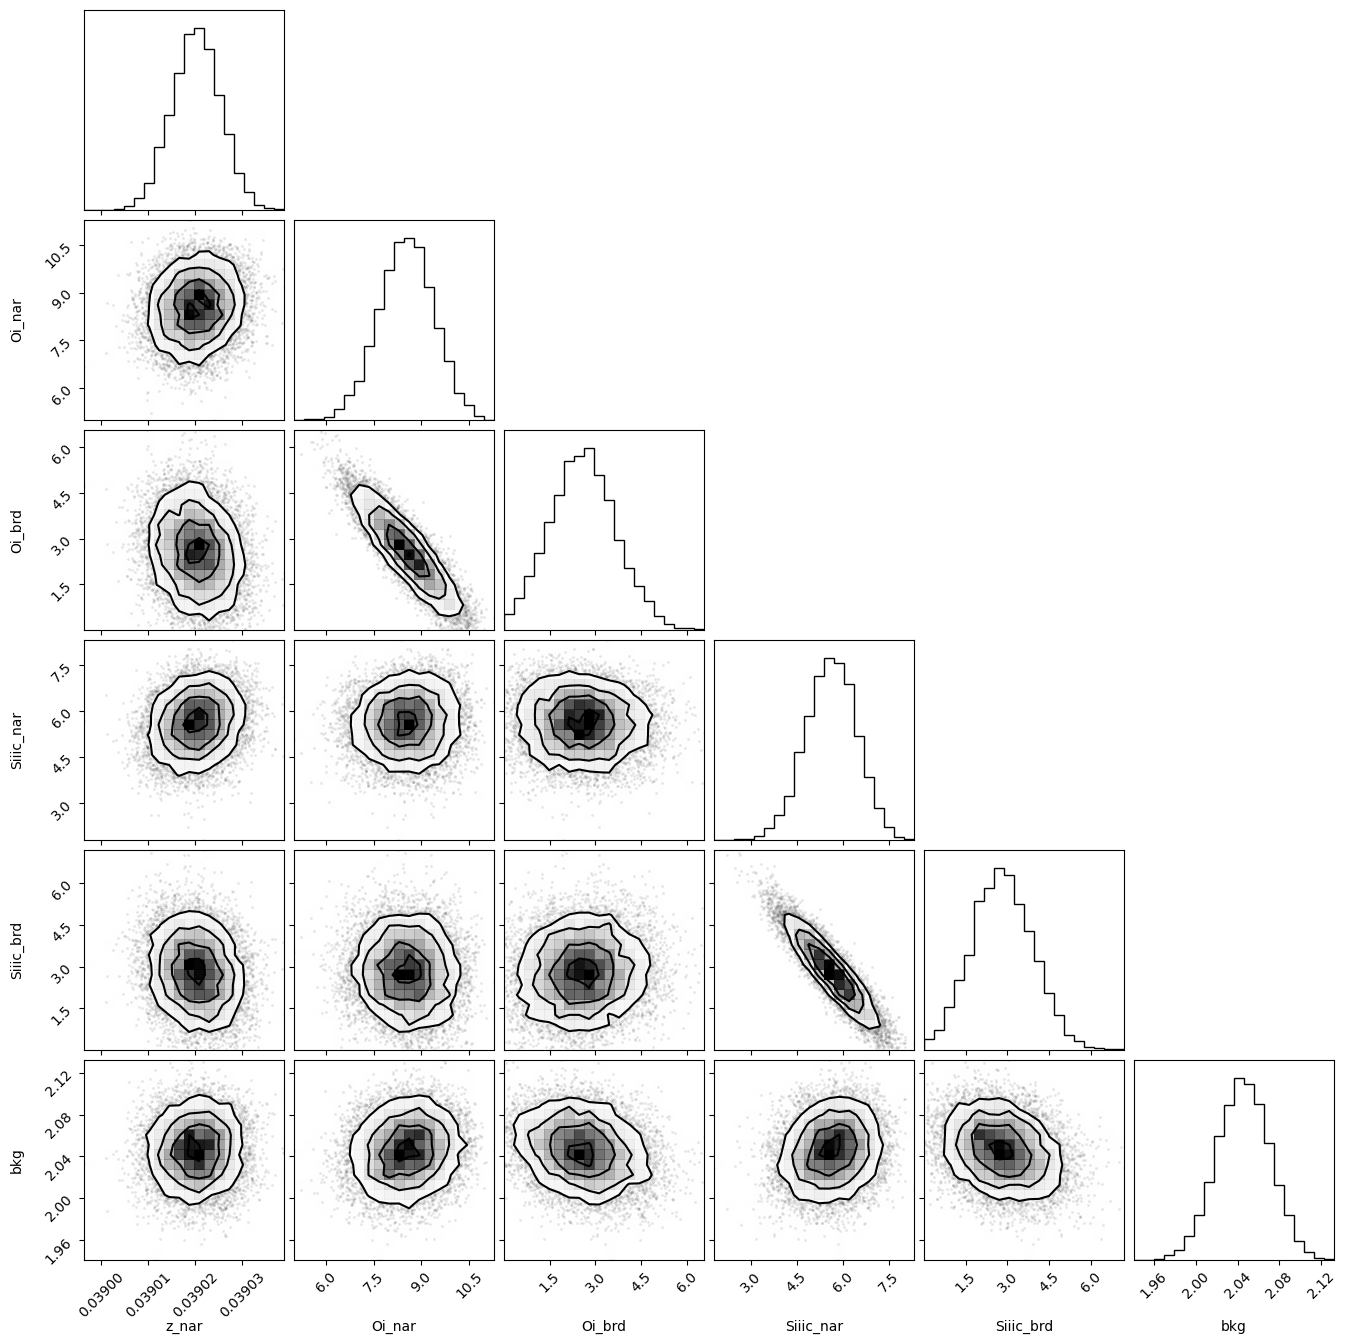

In [165]:
corner.corner(out_oi_siii.flatchain, labels=out_oi_siii.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

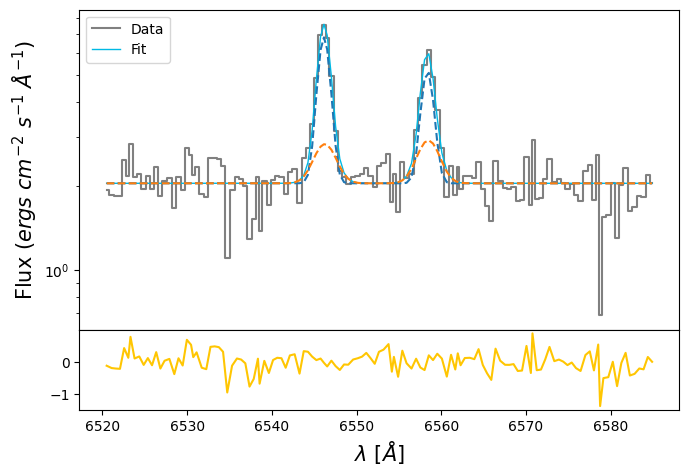

In [166]:
oia_nar_flux = out2_oi_siii.params['Oi_nar'].value
oia_nar_std = out2_oi_siii.params['Oi_nar'].stderr

oia_brd_flux = out2_oi_siii.params['Oi_brd'].value
oia_brd_std = out2_oi_siii.params['Oi_brd'].stderr

siiic_nar_flux = out2_oi_siii.params['Siiic_nar'].value
siiic_nar_std = out2_oi_siii.params['Siiic_nar'].stderr

siiic_brd_flux = out2_oi_siii.params['Siiic_brd'].value
siiic_brd_std = out2_oi_siii.params['Siiic_brd'].stderr

z_oi_siii = out2_oi_siii.params['z_nar'].value
z_oi_siii_std = out2_oi_siii.params['z_nar'].stderr

bkg_oi_siii = out2_oi_siii.params['bkg'].value
bkg_oi_siii_std = out2_oi_siii.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oi_siii.wavelength, oi_siii.flux,
            color='gray', label='Data', where='mid')

oia_nar = gaussian(oi_siii.wavelength, oia_nar_flux, wave_cat['[OI]6300'], z_oi_siii, upy.nominal_values(sigma_nar_6312))
oia_brd = gaussian(oi_siii.wavelength, oia_brd_flux, wave_cat['[OI]6300'], z_oi_siii * z_ratio, upy.nominal_values(sigma_brd_6312))

siiic_nar = gaussian(oi_siii.wavelength, siiic_nar_flux, wave_cat['[SIII]6312'], z_oi_siii, upy.nominal_values(sigma_nar_6312))
siiic_brd = gaussian(oi_siii.wavelength, siiic_brd_flux, wave_cat['[SIII]6312'], z_oi_siii * z_ratio, upy.nominal_values(sigma_brd_6312))

oia = oia_nar + oia_brd
siiic = siiic_nar + siiic_brd

ax.plot(oi_siii.wavelength, bkg_oi_siii + siiic + oia,
        lw=1, color=c[0], label='Fit')
ax.plot(oi_siii.wavelength, bkg_oi_siii + siiic_nar + oia_nar, ls='--')
ax.plot(oi_siii.wavelength, bkg_oi_siii + siiic_brd + oia_brd, ls='--')

ax1.plot(oi_siii.wavelength, oi_siii.flux - bkg_oi_siii - siiic - oia,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [167]:
# EW
EW_OI_6300_nar = ufloat(oia_nar_flux, oia_nar_std) / ufloat(bkg_oi_siii, bkg_oi_siii_std)
EW_OI_6300_brd = ufloat(oia_brd_flux, oia_brd_std) / ufloat(bkg_oi_siii, bkg_oi_siii_std)
EW_OI_6300 = (ufloat(oia_nar_flux, oia_nar_std) + ufloat(oia_brd_flux, oia_brd_std)) / ufloat(bkg_oi_siii, bkg_oi_siii_std)

EW_SIII_6312_nar = ufloat(siiic_nar_flux, siiic_nar_std) / ufloat(bkg_oi_siii, bkg_oi_siii_std)
EW_SIII_6312_brd = ufloat(siiic_brd_flux, siiic_brd_std) / ufloat(bkg_oi_siii, bkg_oi_siii_std)
EW_SIII_6312 = (ufloat(siiic_nar_flux, siiic_nar_std) + ufloat(siiic_brd_flux, siiic_brd_std)) / ufloat(bkg_oi_siii, bkg_oi_siii_std)

# [OIII]5007 + HeI 5015

In [168]:
sigma_arc_5007 = (m * wave_cat['[OIII]5007']*(1 + z_BN[igal])) + n

sigma_nar_5007 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_5007**2))
sigma_brd_5007 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_5007**2))

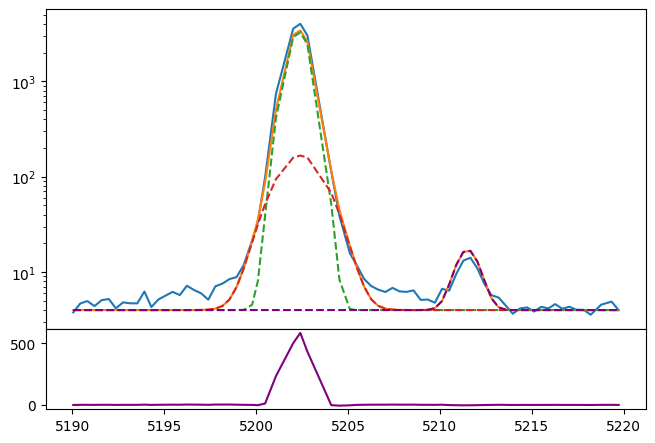

In [169]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oiii_hei.wavelength, oiii_hei.flux)
bkg = 4

oiiia_nar = gaussian(oiii_hei.wavelength, 5e3, wave_cat['[OIII]5007'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_5007))
oiiia_brd = gaussian(oiii_hei.wavelength, 5e2, wave_cat['[OIII]5007'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_5007))

hei_5015 = gaussian(oiii_hei.wavelength, 2e1, wave_cat['HeI5015'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_5007))

ax.plot(oiii_hei.wavelength, bkg + oiiia_nar + oiiia_brd + hei_5015)
ax.plot(oiii_hei.wavelength, bkg + oiiia_nar, ls='--')
ax.plot(oiii_hei.wavelength, bkg + oiiia_brd, ls='--')
ax.plot(oiii_hei.wavelength, bkg + hei_5015, ls='--', color='purple')
ax1.plot(oiii_hei.wavelength, oiii_hei.flux - bkg - oiiia_nar - oiiia_brd - hei_5015, color='purple')
ax.set_yscale('log')

In [170]:
params_oiii_hei = Parameters()
params_oiii_hei.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oiii_hei.add('z_ratio', value=z_ratio, vary=False)
params_oiii_hei.add('sigma_nar', value=upy.nominal_values(sigma_nar_5007), vary=False)
params_oiii_hei.add('sigma_brd', value=upy.nominal_values(sigma_brd_5007), vary=False)
params_oiii_hei.add('Hei', value=2e1, min=0.)
params_oiii_hei.add('Oiiia_nar', value=5.0e3, min=0.)
params_oiii_hei.add('Oiiia_brd', value=5.0e2, min=0.)
params_oiii_hei.add('bkg', value=4, min=0.)


def residual_oiii_hei(params_oiii_hei, x, data, uncertainty):
    
    z_nar = params_oiii_hei['z_nar']
    z_brd = params_oiii_hei['z_nar'] * params_oiii_hei['z_ratio']
    sigma_nar = params_oiii_hei['sigma_nar']
    sigma_brd = params_oiii_hei['sigma_brd']
    oiiia_nar = params_oiii_hei['Oiiia_nar']
    oiiia_brd = params_oiii_hei['Oiiia_brd']
    hei = params_oiii_hei['Hei']
    bkg = params_oiii_hei['bkg']
    
    x = oiii_hei.wavelength
    model_oiii = gaussian(x, oiiia_nar, wave_cat['[OIII]5007'], z_nar, sigma_nar) \
               + gaussian(x, oiiia_brd, wave_cat['[OIII]5007'], z_brd, sigma_brd)
    model_hei = gaussian(x, hei, wave_cat['HeI5015'], z_nar, sigma_nar)
    
    return (model_oiii + model_hei + bkg - oiii_hei.flux) / oiii_hei.noise

In [171]:
np.random.seed(1444)
out_oiii_hei = minimize(residual_oiii_hei, params_oiii_hei, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:21<00:00, 116.74it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 5 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 62.9287564  132.01673532  69.61840342  72.15947566 102.17927804]


In [172]:
out_oiii_hei.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03904038,4.6387e-07,(0.00%),0.039041570755652975,-inf,inf,True
z_ratio,1.00046454,,,1.0004645413076385,-inf,inf,False
sigma_nar,0.60763598,,,0.6076359755001506,-inf,inf,False
sigma_brd,1.22766000,,,1.2276600017406558,-inf,inf,False
Hei,13.1576257,0.51688279,(3.93%),20.0,0.00000000,inf,True
Oiiia_nar,5921.65405,14.3364470,(0.24%),5000.0,0.00000000,inf,True
Oiiia_brd,457.568189,9.87164782,(2.16%),500.0,0.00000000,inf,True
bkg,5.03433751,0.06267154,(1.24%),4,0.00000000,inf,True


In [173]:
np.random.seed(1444)
out2_oiii_hei = minimize(residual_oiii_hei, out_oiii_hei.params, args=(1, 1, 1),
                      method='leastsq')

In [174]:
out2_oiii_hei.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03904039,1.0653e-06,(0.00%),0.03904037629484594,-inf,inf,True
z_ratio,1.00046454,0.00000000,(0.00%),1.0004645413076385,-inf,inf,False
sigma_nar,0.60763598,0.00000000,(0.00%),0.6076359755001506,-inf,inf,False
sigma_brd,1.22766000,0.00000000,(0.00%),1.2276600017406558,-inf,inf,False
Hei,13.1663477,1.25045760,(9.50%),13.157625667727977,0.00000000,inf,True
Oiiia_nar,5921.31353,33.5781971,(0.57%),5921.654051969686,0.00000000,inf,True
Oiiia_brd,457.368195,23.7320361,(5.19%),457.56818870202017,0.00000000,inf,True
bkg,5.03436148,0.14952307,(2.97%),5.034337508638284,0.00000000,inf,True


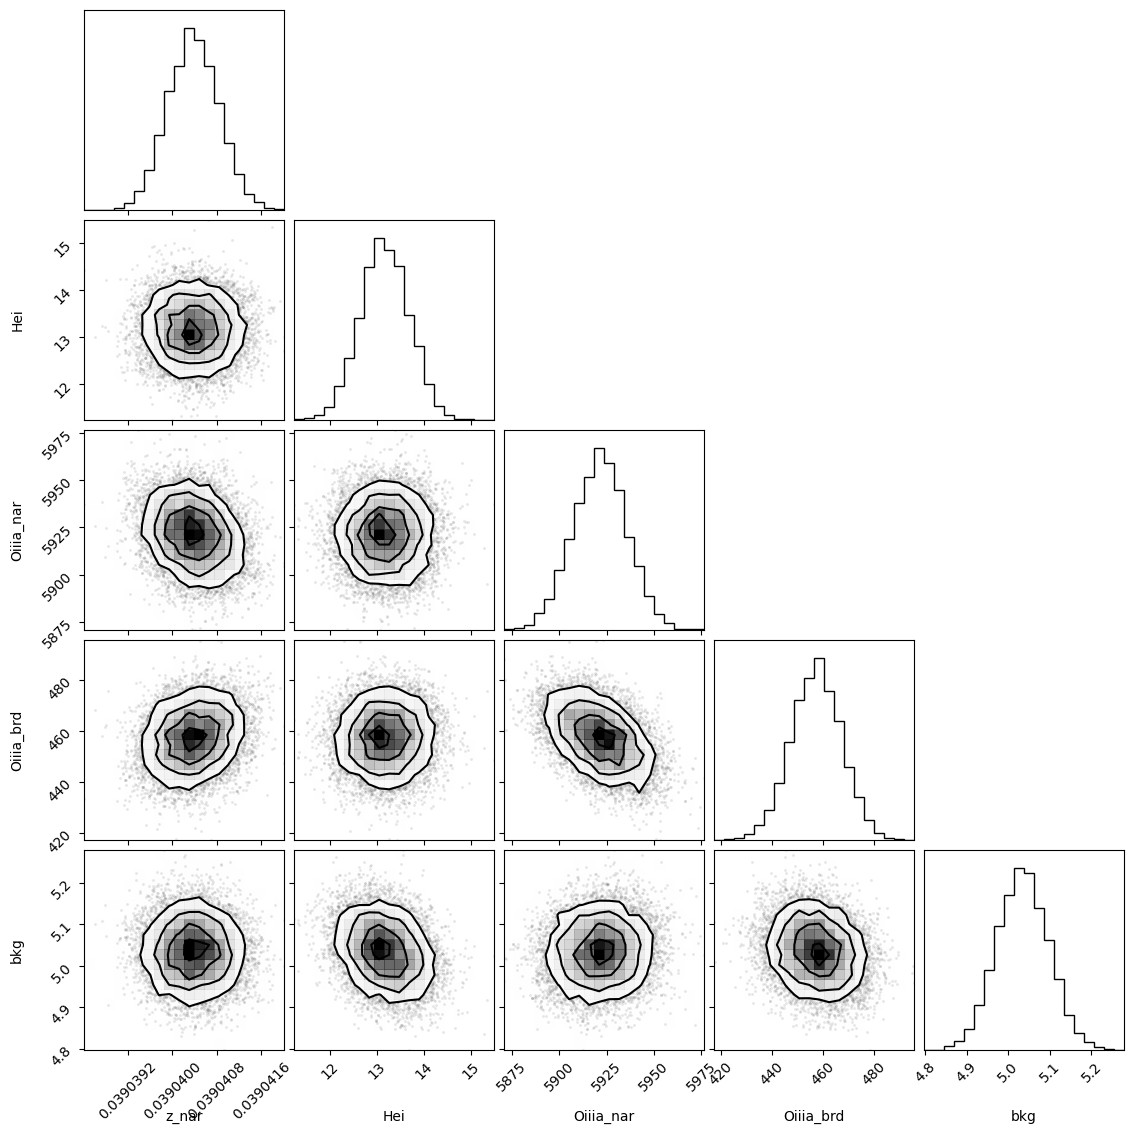

In [175]:
corner.corner(out_oiii_hei.flatchain, labels=out_oiii_hei.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

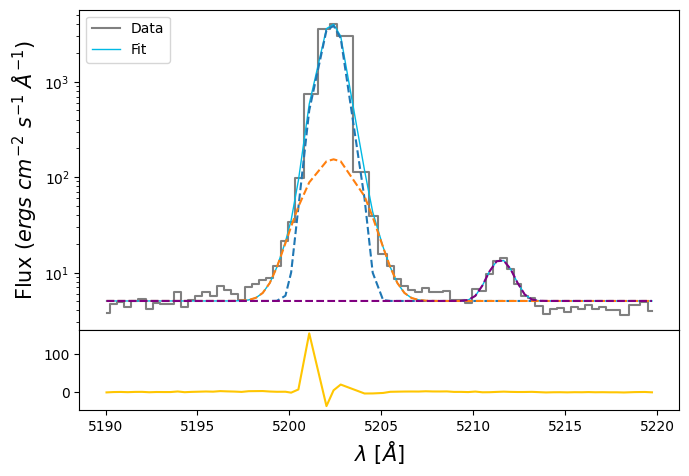

In [176]:
hei_flux = out2_oiii_hei.params['Hei'].value
hei_std = out2_oiii_hei.params['Hei'].stderr

oiiia_nar_flux = out2_oiii_hei.params['Oiiia_nar'].value
oiiia_nar_std = out2_oiii_hei.params['Oiiia_nar'].stderr

oiiia_brd_flux = out2_oiii_hei.params['Oiiia_brd'].value
oiiia_brd_std = out2_oiii_hei.params['Oiiia_brd'].stderr

z_oiii_hei = out2_oiii_hei.params['z_nar'].value
z_oiii_hei_std = out2_oiii_hei.params['z_nar'].stderr

bkg_oiii_hei = out2_oiii_hei.params['bkg'].value
bkg_oiii_hei_std = out2_oiii_hei.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oiii_hei.wavelength, oiii_hei.flux,
            color='gray', label='Data', where='mid')

hei = gaussian(oiii_hei.wavelength, hei_flux, wave_cat['HeI5015'], z_oiii_hei, upy.nominal_values(sigma_nar_5007))

oiiia_nar = gaussian(oiii_hei.wavelength, oiiia_nar_flux, wave_cat['[OIII]5007'], z_oiii_hei, upy.nominal_values(sigma_nar_5007))
oiiia_brd = gaussian(oiii_hei.wavelength, oiiia_brd_flux, wave_cat['[OIII]5007'], z_oiii_hei * z_ratio, upy.nominal_values(sigma_brd_5007))

oiiia = oiiia_nar + oiiia_brd

ax.plot(oiii_hei.wavelength, bkg_oiii_hei + oiiia + hei,
        lw=1, color=c[0], label='Fit')
ax.plot(oiii_hei.wavelength, bkg_oiii_hei + oiiia_nar, ls='--')
ax.plot(oiii_hei.wavelength, bkg_oiii_hei + oiiia_brd, ls='--')
ax.plot(oiii_hei.wavelength, bkg_oiii_hei + hei, ls='--', color='purple')

ax1.plot(oiii_hei.wavelength, oiii_hei.flux - bkg_oiii_hei - oiiia - hei,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [177]:
# EW
EW_OIII_5007_nar = ufloat(oiiia_nar_flux, oiiia_nar_std) / ufloat(bkg_oiii_hei, bkg_oiii_hei_std)
EW_OIII_5007_brd = ufloat(oiiia_brd_flux, oiiia_brd_std) / ufloat(bkg_oiii_hei, bkg_oiii_hei_std)
EW_OIII_5007 = (ufloat(oiiia_nar_flux, oiiia_nar_std) + ufloat(oiiia_brd_flux, oiiia_brd_std)) / ufloat(bkg_oiii_hei, bkg_oiii_hei_std)

# [OIII]4363

In [178]:
sigma_arc_4363 = (m * wave_cat['[OIII]4363']*(1 + z_BN[igal])) + n

sigma_nar_4363 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_4363**2))
sigma_brd_4363 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_4363**2))

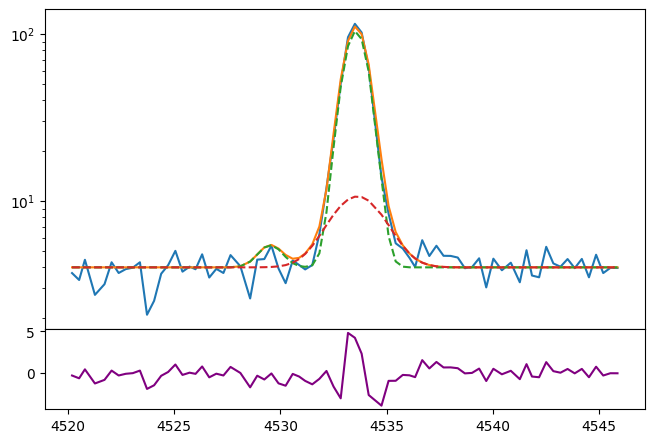

In [179]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oiii_4363.wavelength, oiii_4363.flux)
bkg = 4

feii_4360 = gaussian(oiii_4363.wavelength, 0.2e1, wave_cat['[FeII]4360'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_4363))
oiiic_nar = gaussian(oiii_4363.wavelength, 1.4e2, wave_cat['[OIII]4363'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_4363))
oiiic_brd = gaussian(oiii_4363.wavelength, 2.0e1, wave_cat['[OIII]4363'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_4363))

ax.plot(oiii_4363.wavelength, bkg + oiiic_nar + oiiic_brd + feii_4360)
ax.plot(oiii_4363.wavelength, bkg + oiiic_nar + feii_4360, ls='--')
ax.plot(oiii_4363.wavelength, bkg + oiiic_brd, ls='--')
ax1.plot(oiii_4363.wavelength, oiii_4363.flux - bkg - oiiic_nar - oiiic_brd - feii_4360, color='purple')
ax.set_yscale('log')

In [180]:
params_oiiic = Parameters()

params_oiiic.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oiiic.add('z_ratio', value=z_ratio, vary=False)
params_oiiic.add('sigma_nar', value=upy.nominal_values(sigma_nar_4363), vary=False)
params_oiiic.add('sigma_brd', value=upy.nominal_values(sigma_brd_4363), vary=False)
params_oiiic.add('Feii_4360_nar', value=0.2e1, min=0.)
params_oiiic.add('Oiiic_nar', value=1.4e2, min=0.)
params_oiiic.add('Oiiic_brd', value=2.0e1, min=0.)
params_oiiic.add('bkg', value=4, min=0.)


def residual_oiiic(params_oiiic, x, data, uncertainty):
    
    z_nar = params_oiiic['z_nar']
    z_brd = params_oiiic['z_nar'] * params_oiiic['z_ratio']
    sigma_nar = params_oiiic['sigma_nar']
    sigma_brd = params_oiiic['sigma_brd']
    feii_4360_flux = params_oiiic['Feii_4360_nar']
    oiiic_nar_flux = params_oiiic['Oiiic_nar']
    oiiic_brd_flux = params_oiiic['Oiiic_brd']
    bkg = params_oiiic['bkg']
    
    x = oiii_4363.wavelength
    model = gaussian(x, feii_4360_flux, wave_cat['[FeII]4360'], z_nar, sigma_nar) + \
            gaussian(x, oiiic_nar_flux, wave_cat['[OIII]4363'], z_nar, sigma_nar) + \
            gaussian(x, oiiic_brd_flux, wave_cat['[OIII]4363'], z_brd, sigma_brd)
    
    return (model + bkg - oiii_4363.flux) / oiii_4363.noise

In [181]:
np.random.seed(1444)
out_oiiic = minimize(residual_oiiic, params_oiiic, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:20<00:00, 122.43it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [49.78485035 60.39963611 67.98974091 79.77014699 46.18625168]


In [182]:
out_oiiic.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03903886,1.4927e-06,(0.00%),0.039041570755652975,-inf,inf,True
z_ratio,1.00046454,,,1.0004645413076385,-inf,inf,False
sigma_nar,0.55669009,,,0.5566900929672979,-inf,inf,False
sigma_brd,1.20325868,,,1.2032586840575,-inf,inf,False
Feii_4360_nar,0.73272568,0.49274884,(67.25%),2.0,0.00000000,inf,True
Oiiic_nar,149.046657,2.05344108,(1.38%),140.0,0.00000000,inf,True
Oiiic_brd,8.47474589,2.28434578,(26.95%),20.0,0.00000000,inf,True
bkg,3.97284439,0.08617132,(2.17%),4,0.00000000,inf,True


In [183]:
np.random.seed(1444)
out2_oiiic = minimize(residual_oiiic, out_oiiic.params, args=(1, 1, 1),
                      method='leastsq')

In [184]:
out2_oiiic.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03903889,1.7151e-06,(0.00%),0.039038856130347084,-inf,inf,True
z_ratio,1.00046454,0.00000000,(0.00%),1.0004645413076385,-inf,inf,False
sigma_nar,0.55669009,0.00000000,(0.00%),0.5566900929672979,-inf,inf,False
sigma_brd,1.20325868,0.00000000,(0.00%),1.2032586840575,-inf,inf,False
Feii_4360_nar,0.60162304,0.65164444,(108.31%),0.7327256845047013,0.00000000,inf,True
Oiiic_nar,149.083028,2.32380739,(1.56%),149.04665680508103,0.00000000,inf,True
Oiiic_brd,8.41038038,2.59734172,(30.88%),8.474745892327293,0.00000000,inf,True
bkg,3.98081069,0.09894232,(2.49%),3.9728443910820515,0.00000000,inf,True


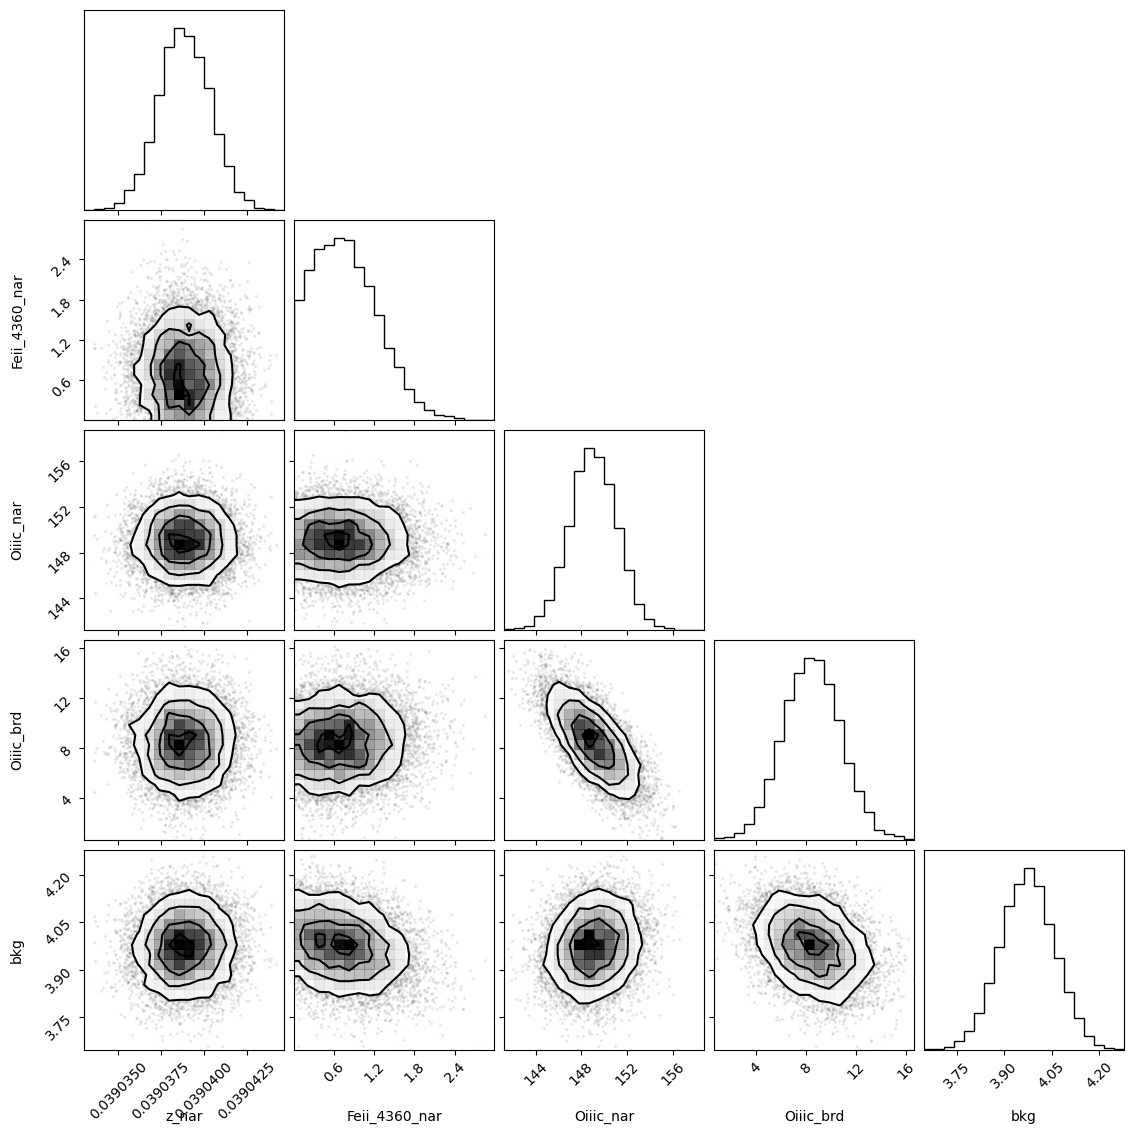

In [185]:
corner.corner(out_oiiic.flatchain, labels=out_oiiic.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

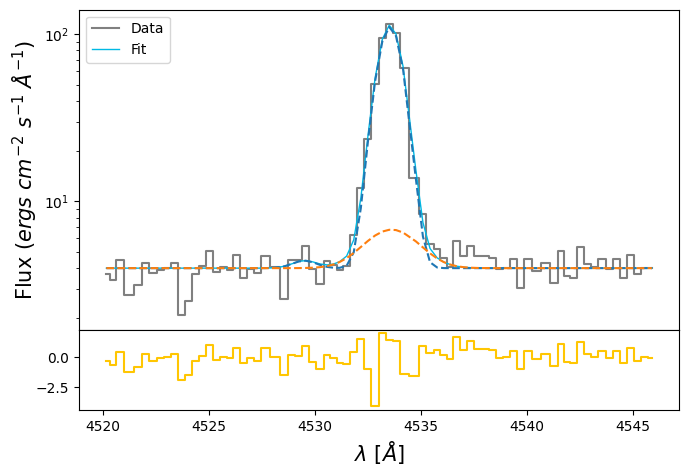

In [186]:
oiiic_nar_flux = out2_oiiic.params['Oiiic_nar'].value
oiiic_nar_std = out2_oiiic.params['Oiiic_nar'].stderr

oiiic_brd_flux = out2_oiiic.params['Oiiic_brd'].value
oiiic_brd_std = out2_oiiic.params['Oiiic_brd'].stderr

feii_4360_flux = out2_oiiic.params['Feii_4360_nar'].value
feii_4360_std = out2_oiiic.params['Feii_4360_nar'].stderr

z_oiii = out2_oiiic.params['z_nar'].value
z_oiii_std = out2_oiiic.params['z_nar'].stderr

bkg_oiiic = out2_oiiic.params['bkg'].value
bkg_oiiic_std = out2_oiiic.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oiii_4363.wavelength, oiii_4363.flux,
            color='gray', label='Data', where='mid')

feii_4360 = gaussian(oiii_4363.wavelength, feii_4360_flux, wave_cat['[FeII]4360'], z_oiii, upy.nominal_values(sigma_nar_4363))
oiiic_nar = gaussian(oiii_4363.wavelength, oiiic_nar_flux, wave_cat['[OIII]4363'], z_oiii, upy.nominal_values(sigma_nar_4363))
oiiic_brd = gaussian(oiii_4363.wavelength, oiiic_brd_flux, wave_cat['[OIII]4363'], z_oiii * z_ratio, upy.nominal_values(sigma_brd_4363))
oiiic = oiiic_nar + oiiic_brd

ax.plot(oiii_4363.wavelength, bkg_oiiic + oiiic + feii_4360, lw=1, color=c[0], label='Fit')
ax.plot(oiii_4363.wavelength, bkg_oiiic + oiiic_nar + feii_4360, ls='--')
ax.plot(oiii_4363.wavelength, bkg_oiiic + oiiic_brd, ls='--')
ax1.step(oiii_4363.wavelength, oiii_4363.flux - bkg_oiiic - oiiic - feii_4360, color=c[3], where='mid')
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [187]:
# EW
EW_OIII_4363_nar = ufloat(oiiic_nar_flux, oiiic_nar_std) / ufloat(bkg_oiiic, bkg_oiiic_std)
EW_OIII_4363_brd = ufloat(oiiic_brd_flux, oiiic_brd_std) / ufloat(bkg_oiiic, bkg_oiiic_std)
EW_OIII_4363 = (ufloat(oiiic_nar_flux, oiiic_nar_std) + ufloat(oiiic_brd_flux, oiiic_brd_std)) / ufloat(bkg_oiiic, bkg_oiiic_std)

# [ArIII]7135

In [188]:
sigma_arc_7135 = (m * wave_cat['[ArIII]7135']*(1 + z_BN[igal])) + n

sigma_nar_7135 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_7135**2))
sigma_brd_7135 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_7135**2))

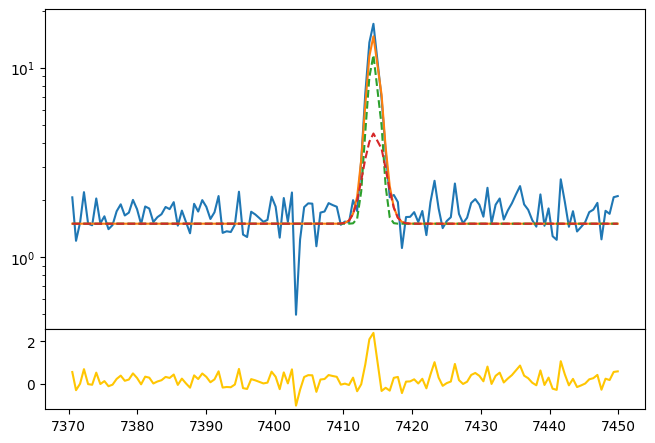

In [189]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(ariii_7135.wavelength, ariii_7135.flux)
bkg = 1.5

ariiia_nar = gaussian(ariii_7135.wavelength, 2e1, wave_cat['[ArIII]7135'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_7135))
ariiia_brd = gaussian(ariii_7135.wavelength, 1e1, wave_cat['[ArIII]7135'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_7135))

ax.plot(ariii_7135.wavelength, bkg + ariiia_nar + ariiia_brd)
ax.plot(ariii_7135.wavelength, bkg + ariiia_nar, ls='--')
ax.plot(ariii_7135.wavelength, bkg + ariiia_brd, ls='--')
ax1.plot(ariii_7135.wavelength, ariii_7135.flux - bkg - ariiia_nar - ariiia_brd, color=c[3])
ax.set_yscale('log')

In [190]:
params_ariii = Parameters()
params_ariii.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_ariii.add('z_ratio', value=z_ratio, vary=False)
params_ariii.add('sigma_nar', value=upy.nominal_values(sigma_nar_7135), vary=False)
params_ariii.add('sigma_brd', value=upy.nominal_values(sigma_brd_7135), vary=False)
params_ariii.add('Ariiia_nar', value=2e1, min=0.)
params_ariii.add('Ariiia_brd', value=1e1, min=0.)
params_ariii.add('bkg', value=1.5, min=0.)


def residual_ariii(params_ariii, x, data, uncertainty):
    
    z_nar = params_ariii['z_nar']
    z_brd = params_ariii['z_nar'] * params_ariii['z_ratio']
    sigma_nar = params_ariii['sigma_nar']
    sigma_brd = params_ariii['sigma_brd']
    ariiia_nar = params_ariii['Ariiia_nar']
    ariiia_brd = params_ariii['Ariiia_brd']
    bkg = params_ariii['bkg']
    
    x = ariii_7135.wavelength
    model_ariii = gaussian(x, ariiia_nar, wave_cat['[ArIII]7135'], z_nar, sigma_nar) \
                + gaussian(x, ariiia_brd, wave_cat['[ArIII]7135'], z_brd, sigma_brd)
    
    return (model_ariii + bkg - ariii_7135.flux) / ariii_7135.noise

In [191]:
np.random.seed(1444)
out_ariii = minimize(residual_ariii, params_ariii, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:20<00:00, 124.80it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [45.41019651 69.03216783 63.77788713 68.4226507 ]


In [192]:
out_ariii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03903500,2.7706e-06,(0.01%),0.039041570755652975,-inf,inf,True
z_ratio,1.00046454,,,1.0004645413076385,-inf,inf,False
sigma_nar,0.78653392,,,0.7865339161773541,-inf,inf,False
sigma_brd,1.32535399,,,1.3253539913732981,-inf,inf,False
Ariiia_nar,27.6004556,1.19089345,(4.31%),20.0,0.00000000,inf,True
Ariiia_brd,4.36055212,1.30982470,(30.04%),10.0,0.00000000,inf,True
bkg,1.71473205,0.02129520,(1.24%),1.5,0.00000000,inf,True


In [193]:
np.random.seed(1444)
out2_ariii = minimize(residual_ariii, out_ariii.params, args=(1, 1, 1), method='leastsq')

In [194]:
out2_ariii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03903495,3.2328e-06,(0.01%),0.0390349996794315,-inf,inf,True
z_ratio,1.00046454,0.00000000,(0.00%),1.0004645413076385,-inf,inf,False
sigma_nar,0.78653392,0.00000000,(0.00%),0.7865339161773541,-inf,inf,False
sigma_brd,1.32535399,0.00000000,(0.00%),1.3253539913732981,-inf,inf,False
Ariiia_nar,27.6191279,1.42329068,(5.15%),27.60045559674132,0.00000000,inf,True
Ariiia_brd,4.35563175,1.54484032,(35.47%),4.360552122876543,0.00000000,inf,True
bkg,1.71446947,0.02520229,(1.47%),1.714732048674696,0.00000000,inf,True


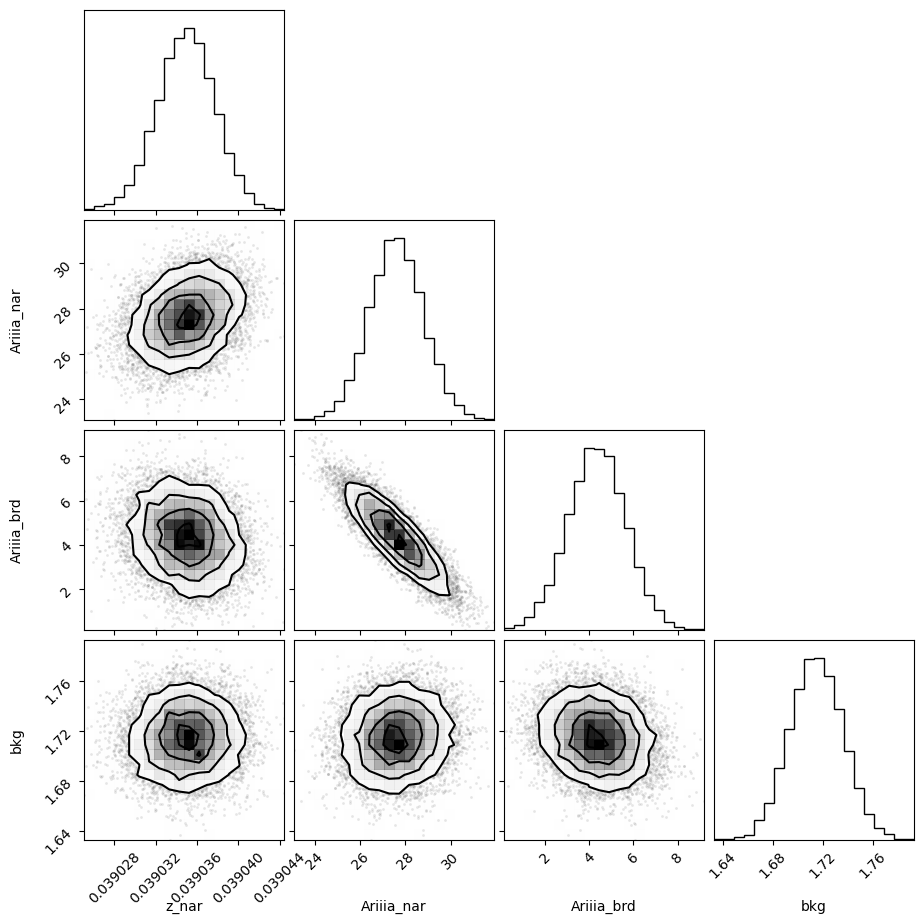

In [195]:
corner.corner(out_ariii.flatchain, labels=out_ariii.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

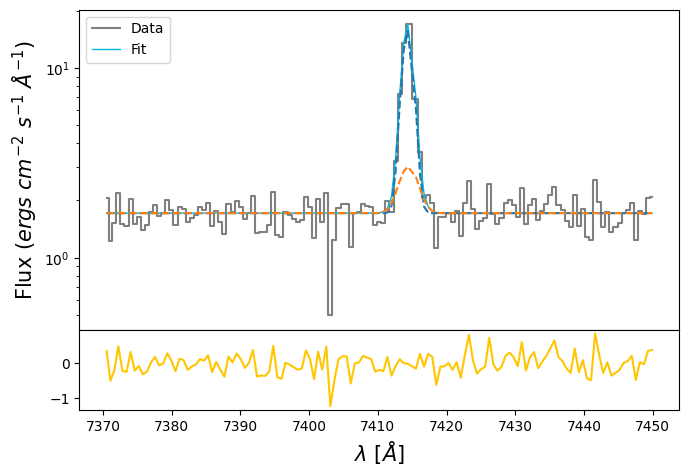

In [196]:
ariiia_nar_flux = out2_ariii.params['Ariiia_nar'].value
ariiia_nar_std = out2_ariii.params['Ariiia_nar'].stderr

ariiia_brd_flux = out2_ariii.params['Ariiia_brd'].value
ariiia_brd_std = out2_ariii.params['Ariiia_brd'].stderr

z_ariii = out2_ariii.params['z_nar'].value
z_ariii_std = out2_ariii.params['z_nar'].stderr

bkg_ariii = out2_ariii.params['bkg'].value
bkg_ariii_std = out2_ariii.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(ariii_7135.wavelength, ariii_7135.flux,
            color='gray', label='Data', where='mid')

ariiia_nar = gaussian(ariii_7135.wavelength, ariiia_nar_flux, wave_cat['[ArIII]7135'], z_ariii, upy.nominal_values(sigma_nar_7135))
ariiia_brd = gaussian(ariii_7135.wavelength, ariiia_brd_flux, wave_cat['[ArIII]7135'], z_ariii * z_ratio, upy.nominal_values(sigma_brd_7135))

ariiia = ariiia_nar + ariiia_brd

ax.plot(ariii_7135.wavelength, bkg_ariii + ariiia,
        lw=1, color=c[0], label='Fit')
ax.plot(ariii_7135.wavelength, bkg_ariii + ariiia_nar, ls='--')
ax.plot(ariii_7135.wavelength, bkg_ariii + ariiia_brd, ls='--')

ax1.plot(ariii_7135.wavelength, ariii_7135.flux - bkg_ariii - ariiia,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [197]:
# EW
EW_ArIII_7135_nar = ufloat(ariiia_nar_flux, ariiia_nar_std) / ufloat(bkg_ariii, bkg_ariii_std)
EW_ArIII_7135_brd = ufloat(ariiia_brd_flux, ariiia_brd_std) / ufloat(bkg_ariii, bkg_ariii_std)
EW_ArIII_7135 = (ufloat(ariiia_nar_flux, ariiia_nar_std) + ufloat(ariiia_brd_flux, ariiia_brd_std)) / ufloat(bkg_ariii, bkg_ariii_std)

# [ArIV]4740

In [198]:
sigma_arc_4740 = (m * wave_cat['[ArIV]4740']*(1 + z_BN[igal])) + n

sigma_nar_4740 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_4740**2))
sigma_brd_4740 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_4740**2))

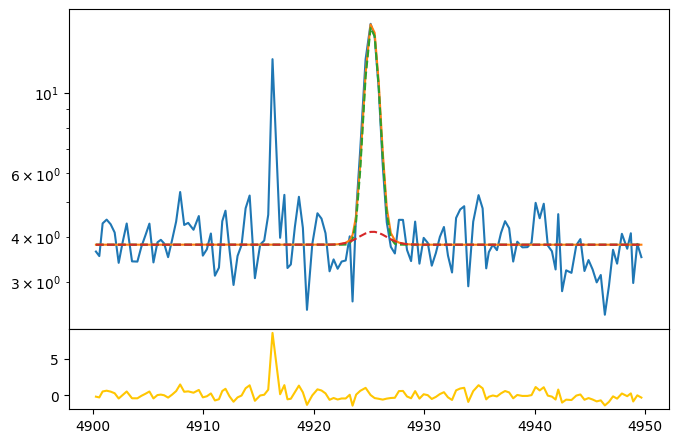

In [199]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(ariv_4740.wavelength, ariv_4740.flux)
bkg = 3.8

ariva_nar = gaussian(ariv_4740.wavelength, 17, wave_cat['[ArIV]4740'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_4740))
ariva_brd = gaussian(ariv_4740.wavelength, 1, wave_cat['[ArIV]4740'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_4740))

ax.plot(ariv_4740.wavelength, bkg + ariva_nar + ariva_brd)
ax.plot(ariv_4740.wavelength, bkg + ariva_nar, ls='--')
ax.plot(ariv_4740.wavelength, bkg + ariva_brd, ls='--')
ax1.plot(ariv_4740.wavelength, ariv_4740.flux - bkg - ariva_nar - ariva_brd, color=c[3])
ax.set_yscale('log')

In [200]:
params_ariv = Parameters()
params_ariv.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_ariv.add('z_ratio', value=z_ratio, vary=False)
params_ariv.add('sigma_nar', value=upy.nominal_values(sigma_nar_4740), vary=False)
params_ariv.add('sigma_brd', value=upy.nominal_values(sigma_brd_4740), vary=False)
params_ariv.add('Ariva_nar', value=17, min=0.)
params_ariv.add('Ariva_brd', value=0., vary=False)
params_ariv.add('bkg', value=3.8, min=0.)


def residual_ariv(params_ariv, x, data, uncertainty):
    
    z_nar = params_ariv['z_nar']
    z_brd = params_ariv['z_nar'] * params_ariv['z_ratio']
    sigma_nar = params_ariv['sigma_nar']
    sigma_brd = params_ariv['sigma_brd']
    ariva_nar = params_ariv['Ariva_nar']
    ariva_brd = params_ariv['Ariva_brd']
    bkg = params_ariv['bkg']
    
    x = ariv_4740.wavelength
    model_ariv = gaussian(x, ariva_nar, wave_cat['[ArIV]4740'], z_nar, sigma_nar) \
                + gaussian(x, ariva_brd, wave_cat['[ArIV]4740'], z_brd, sigma_brd)
    
    return (model_ariv + bkg - ariv_4740.flux) / ariv_4740.noise

In [201]:
np.random.seed(1444)
out_ariv = minimize(residual_ariv, params_ariv, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:20<00:00, 123.85it/s]


In [202]:
out_ariv.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03902784,5.2197e-06,(0.01%),0.039041570755652975,-inf,inf,True
z_ratio,1.00046454,,,1.0004645413076385,-inf,inf,False
sigma_nar,0.58629464,,,0.5862946401156967,-inf,inf,False
sigma_brd,1.21723827,,,1.2172382700935105,-inf,inf,False
Ariva_nar,17.7749105,0.57213678,(3.22%),17,0.00000000,inf,True
Ariva_brd,0.00000000,,,0.0,-inf,inf,False
bkg,3.84796988,0.04422443,(1.15%),3.8,0.00000000,inf,True


In [203]:
np.random.seed(1444)
out2_ariv = minimize(residual_ariv, out_ariv.params, args=(1, 1, 1), method='leastsq')

In [204]:
out2_ariv.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03902808,6.5365e-06,(0.02%),0.0390278435981377,-inf,inf,True
z_ratio,1.00046454,0.00000000,(0.00%),1.0004645413076385,-inf,inf,False
sigma_nar,0.58629464,0.00000000,(0.00%),0.5862946401156967,-inf,inf,False
sigma_brd,1.21723827,0.00000000,(0.00%),1.2172382700935105,-inf,inf,False
Ariva_nar,17.8050254,0.73247272,(4.11%),17.774910454004928,0.00000000,inf,True
Ariva_brd,0.00000000,0.00000000,,0.0,-inf,inf,False
bkg,3.84708622,0.05712410,(1.48%),3.847969881561638,0.00000000,inf,True


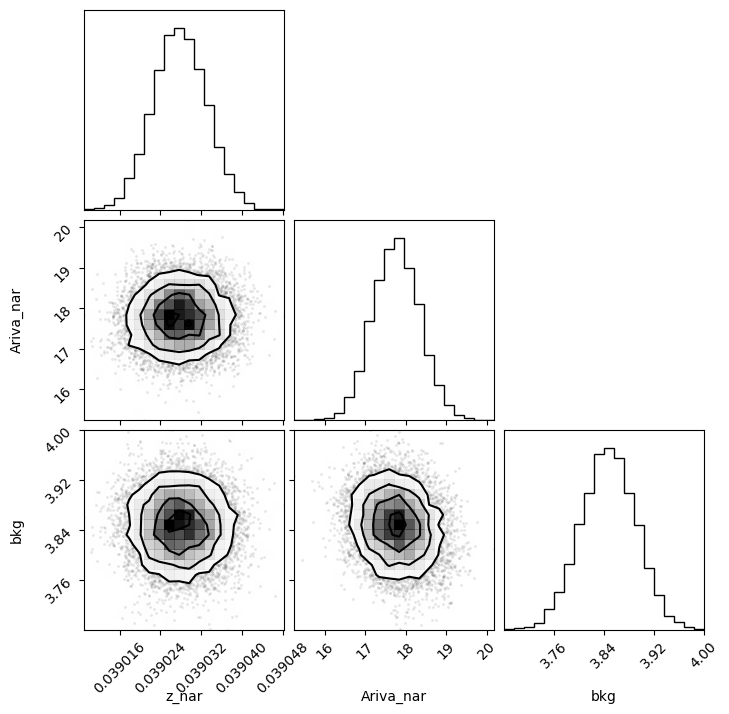

In [205]:
corner.corner(out_ariv.flatchain, labels=out_ariv.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

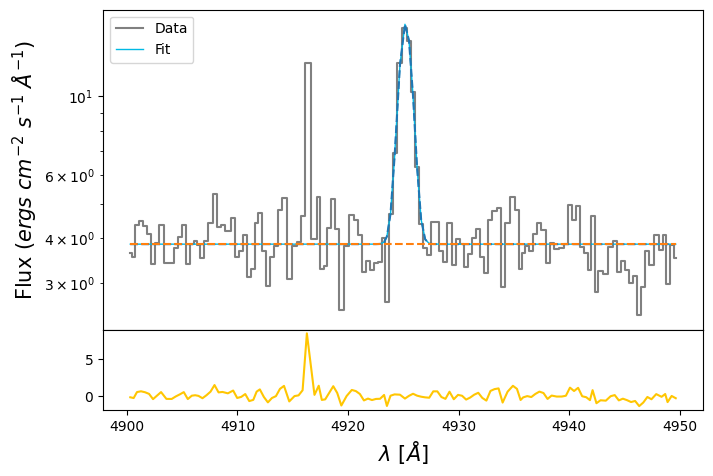

In [206]:
ariva_nar_flux = out2_ariv.params['Ariva_nar'].value
ariva_nar_std = out2_ariv.params['Ariva_nar'].stderr

ariva_brd_flux = out2_ariv.params['Ariva_brd'].value
ariva_brd_std = out2_ariv.params['Ariva_brd'].stderr

z_ariv = out2_ariv.params['z_nar'].value
z_ariv_std = out2_ariv.params['z_nar'].stderr

bkg_ariv = out2_ariv.params['bkg'].value
bkg_ariv_std = out2_ariv.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(ariv_4740.wavelength, ariv_4740.flux,
            color='gray', label='Data', where='mid')

ariva_nar = gaussian(ariv_4740.wavelength, ariva_nar_flux, wave_cat['[ArIV]4740'], z_ariv, upy.nominal_values(sigma_nar_4740))
ariva_brd = gaussian(ariv_4740.wavelength, ariva_brd_flux, wave_cat['[ArIV]4740'], z_ariv * z_ratio, upy.nominal_values(sigma_brd_4740))

ariva = ariva_nar + ariva_brd

ax.plot(ariv_4740.wavelength, bkg_ariv + ariva,
        lw=1, color=c[0], label='Fit')
ax.plot(ariv_4740.wavelength, bkg_ariv + ariva_nar, ls='--')
ax.plot(ariv_4740.wavelength, bkg_ariv + ariva_brd, ls='--')

ax1.plot(ariv_4740.wavelength, ariv_4740.flux - bkg_ariv - ariva,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [207]:
fl_ariv = ufloat(ariva_nar_flux, ariva_nar_std) + ufloat(ariva_brd_flux, ariva_brd_std)
sn_ariv = fl_ariv.nominal_value / fl_ariv.std_dev
print(sn_ariv)

24.308107356253974


In [208]:
# EW
EW_ArIV_4740_nar = ufloat(ariva_nar_flux, ariva_nar_std) / ufloat(bkg_ariv, bkg_ariv_std)
EW_ArIV_4740_brd = ufloat(ariva_brd_flux, ariva_brd_std) / ufloat(bkg_ariv, bkg_ariv_std)
EW_ArIV_4740 = (ufloat(ariva_nar_flux, ariva_nar_std) + ufloat(ariva_brd_flux, ariva_brd_std)) / ufloat(bkg_ariv, bkg_ariv_std)

# [NeIII]3868

In [209]:
sigma_arc_3868 = (m * wave_cat['[NeIII]3868']*(1 + z_BN[igal])) + n

sigma_nar_3868 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_3868**2))
sigma_brd_3868 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_3868**2))

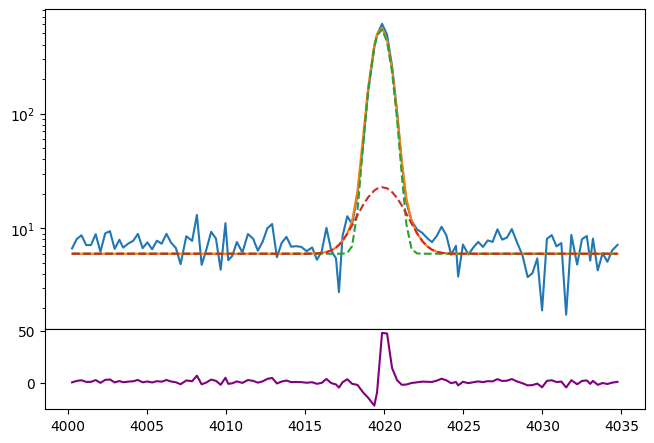

In [210]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(neiii_3868.wavelength, neiii_3868.flux)
bkg = 6

neiiia_nar = gaussian(neiii_3868.wavelength, 7e2, wave_cat['[NeIII]3868'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_3868))
neiiia_brd = gaussian(neiii_3868.wavelength, 5e1, wave_cat['[NeIII]3868'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_3868))

ax.plot(neiii_3868.wavelength, bkg + neiiia_nar + neiiia_brd)
ax.plot(neiii_3868.wavelength, bkg + neiiia_nar, ls='--')
ax.plot(neiii_3868.wavelength, bkg + neiiia_brd, ls='--')
ax1.plot(neiii_3868.wavelength, neiii_3868.flux - bkg - neiiia_nar - neiiia_brd, color='purple')
ax.set_yscale('log')

In [211]:
params_neiii_3868 = Parameters()
params_neiii_3868.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_neiii_3868.add('z_ratio', value=z_ratio, vary=False)
params_neiii_3868.add('sigma_nar', value=upy.nominal_values(sigma_nar_3868), vary=False)
params_neiii_3868.add('sigma_brd', value=upy.nominal_values(sigma_brd_3868), vary=False)
params_neiii_3868.add('Neiiia_nar', value=7e2, min=0.)
params_neiii_3868.add('Neiiia_brd', value=5e1, min=0.)
params_neiii_3868.add('bkg', value=6, min=0.)


def residual_neiii_3868(params_neiii_3868, x, data, uncertainty):
    
    z_nar = params_neiii_3868['z_nar']
    z_brd = params_neiii_3868['z_nar'] * params_neiii_3868['z_ratio']
    sigma_nar = params_neiii_3868['sigma_nar']
    sigma_brd = params_neiii_3868['sigma_brd']
    neiiia_nar_flux = params_neiii_3868['Neiiia_nar']
    neiiia_brd_flux = params_neiii_3868['Neiiia_brd']
    bkg = params_neiii_3868['bkg']
    
    x = neiii_3868.wavelength
    model = gaussian(x, neiiia_nar_flux, wave_cat['[NeIII]3868'], z_nar, sigma_nar) + \
            gaussian(x, neiiia_brd_flux, wave_cat['[NeIII]3868'], z_brd, sigma_brd)
    
    return (model + bkg - neiii_3868.flux) / neiii_3868.noise

In [212]:
np.random.seed(1444)
out_neiii_3868 = minimize(residual_neiii_3868, params_neiii_3868, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:19<00:00, 130.04it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [40.75455577 56.68023357 74.1469922  79.40967173]


In [213]:
out_neiii_3868.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03904949,1.0599e-06,(0.00%),0.039041570755652975,-inf,inf,True
z_ratio,1.00046454,,,1.0004645413076385,-inf,inf,False
sigma_nar,0.51904500,,,0.5190450021081664,-inf,inf,False
sigma_brd,1.18631164,,,1.186311643441686,-inf,inf,False
Neiiia_nar,733.983758,7.79193770,(1.06%),700.0,0.00000000,inf,True
Neiiia_brd,23.0427309,5.74305533,(24.92%),50.0,0.00000000,inf,True
bkg,7.23146258,0.16328089,(2.26%),6,0.00000000,inf,True


In [214]:
np.random.seed(1444)
out2_neiii_3868 = minimize(residual_neiii_3868, out_neiii_3868.params, args=(1, 1, 1), method='leastsq')

In [215]:
out2_neiii_3868.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03904943,1.2479e-06,(0.00%),0.039049488570918334,-inf,inf,True
z_ratio,1.00046454,0.00000000,(0.00%),1.0004645413076385,-inf,inf,False
sigma_nar,0.51904500,0.00000000,(0.00%),0.5190450021081664,-inf,inf,False
sigma_brd,1.18631164,0.00000000,(0.00%),1.186311643441686,-inf,inf,False
Neiiia_nar,734.000673,8.90109809,(1.21%),733.9837581545196,0.00000000,inf,True
Neiiia_brd,22.9974872,6.49467508,(28.24%),23.042730902562198,0.00000000,inf,True
bkg,7.22779616,0.19190702,(2.66%),7.231462575425512,0.00000000,inf,True


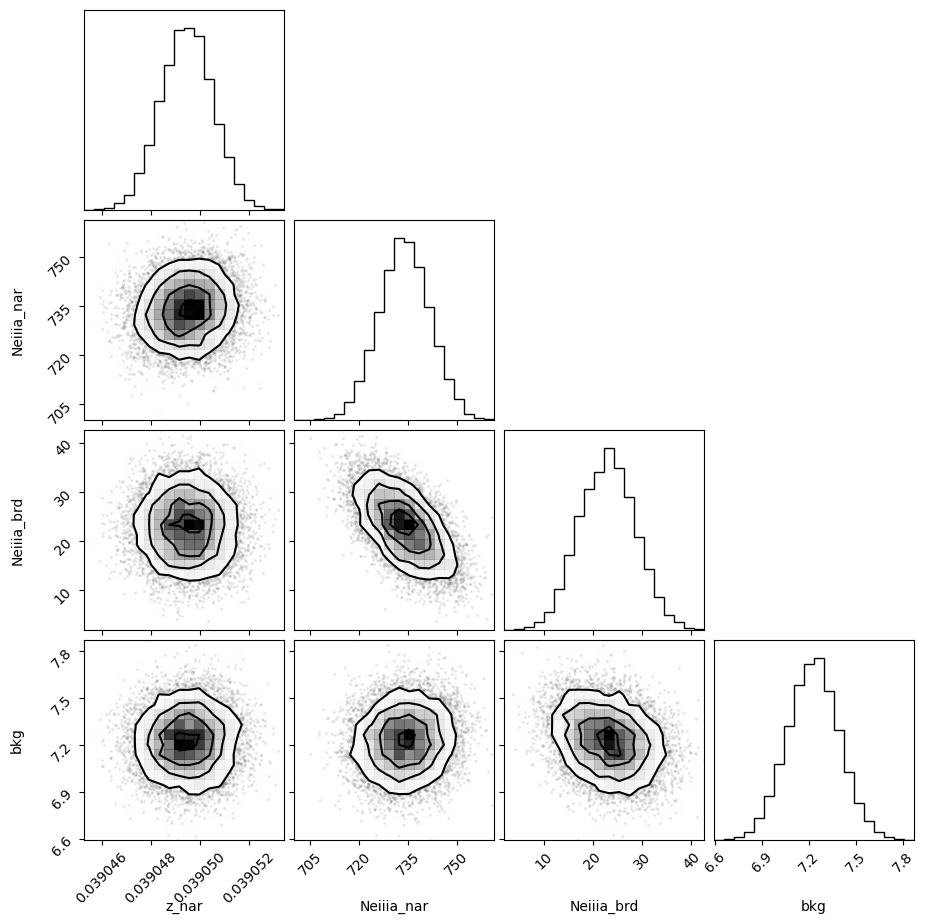

In [216]:
corner.corner(out_neiii_3868.flatchain, labels=out_neiii_3868.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

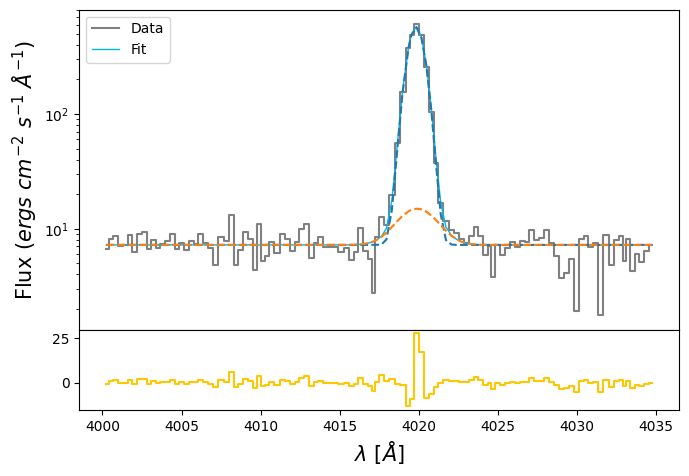

In [217]:
neiiia_nar_flux = out2_neiii_3868.params['Neiiia_nar'].value
neiiia_nar_std = out2_neiii_3868.params['Neiiia_nar'].stderr

neiiia_brd_flux = out2_neiii_3868.params['Neiiia_brd'].value
neiiia_brd_std = out2_neiii_3868.params['Neiiia_brd'].stderr

z_neiii = out2_neiii_3868.params['z_nar'].value
z_neiii_std = out2_neiii_3868.params['z_nar'].stderr

bkg_neiiia = out2_neiii_3868.params['bkg'].value
bkg_neiiia_std = out2_neiii_3868.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(neiii_3868.wavelength, neiii_3868.flux,
            color='gray', label='Data', where='mid')

neiiia_nar = gaussian(neiii_3868.wavelength, neiiia_nar_flux, wave_cat['[NeIII]3868'], z_neiii, upy.nominal_values(sigma_nar_3868))
neiiia_brd = gaussian(neiii_3868.wavelength, neiiia_brd_flux, wave_cat['[NeIII]3868'], z_neiii * z_ratio, upy.nominal_values(sigma_brd_3868))
neiiia = neiiia_nar + neiiia_brd

ax.plot(neiii_3868.wavelength, bkg_neiiia + neiiia, lw=1, color=c[0], label='Fit')
ax.plot(neiii_3868.wavelength, bkg_neiiia + neiiia_nar, ls='--')
ax.plot(neiii_3868.wavelength, bkg_neiiia + neiiia_brd, ls='--')
ax1.step(neiii_3868.wavelength, neiii_3868.flux - bkg_neiiia - neiiia, color=c[3], where='mid')
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [218]:
# EW
EW_NeIII_3868_nar = ufloat(neiiia_nar_flux, neiiia_nar_std) / ufloat(bkg_neiiia, bkg_neiiia_std)
EW_NeIII_3868_brd = ufloat(neiiia_brd_flux, neiiia_brd_std) / ufloat(bkg_neiiia, bkg_neiiia_std)
EW_NeIII_3868 = (ufloat(neiiia_nar_flux, neiiia_nar_std) + ufloat(neiiia_brd_flux, neiiia_brd_std)) / ufloat(bkg_neiiia, bkg_neiiia_std)

# Balmer decrements

In [219]:
from magE.functions import *
from magE.functions import calzetti2000 as k_cal

flux_ha_bal = ufloat(ha_nar_flux, ha_nar_std) + ufloat(ha_brd_flux, ha_brd_std)
flux_hb_bal = ufloat(hb_nar_flux, hb_nar_std) + ufloat(hb_brd_flux, hb_brd_std)
flux_hg_bal = ufloat(hg_nar_flux, hg_nar_std) + ufloat(hg_brd_flux, hg_brd_std)
flux_hd_bal = ufloat(hd_nar_flux, hd_nar_std) + ufloat(hd_brd_flux, hd_brd_std)

y_balmer = upy.log10([(flux_ha_bal / flux_hb_bal) / 2.86, 
                    (flux_hb_bal / flux_hb_bal) / 1.0,
                    (flux_hg_bal / flux_hb_bal) / 0.464,
                    (flux_hd_bal / flux_hb_bal) / 0.256])

x_balmer = np.array([k_cal(wave_cat['Ha']) - k_cal(wave_cat['Hb']),
                     k_cal(wave_cat['Hb']) - k_cal(wave_cat['Hb']),
                     k_cal(wave_cat['Hg']) - k_cal(wave_cat['Hb']),
                     k_cal(wave_cat['Hd']) - k_cal(wave_cat['Hb'])])

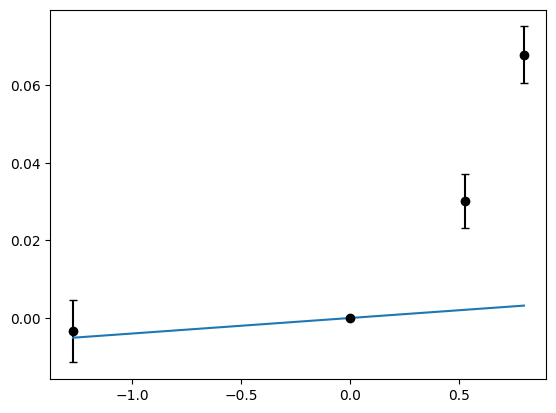

In [220]:
plt.errorbar(x_balmer, upy.nominal_values(y_balmer), upy.std_devs(y_balmer),
            ls='', color='black', marker='o', capsize=3)
plt.plot(x_balmer, x_balmer * (-0.4 * -0.01))

In [221]:
params_balmer = Parameters()
params_balmer.add('slope', value=-0.4 * 0.01)

def residuals_balmer(params_balmer, x, data, uncertainty):
    
    slope = params_balmer['slope']
    x = x_balmer
    
    model = x * (-slope)
    return (model - upy.nominal_values(y_balmer)) / np.max(upy.std_devs(y_balmer))

np.random.seed(1444)
out_balmer = minimize(residuals_balmer, params_balmer, args=(1, 1, 1),
                      method='leastsq')

In [222]:
out_balmer.params

name,value,standard error,relative error,initial value,min,max,vary
slope,-0.02933184,0.02096328,(71.47%),-0.004,-inf,inf,True


Text(0.5, 1.0, 'J1444+0409; $E(B-V) = $ -0.073 $\\pm$ 0.052')

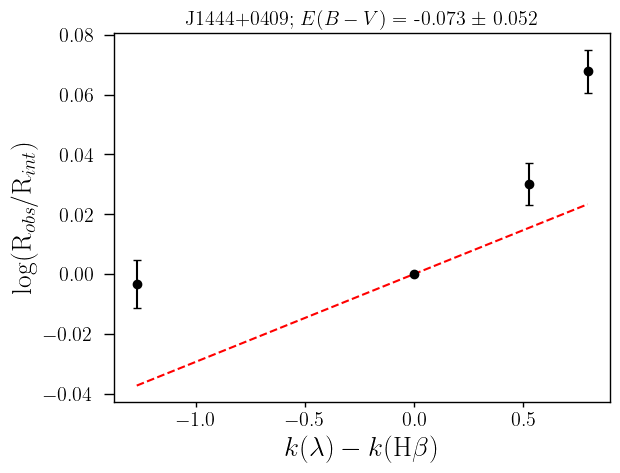

In [223]:
color_excess = ufloat(out_balmer.params['slope'].value, out_balmer.params['slope'].stderr) / 0.4
E_BV = out_balmer.params['slope'].value / 0.4

texPlot('on')
plt.errorbar(x_balmer, upy.nominal_values(y_balmer), upy.std_devs(y_balmer),
            ls='', color='black', marker='o', capsize=3)
plt.plot(x_balmer, - E_BV * 0.4 * x_balmer, ls='--', color='red')
plt.ylabel(r'log(R$_{obs}$/R$_{int}$)')
plt.xlabel(r'$k(\lambda) - k($H$\beta)$')
plt.title(r'J1444+0409; $E(B-V) = $ '+str(round(color_excess.nominal_value, 3))+' $\pm$ '+str(round(color_excess.std_dev, 3)))
#plt.savefig('/home/benjamin/Documents/analogs/results/balmer_decrements/bal_dec_lstsq_J1444.pdf', bbox_inches='tight')

In [224]:
decrement_dict = {'galname': galname,
                 'Ha/Hb': (flux_ha_bal / flux_hb_bal).nominal_value,
                 'Ha/Hb_err': (flux_ha_bal / flux_hb_bal).std_dev,
                 'Hg/Hb': (flux_hg_bal / flux_hb_bal).nominal_value,
                 'Hg/Hb_err': (flux_hg_bal / flux_hb_bal).std_dev,
                 'Hd/Hb': (flux_hd_bal / flux_hb_bal).nominal_value,
                 'Hd/Hb_err': (flux_hd_bal / flux_hb_bal).std_dev,
                 'E_BV': out_balmer.params['slope'].value / 0.4,
                 'E_BV_err': out_balmer.params['slope'].stderr / 0.4
                 }
decrement_dict_pd = pd.DataFrame(data=decrement_dict, index=[0])
#save_catalog(galname, decrement_dict_pd, magePath + '/results/bal_decrements_lstsq.csv')

# Dust correction

### Negative color excess

In [225]:
oiid_tot_flux = ((ufloat(oiid_nar_flux, oiid_nar_std) + ufloat(oiid_brd_flux, oiid_brd_std)) / 1e17)
oiic_tot_flux = ((ufloat(oiic_nar_flux, oiic_nar_std) + ufloat(oiic_brd_flux, oiic_brd_std)) / 1e17)

neiiia_tot_flux = ((ufloat(neiiia_nar_flux, neiiia_nar_std) + ufloat(neiiia_brd_flux, neiiia_brd_std)) / 1e17) 

hd_tot_flux = ((ufloat(hd_nar_flux, hd_nar_std) + ufloat(hd_brd_flux, hd_brd_std)) / 1e17) 

hg_tot_flux = ((ufloat(hg_nar_flux, hg_nar_std) + ufloat(hg_brd_flux, hg_brd_std)) / 1e17) 

oiiic_tot_flux = ((ufloat(oiiic_nar_flux, oiiic_nar_std) + ufloat(oiiic_brd_flux, oiiic_brd_std)) / 1e17) 

heid_tot_flux = ((ufloat(heid_nar_flux, heid_nar_std) + ufloat(heid_brd_flux, heid_brd_std)) / 1e17) 

feiiia_tot_flux = None

heiia_tot_flux = ((ufloat(heiia_nar_flux, heiia_nar_std) + ufloat(heiia_brd_flux, heiia_brd_std)) / 1e17) 

ariva_tot_flux = ((ufloat(ariva_nar_flux, ariva_nar_std) + ufloat(ariva_brd_flux, ariva_brd_std)) / 1e17) 

hb_tot_flux = ((ufloat(hb_nar_flux, hb_nar_std) + ufloat(hb_brd_flux, hb_brd_std)) / 1e17) 

oiiib_tot_flux = ((ufloat(oiiib_nar_flux, oiiib_nar_std) + ufloat(oiiib_brd_flux, oiiib_brd_std)) / 1e17) 

oiiia_tot_flux = ((ufloat(oiiia_nar_flux, oiiia_nar_std) + ufloat(oiiia_brd_flux, oiiia_brd_std)) / 1e17) 

niic_tot_flux = None

heic_tot_flux = ((ufloat(heic_nar_flux, heic_nar_std) + ufloat(heic_brd_flux, heic_brd_std)) / 1e17) 

oia_tot_flux = ((ufloat(oia_nar_flux, oia_nar_std) + ufloat(oia_brd_flux, oia_brd_std)) / 1e17) 

siiic_tot_flux = ((ufloat(siiic_nar_flux, siiic_nar_std) + ufloat(siiic_brd_flux, siiic_brd_std)) / 1e17) 

niib_tot_flux = ((ufloat(niib_nar_flux, niib_nar_std) + ufloat(niib_brd_flux, niib_brd_std)) / 1e17) 

ha_tot_flux = ((ufloat(ha_nar_flux, ha_nar_std) + ufloat(ha_brd_flux, ha_brd_std)) / 1e17) 

niia_tot_flux = ((ufloat(niia_nar_flux, niia_nar_std) + ufloat(niia_brd_flux, niia_brd_std)) / 1e17) 

heib_tot_flux = ((ufloat(heib_nar_flux, heib_nar_std) + ufloat(heib_brd_flux, heib_brd_std)) / 1e17) 

siib_tot_flux = ((ufloat(siib_nar_flux, siib_nar_std) + ufloat(siib_brd_flux, siib_brd_std)) / 1e17) 
siia_tot_flux = ((ufloat(siia_nar_flux, siia_nar_std) + ufloat(siia_brd_flux, siia_brd_std)) / 1e17) 

heia_tot_flux = ((ufloat(heia_nar_flux, heia_nar_std) + ufloat(heia_brd_flux, heia_brd_std)) / 1e17) 

ariiia_tot_flux = ((ufloat(ariiia_nar_flux, ariiia_nar_std) + ufloat(ariiia_brd_flux, ariiia_brd_std)) / 1e17) 

oiib_tot_flux = ((ufloat(oiib_nar_flux, oiib_nar_std) + ufloat(oiib_brd_flux, oiib_brd_std)) / 1e17) 
oiia_tot_flux = ((ufloat(oiia_nar_flux, oiia_nar_std) + ufloat(oiia_brd_flux, oiia_brd_std)) / 1e17) 

siiib_tot_flux = ((ufloat(siiib_nar_flux, siiib_nar_std) + ufloat(siiib_brd_flux, siiib_brd_std)) / 1e17) 

siiia_tot_flux = ((ufloat(siiia_nar_flux, siiia_nar_std) + ufloat(siiia_brd_flux, siiia_brd_std)) / 1e17) 

# Save data

In [226]:
lines_dict = {'galname': galname,
              '[OII]3726': oiid_tot_flux.nominal_value,
              '[OII]3726_err': oiid_tot_flux.std_dev,
              
              '[OII]3729': oiic_tot_flux.nominal_value,
              '[OII]3729_err': oiic_tot_flux.std_dev,
              
              '[NeIII]3868': neiiia_tot_flux.nominal_value,
              '[NeIII]3868_err': neiiia_tot_flux.std_dev,
              
              'Hd': hd_tot_flux.nominal_value,
              'Hd_err': hd_tot_flux.std_dev,
              
              'Hg': hg_tot_flux.nominal_value,
              'Hg_err': hg_tot_flux.std_dev,
              
              '[OIII]4363': oiiic_tot_flux.nominal_value,
              '[OIII]4363_err': oiiic_tot_flux.std_dev,
              
              'HeI4471': heid_tot_flux.nominal_value,
              'HeI4471_err': heid_tot_flux.std_dev,
              
              '[FeIII]4658': None,
              '[FeIII]4658_err': None,
              
              'HeII4686': heiia_tot_flux.nominal_value,
              'HeII4686_err': heiia_tot_flux.std_dev,
              
              '[ArIV]4740': ariva_tot_flux.nominal_value,
              '[ArIV]4740_err': ariva_tot_flux.std_dev,
              
              'Hb': hb_tot_flux.nominal_value,
              'Hb_err': hb_tot_flux.std_dev,
              
              '[OIII]4959': oiiib_tot_flux.nominal_value,
              '[OIII]4959_err': oiiib_tot_flux.std_dev,
              
              '[OIII]5007': oiiia_tot_flux.nominal_value,
              '[OIII]5007_err': oiiia_tot_flux.std_dev,
              
              '[NII]5755': None,
              '[NII]5755_err': None,
              
              'HeI5875': heic_tot_flux.nominal_value,
              'HeI5875_err': heic_tot_flux.std_dev,
              
              '[OI]6300': oia_tot_flux.nominal_value,
              '[OI]6300_err': oia_tot_flux.std_dev,
              
              '[SIII]6312': siiic_tot_flux.nominal_value,
              '[SIII]6312_err': siiic_tot_flux.std_dev,
              
              '[NII]6548': niib_tot_flux.nominal_value,
              '[NII]6548_err': niib_tot_flux.std_dev,
              
              'Ha': ha_tot_flux.nominal_value,
              'Ha_err': ha_tot_flux.std_dev,
              
              '[NII]6584': niia_tot_flux.nominal_value,
              '[NII]6584_err': niia_tot_flux.std_dev,
              
              'HeI6678': heib_tot_flux.nominal_value,
              'HeI6678_err': heib_tot_flux.std_dev,
              
              '[SII]6716': siib_tot_flux.nominal_value,
              '[SII]6716_err': siib_tot_flux.std_dev,
              
              '[SII]6730': siia_tot_flux.nominal_value,
              '[SII]6730_err': siia_tot_flux.std_dev,
              
              'HeI7065': heia_tot_flux.nominal_value,
              'HeI7065_err': heia_tot_flux.std_dev,
              
              '[ArIII]7135': ariiia_tot_flux.nominal_value,
              '[ArIII]7135_err': ariiia_tot_flux.std_dev,
              
              '[OII]7319': oiib_tot_flux.nominal_value,
              '[OII]7319_err': oiib_tot_flux.std_dev,
              
              '[OII]7330': oiia_tot_flux.nominal_value,
              '[OII]7330_err': oiia_tot_flux.std_dev,
              
              '[SIII]9069': siiib_tot_flux.nominal_value,
              '[SIII]9069_err': siiib_tot_flux.std_dev,
              
              '[SIII]9532': siiia_tot_flux.nominal_value,
              '[SIII]9532_err': siiia_tot_flux.std_dev
}
lines_dict_pd = pd.DataFrame(data=lines_dict, index=[0])
save_catalog(galname, lines_dict_pd, magePath + '/results/em_lines_lstsq.csv')

Existent catalog (.csv) file.
Existent data for J1444, overwriting...
Done.


In [227]:
ew_dict = {'galname': galname,
              '[OII]3726': EW_OII_3726.nominal_value,
              '[OII]3726_err': EW_OII_3726.std_dev,
              
              '[OII]3729': EW_OII_3729.nominal_value,
              '[OII]3729_err': EW_OII_3729.std_dev,
              
              '[NeIII]3868': EW_NeIII_3868.nominal_value,
              '[NeIII]3868_err': EW_NeIII_3868.std_dev,
              
              'Hd': EW_Hd.nominal_value,
              'Hd_err': EW_Hd.std_dev,
              
              'Hg': EW_Hg.nominal_value,
              'Hg_err': EW_Hg.std_dev,
              
              '[OIII]4363': EW_OIII_4363.nominal_value,
              '[OIII]4363_err': EW_OIII_4363.std_dev,
              
              'HeI4471': EW_HeI_4471.nominal_value,
              'HeI4471_err': EW_HeI_4471.std_dev,
              
              '[FeIII]4658': None,
              '[FeIII]4658_err': None,
              
              'HeII4686': EW_HeII_4686.nominal_value,
              'HeII4686_err': EW_HeII_4686.std_dev,
           
              '[ArIV]4740': EW_ArIV_4740.nominal_value,
              '[ArIV]4740_err': EW_ArIV_4740.std_dev,
              
              'Hb': EW_Hb.nominal_value,
              'Hb_err': EW_Hb.std_dev,
              
              '[OIII]4959': EW_OIII_4959.nominal_value,
              '[OIII]4959_err': EW_OIII_4959.std_dev,
              
              '[OIII]5007': EW_OIII_5007.nominal_value,
              '[OIII]5007_err': EW_OIII_5007.std_dev,
              
              '[NII]5755': None,
              '[NII]5755_err': None,
              
              'HeI5875': EW_HeI_5875.nominal_value,
              'HeI5875_err': EW_HeI_5875.std_dev,
              
              '[OI]6300': EW_OI_6300.nominal_value,
              '[OI]6300_err': EW_OI_6300.std_dev,
              
              '[SIII]6312': EW_SIII_6312.nominal_value,
              '[SIII]6312_err': EW_SIII_6312.std_dev,
              
              '[NII]6548': EW_NII_6548.nominal_value,
              '[NII]6548_err': EW_NII_6548.std_dev,
              
              'Ha': EW_Ha.nominal_value,
              'Ha_err': EW_Ha.std_dev,
              
              '[NII]6584': EW_NII_6584.nominal_value,
              '[NII]6584_err': EW_NII_6584.std_dev,
              
              'HeI6678': EW_HeI_6678.nominal_value,
              'HeI6678_err': EW_HeI_6678.std_dev,
              
              '[SII]6716': EW_SII_6716.nominal_value,
              '[SII]6716_err': EW_SII_6716.std_dev,
              
              '[SII]6730': EW_SII_6730.nominal_value,
              '[SII]6730_err': EW_SII_6730.std_dev,
              
              'HeI7065': EW_HeI_7065.nominal_value,
              'HeI7065_err': EW_HeI_7065.std_dev,
              
              '[ArIII]7135': EW_ArIII_7135.nominal_value,
              '[ArIII]7135_err': EW_ArIII_7135.std_dev,
              
              '[OII]7319': EW_OII_7319.nominal_value,
              '[OII]7319_err': EW_OII_7319.std_dev,
              
              '[OII]7330': EW_OII_7330.nominal_value,
              '[OII]7330_err': EW_OII_7330.std_dev,
              
              '[SIII]9069': EW_SIII_9069.nominal_value,
              '[SIII]9069_err': EW_SIII_9069.std_dev,
              
              '[SIII]9532': EW_SIII_9532.nominal_value,
              '[SIII]9532_err': EW_SIII_9532.std_dev
}
ew_dict_pd = pd.DataFrame(data=ew_dict, index=[0])
save_catalog(galname, ew_dict_pd, magePath + '/results/ew_lines_lstsq.csv')

Existent catalog (.csv) file.
Existent data for J1444, overwriting...
Done.


# Temperatures and Densities

In [226]:
# High ionization temperature T[OIII]
T_OIII = TO3(oiiia_tot_flux, oiiib_tot_flux, oiiic_tot_flux)
O2plus_H = 10**(double_log_OH(oiiia_tot_flux, oiiib_tot_flux, hb_tot_flux, T_OIII) - 12)

In [227]:
T_OIII

1.6671185632826058+/-0.020884896113808987

In [228]:
# Density n([SII])
el_density = ne(siia_tot_flux, siib_tot_flux, T_OIII)

In [229]:
el_density

173.02305695448877+/-52.45417866227275

In [230]:
# Low ionization temperature T[OII]
IO2_R = 9.36 * (T_OIII**0.44) * O2plus_H * hb_tot_flux
T_OII = TO2(oiia_tot_flux, oiib_tot_flux, oiic_tot_flux, oiid_tot_flux, el_density, IO2_R)

# Garnett
T_OII_G92 = ((0.7 * (T_OIII * 10)) + 0.3) / 10

# This work
T_OII_tw = (slope_o3o2 * T_OIII) + intercept_o3o2

In [231]:
T_OII

1.368850555707653+/-0.16300055004933778

In [232]:
# Intermediate ionization temperature
T_SIII = TS3(siiia_tot_flux, siiib_tot_flux, siiic_tot_flux)

In [233]:
T_SIII

1.489615584033718+/-0.20268020707262827

In [234]:
# PyNeb T[NII]
#import pyneb as pn
#N2 = pn.Atom('N', 2)
#R_N2 = (niia_tot_flux + niib_tot_flux) / niic_tot_flux
#t_NII = N2.getTemDen(np.random.normal(loc=R_N2.nominal_value, scale=R_N2.std_dev, size=(1000)),
#                         den=el_density.nominal_value, to_eval = "(L(6584) + L(6548)) / L(5755)") / 10000
#T_NII = ufloat(np.mean(t_NII), np.std(t_NII))

In [237]:
temden_dict = {'galname': galname,
               'tOIII': T_OIII.nominal_value,
               'tOIII_err': T_OIII.std_dev,
               'tOII': T_OII.nominal_value,
               'tOII_err': T_OII.std_dev,
               'ne': el_density.nominal_value,
               'ne_err': el_density.std_dev,
               'tNII': None,
               'tNII_err': None,
               'tSIII': T_SIII.nominal_value,
               'tSIII_err': T_SIII.std_dev,
}
temden_dict_pd = pd.DataFrame(data=temden_dict, index=[0])
save_catalog(galname, temden_dict_pd, magePath + '/results/metals/temden_measured_lstsq.csv')

Existent catalog (.csv) file.
Existent data for J1444, overwriting...
Done.


In [238]:
temden_dict = {'galname': galname,
               'tOIII': T_OIII.nominal_value,
               'tOIII_err': T_OIII.std_dev,
               'tOII': T_OII.nominal_value,
               'tOII_err': T_OII.std_dev,
               'tOII_G92': T_OII_G92.nominal_value,
               'tOII_G92_err': T_OII_G92.std_dev,
               'tOII_tw': T_OII_tw.nominal_value,
               'tOII_tw_err': T_OII_tw.std_dev
}
temden_dict_pd = pd.DataFrame(data=temden_dict, index=[0])
save_catalog(galname, temden_dict_pd, magePath + '/results/metals/temden_estimated_lstsq_v2.csv')

Existent catalog (.csv) file.
Existent data for J1444, overwriting...
Done.


# Abundances

In [235]:
# HELIUM

tau_4471 = 0.921 * color_excess * k_cal(wave_cat['HeI4471'])
tau_5875 = 0.921 * color_excess * k_cal(wave_cat['HeI5875'])
tau_6678 = 0.921 * color_excess * k_cal(wave_cat['HeI6678'])
tau_7065 = 0.921 * color_excess * k_cal(wave_cat['HeI7065'])

f_4471 = optical_depth_function(T_OIII, el_density, tau_4471, line='4471')
f_5875 = optical_depth_function(T_OIII, el_density, tau_5875, line='5875')
f_6678 = optical_depth_function(T_OIII, el_density, tau_6678, line='6678')
f_7065 = optical_depth_function(T_OIII, el_density, tau_7065, line='7065')

F4471, F5875, F6678, F7065 = emissivities(T_OIII, el_density)

y_plus_F4471 = yplus(heid_tot_flux, hb_tot_flux, F4471, f_4471)
y_plus_F5875 = yplus(heic_tot_flux, hb_tot_flux, F5875, f_5875)
y_plus_F6678 = yplus(heib_tot_flux, hb_tot_flux, F6678, f_6678)
y_plus_F7065 = yplus(heia_tot_flux, hb_tot_flux, F7065, f_7065)

y_plus = np.mean(np.array([y_plus_F4471, y_plus_F5875,
                           y_plus_F6678, y_plus_F7065]))

In [236]:
y2_plus = y2plus(heiia_tot_flux, hb_tot_flux, T_OIII)
y = y_plus + y2_plus

In [237]:
# OXYGEN MEASURED

log_Oplus_H_tot = single_log_OH(oiic_tot_flux, oiid_tot_flux, hb_tot_flux, T_OII, el_density)

log_O2plus_H_tot = double_log_OH(oiiia_tot_flux, oiiib_tot_flux, hb_tot_flux, T_OIII)

O2plus_H_tot = 10**(log_O2plus_H_tot - 12)
Oplus_H_tot = 10**(log_Oplus_H_tot - 12)

ICF_Oxygen = 1 + (y2_plus / y_plus)

O_H_tot = (O2plus_H_tot + Oplus_H_tot) * ICF_Oxygen
log_OH_tot = upy.log10(O_H_tot) + 12

In [238]:
print('ICF Oxygen = 1 + y++/y+ =', np.mean(ICF_Oxygen))

ICF Oxygen = 1 + y++/y+ = 1.00150+/-0.00026


In [242]:
# OXYGEN GARNETT

log_O2plus_H_G92 = double_log_OH(oiiia_tot_flux, oiiib_tot_flux, hb_tot_flux, T_OIII)
log_Oplus_H_G92 = single_log_OH(oiic_tot_flux, oiid_tot_flux, hb_tot_flux, T_OII_G92, el_density)

O2plus_H_G92 = 10**(log_O2plus_H_G92 - 12)
Oplus_H_G92 = 10**(log_Oplus_H_G92 - 12)

ICF_Oxygen = 1 + (y2_plus / y_plus)

O_H_G92 = (O2plus_H_G92 + Oplus_H_G92) * ICF_Oxygen
log_OH_G92 = upy.log10(O_H_G92) + 12

In [243]:
# OXYGEN THIS WORK

log_O2plus_H_tw = double_log_OH(oiiia_tot_flux, oiiib_tot_flux, hb_tot_flux, T_OIII)
log_Oplus_H_tw = single_log_OH(oiic_tot_flux, oiid_tot_flux, hb_tot_flux, T_OII_tw, el_density)

O2plus_H_tw = 10**(log_O2plus_H_tw - 12)
Oplus_H_tw = 10**(log_Oplus_H_tw - 12)

ICF_Oxygen = 1 + (y2_plus / y_plus)

O_H_tw = (O2plus_H_tw + Oplus_H_tw) * ICF_Oxygen
log_OH_tw = upy.log10(O_H_tw) + 12

In [244]:
# SULFUR

log_Splus_H_tot = single_log_S(siia_tot_flux, siib_tot_flux, hb_tot_flux, T_OII)
log_S2plus_H_tot = double_log_S(siiia_tot_flux, siiib_tot_flux, hb_tot_flux, T_SIII)

S2plus_H_tot = 10**(log_S2plus_H_tot - 12)
Splus_H_tot = 10**(log_Splus_H_tot - 12)

ICF_Sulfur = ICF_S(O2plus_H_tot, Oplus_H_tot, alpha=3.27)

S_H_tot = (S2plus_H_tot + Splus_H_tot) * ICF_Sulfur
log_SH_tot = upy.log10(S_H_tot) + 12

In [245]:
# NITROGEN

log_Nplus_H_tot = log_NH_12(niia_tot_flux, niib_tot_flux, hb_tot_flux, T_OII)

Nplus_H_tot = 10**(log_Nplus_H_tot - 12)

ICF_Nitrogen = O_H_tot / Oplus_H_tot 

N_H_tot = Nplus_H_tot * ICF_Nitrogen
log_NH_tot = upy.log10(N_H_tot) + 12

In [246]:
# Nitrogen-to-Oxygen ratio

log_NO_tot = log_NO(niia_tot_flux, oiic_tot_flux, oiid_tot_flux, T_OII)

In [247]:
# NEON

log_Ne2plus_H_tot = log_Ne_12(neiiia_tot_flux, hb_tot_flux, T_OIII)

Ne2plus_H_tot = 10**(log_Ne2plus_H_tot - 12)

ICF_Neon = ICF_Ne(O2plus_H_tot, Oplus_H_tot)

Ne_H_tot = Ne2plus_H_tot * ICF_Neon
log_NeH_tot = upy.log10(Ne_H_tot) + 12

In [248]:
# ARGON

log_Ar2plus_H_tot = double_log_Ar(ariiia_tot_flux, hb_tot_flux, T_SIII)

Ar2plus_H_tot = 10**(log_Ar2plus_H_tot - 12)

ICF_Argon = ICF_double_Ar(O2plus_H_tot, Oplus_H_tot)

Ar_H_tot = Ar2plus_H_tot * ICF_Argon
log_ArH_tot = upy.log10(Ar_H_tot) + 12

In [249]:
# IRON

#log_Fe2plus_H_tot = log_Fe_12(feiiia_tot_flux, hb_tot_flux, T_OIII)
#
#Fe2plus_H_tot = 10**(log_Fe2plus_H_tot - 12)
#
#ICF_Iron = ICF_Fe(O2plus_H_tot, Oplus_H_tot)
#
#Fe_H_tot = Fe2plus_H_tot * ICF_Iron
#log_FeH_tot = upy.log10(Fe_H_tot) + 12

In [250]:
# ionization parameter

q = log_q(oiiia_tot_flux, oiid_tot_flux, log_OH_tot)
U = log_q(oiiia_tot_flux, oiid_tot_flux, log_OH_tot, U=True)

In [251]:
abundance_dict = {'galname': galname,
                  'He/H': y.nominal_value,
                  'He/H_err': y.std_dev,
                  'log_OH': log_OH_tot.nominal_value,
                  'log_OH_err': log_OH_tot.std_dev,
                  'log_SH': log_SH_tot.nominal_value,
                  'log_SH_err': log_SH_tot.std_dev,
                  'log_NH': log_NH_tot.nominal_value,
                  'log_NH_err': log_NH_tot.std_dev,
                  'log_NO': log_NO_tot.nominal_value,
                  'log_NO_err': log_NO_tot.std_dev,
                  'log_NeH': log_NeH_tot.nominal_value,
                  'log_NeH_err': log_NeH_tot.std_dev,
                  'log_ArH': log_ArH_tot.nominal_value,
                  'log_ArH_err': log_ArH_tot.std_dev,
                  'log_FeH': None,
                  'log_FeH_err': None,
                  'log_q': q.nominal_value,
                  'log_q_err': q.std_dev,
                  'log_U': float(upy.nominal_values(U)),
                  'log_U_err': float(upy.std_devs(U))
}
abundance_dict_pd = pd.DataFrame(data=abundance_dict, index=[0])
save_catalog(galname, abundance_dict_pd, magePath + '/results/metals/abundance_measured_lstsq.csv')

Existent catalog (.csv) file.
Existent data for J1444, overwriting...
Done.


In [252]:
abundance_dict = {'galname': galname,
                  'log_OH_G92': log_OH_G92.nominal_value,
                  'log_OH_G92_err': log_OH_G92.std_dev,
                  'log_OH_tw': log_OH_tw.nominal_value,
                  'log_OH_tw_err': log_OH_tw.std_dev
}
abundance_dict_pd = pd.DataFrame(data=abundance_dict, index=[0])
save_catalog(galname, abundance_dict_pd, magePath + '/results/metals/abundance_estimated_lstsq_v2.csv')

Existent catalog (.csv) file.
Existent data for J1444, overwriting...
Done.
